# Figure 6 - Nongenic/Antisense Transcripts Panel

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.sgd import read_nondubious_genes_dataset
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genes = read_nondubious_genes_dataset()
gene = genes[genes['gene'] == 'HTA1'].iloc[0]

genome_deconv_analysis = GenomeDeconvolutionAnalysis(
    'output/draft4_run/', 
    'output/draft4_run/chromatin_deconvolution/deconvolution_data/')
span = gene.start-2000, gene.stop+2000
loaded_data = genome_deconv_analysis.load_mnase_span(gene.chr, span)


In [4]:
from src.orf_plotter import load_default_orf_plotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from src.combined_chromatin_model import CombinedChromatinModel
from src.config import load_default_chrom_configs

outdir = 'output/draft4_run/'
config1, config2 = load_default_chrom_configs()
orf_plotter = load_default_orf_plotter()
rna_plotter = RNASeqPileupPlotter(outdir)
combined_model = CombinedChromatinModel(config1=config1, config2=config2)    

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupan

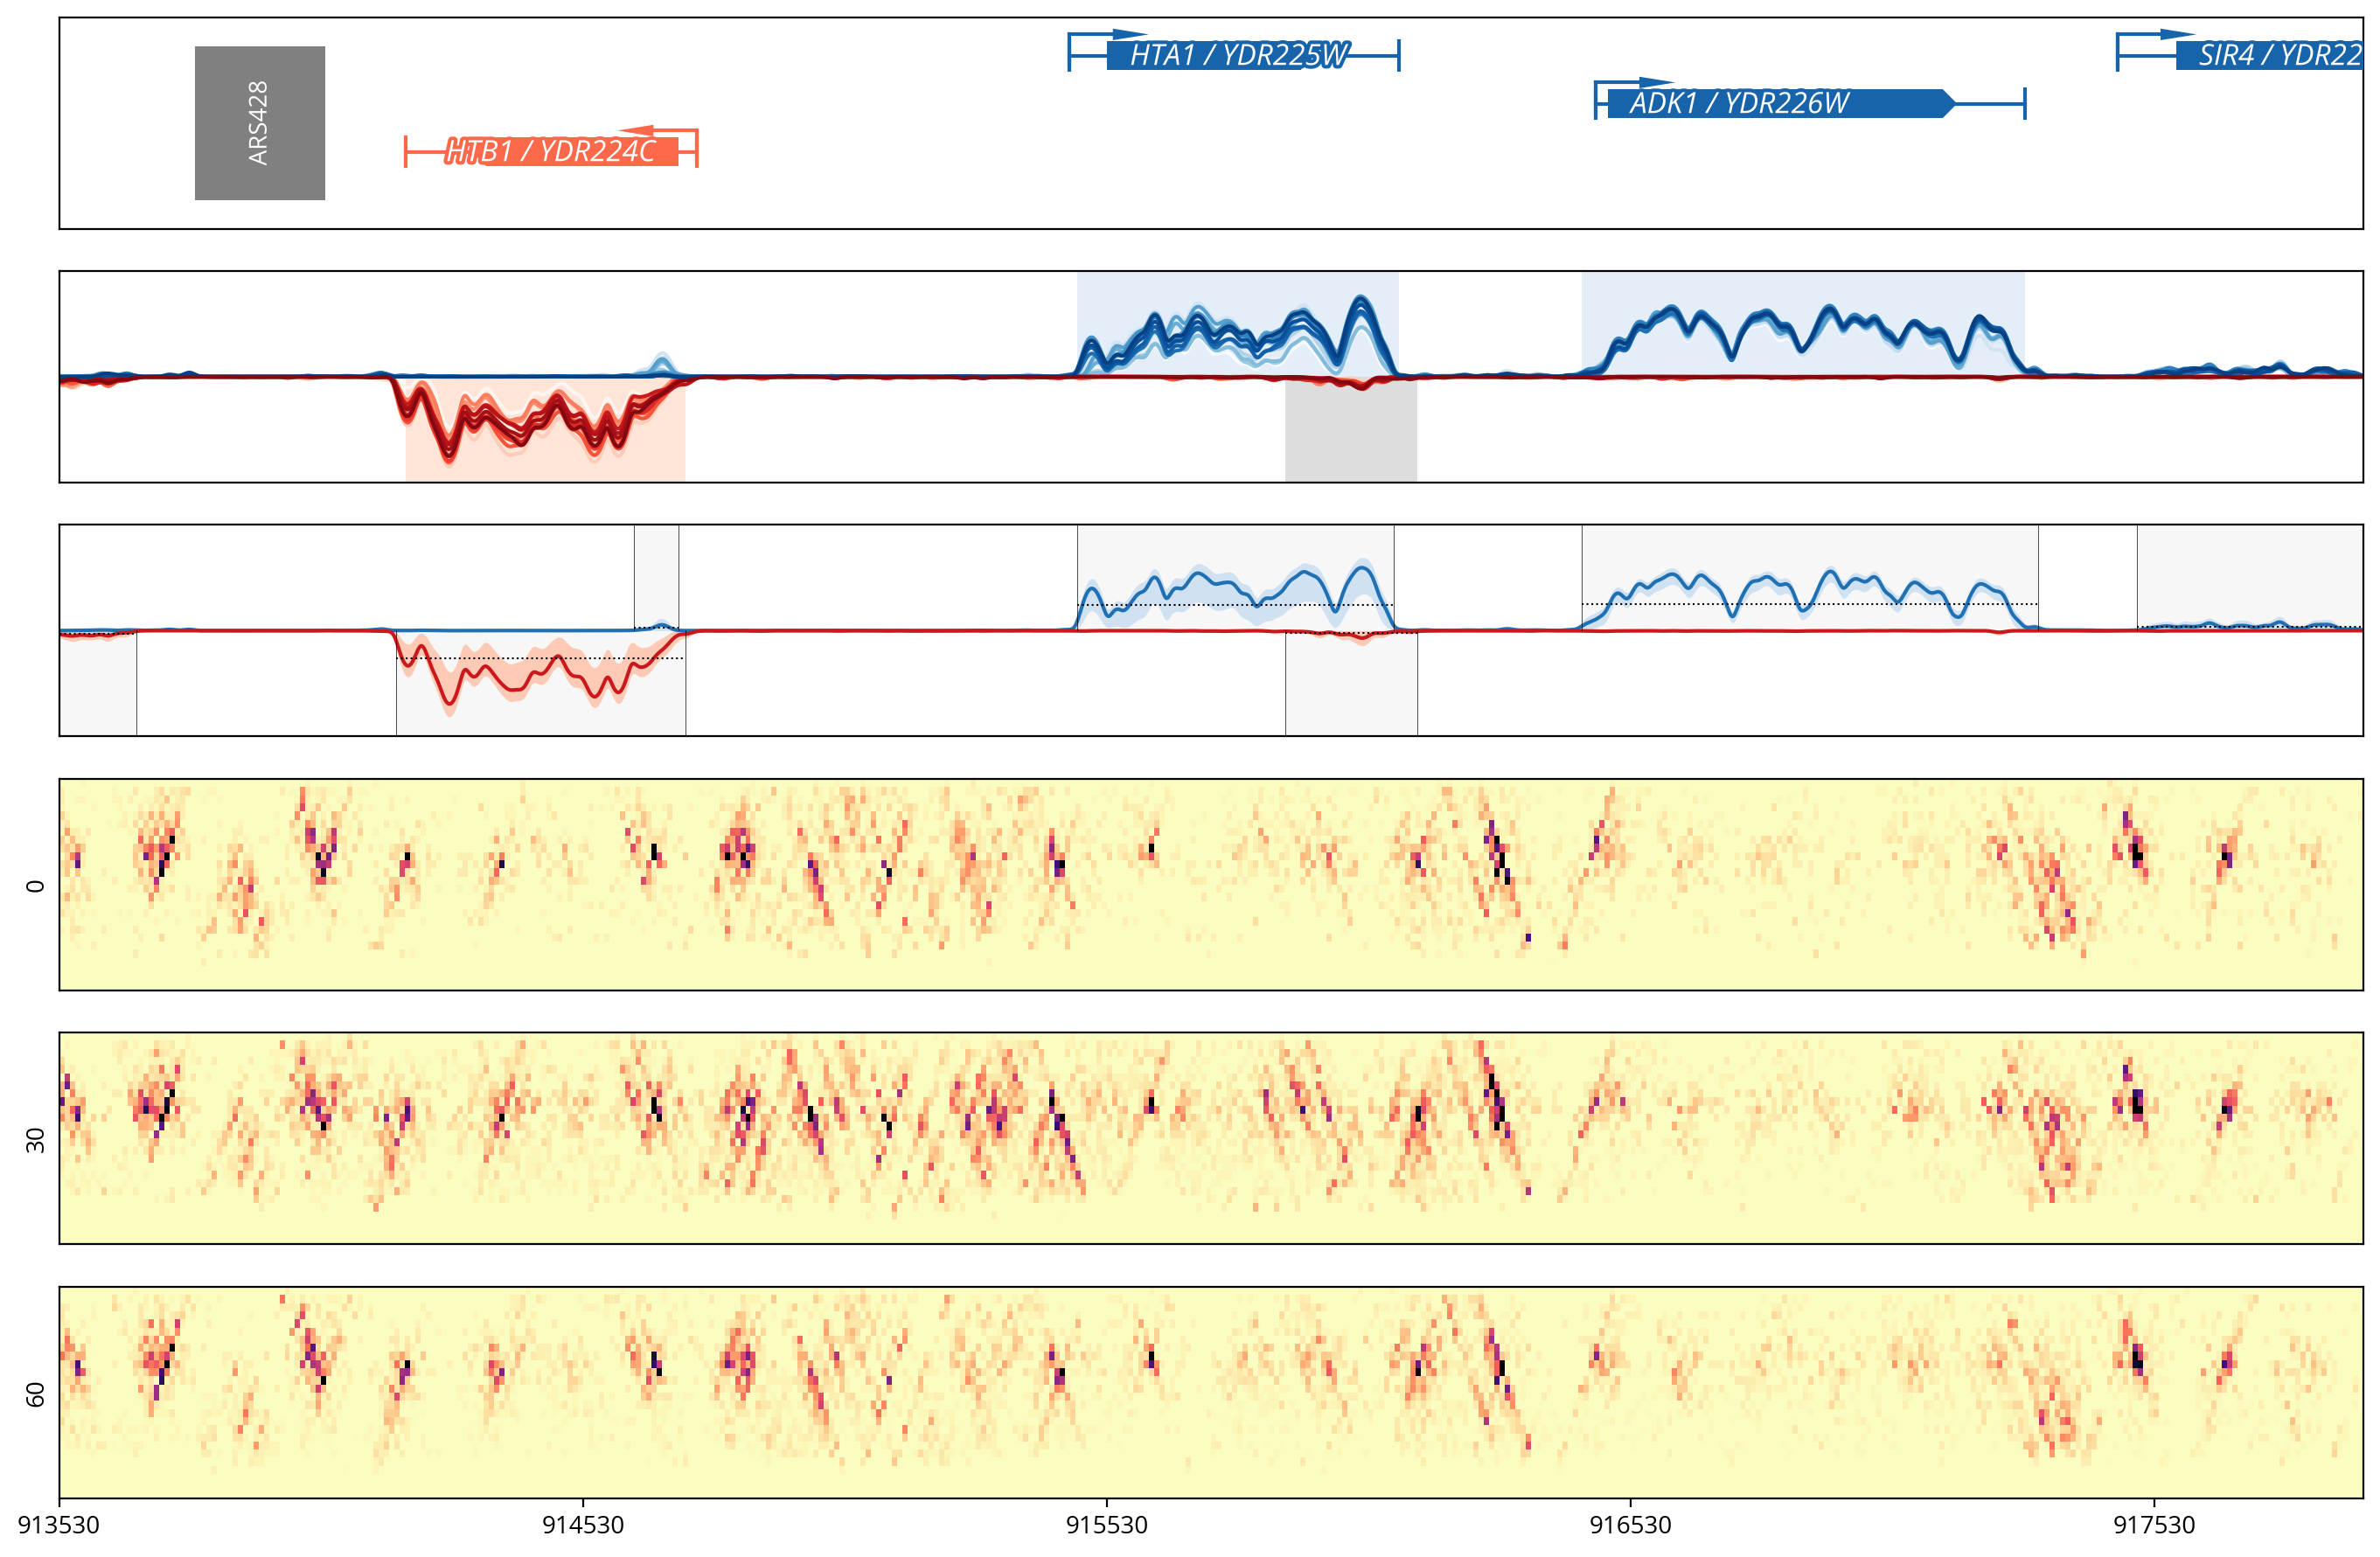

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)


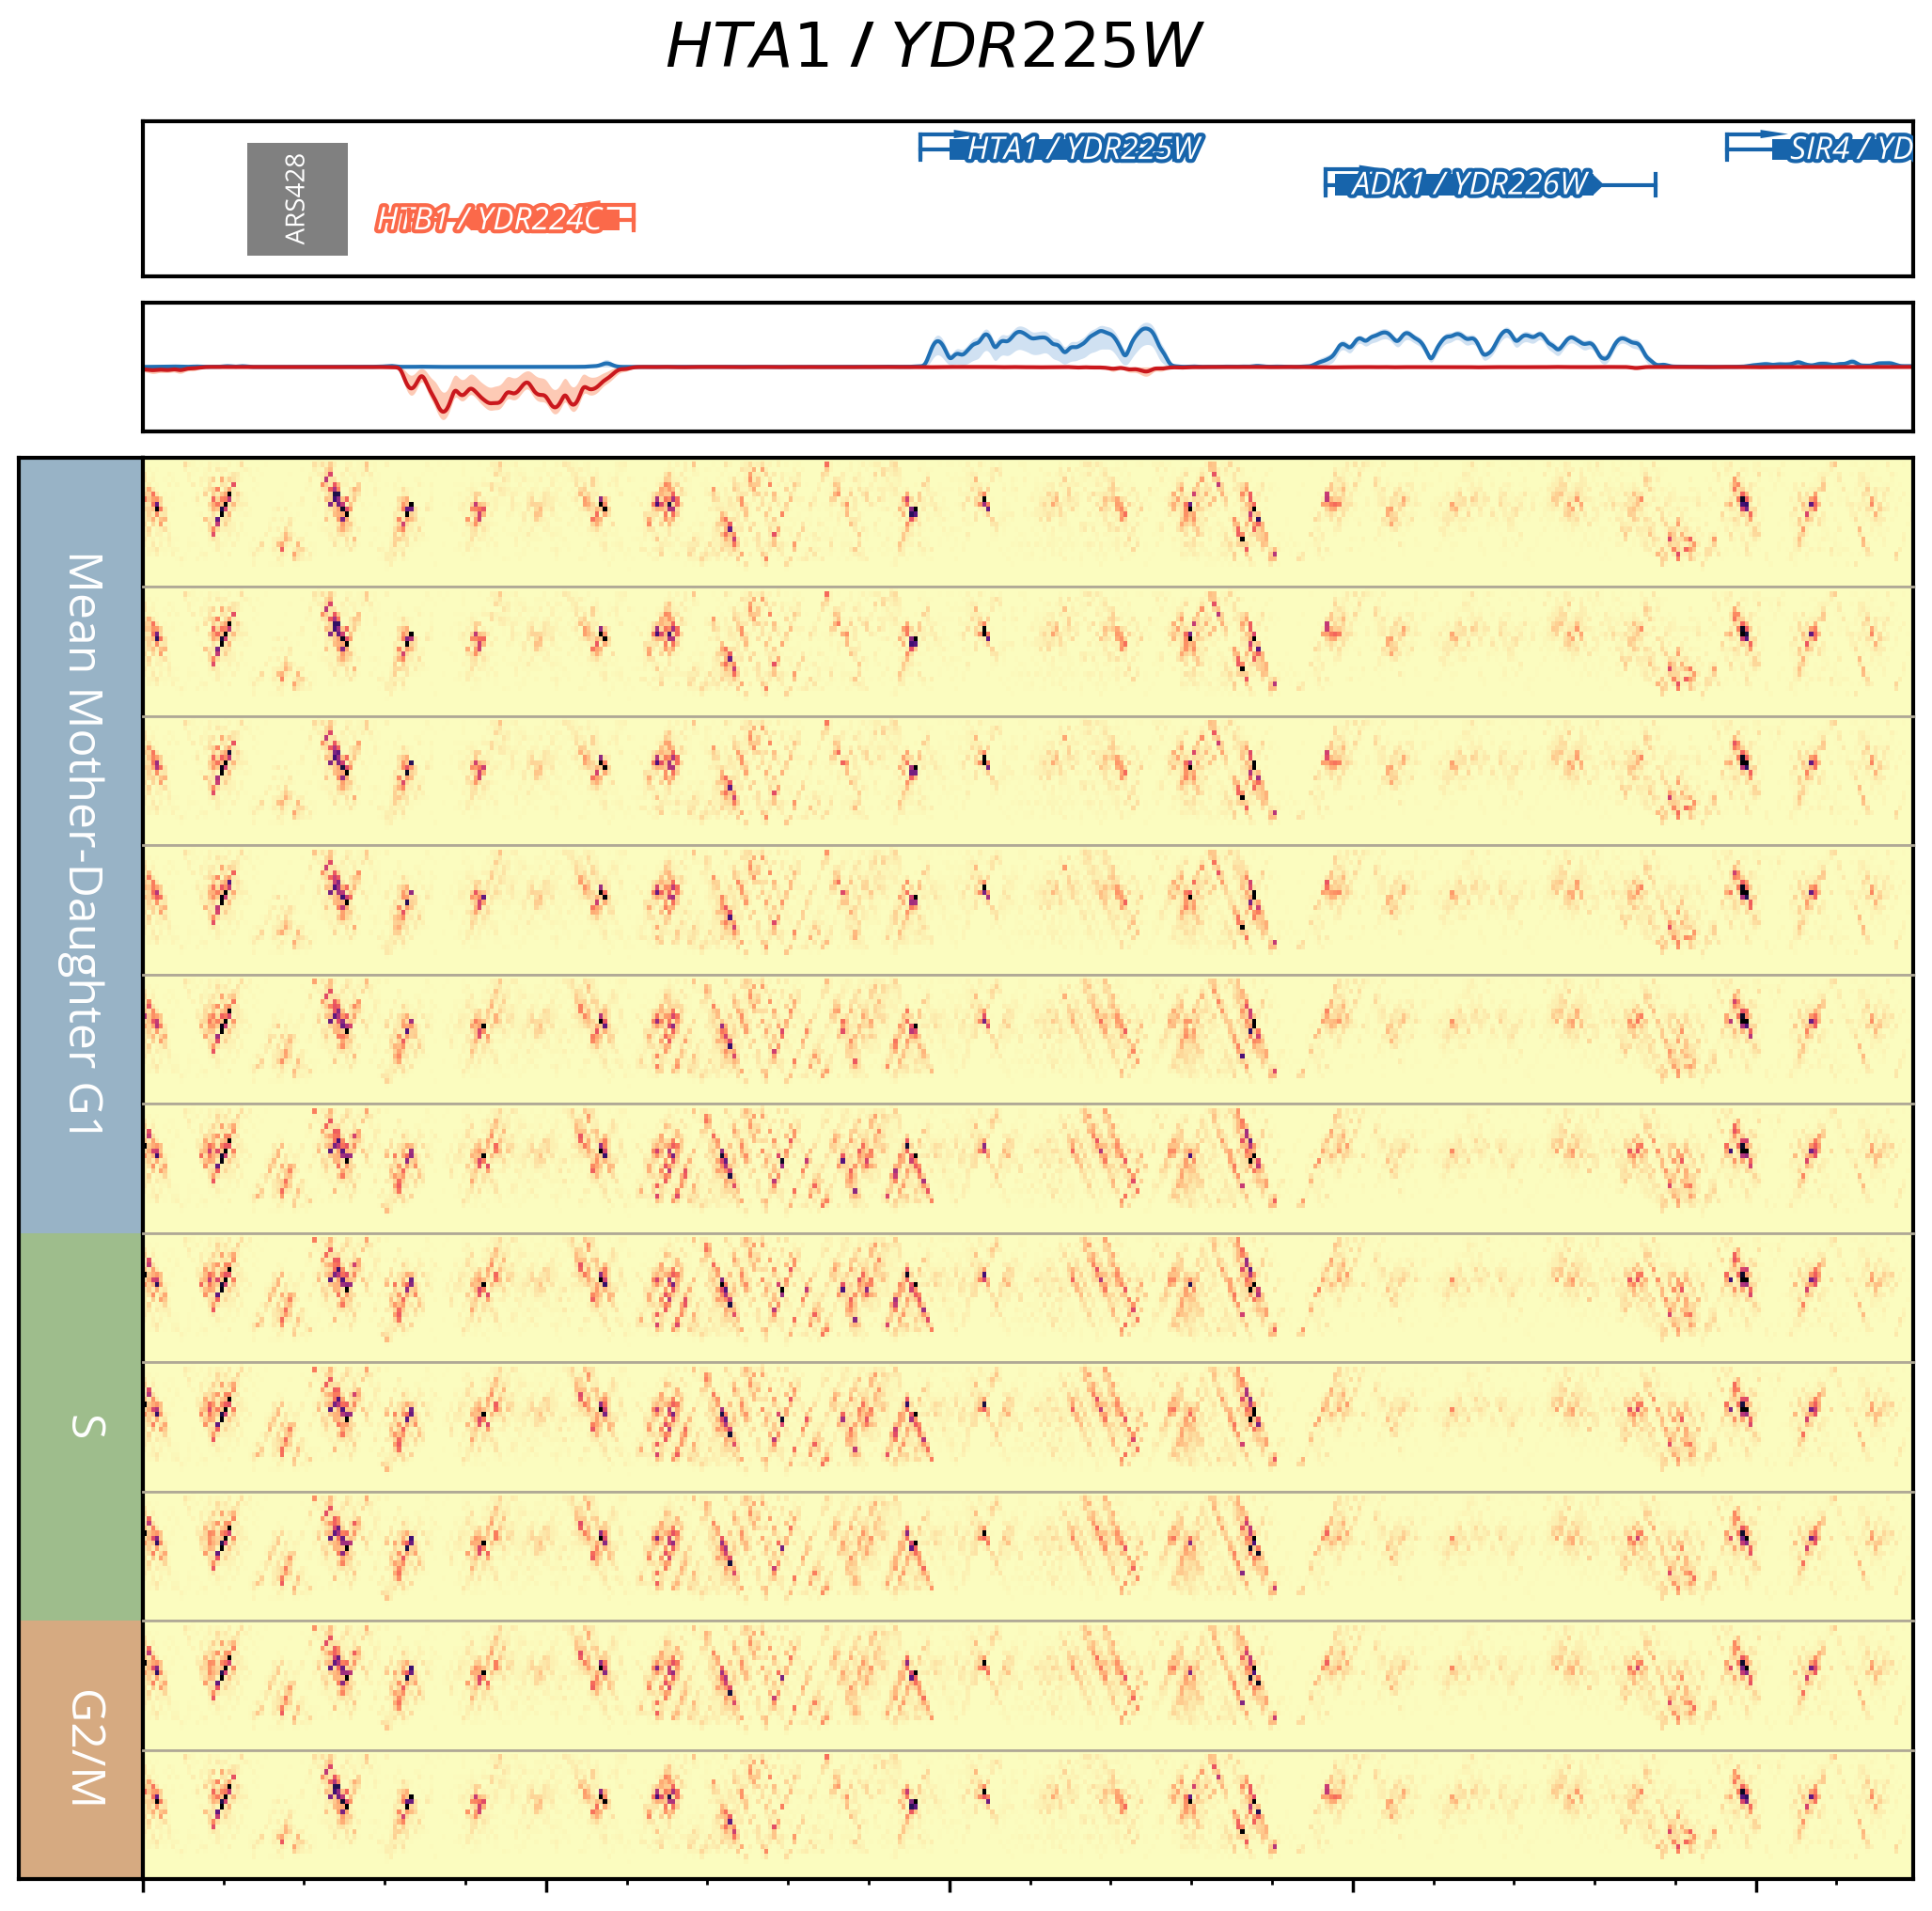

In [7]:
from src.sgd import get_gene_title_name

gene_title = get_gene_title_name(gene.name)
genome_deconv_analysis.plot_loaded_data(figsize=(13, 11), title=gene_title)

In [16]:
from pipeline.transcription_processor import ExpressionAnalysisProcessor


# Analyze the global non-genic transcripts view
output_dir = 'output/draft4_run/'
expression_processor = ExpressionAnalysisProcessor(output_dir)
expression_processor.load_deconvolved_expression()


Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 5578
0/9663
1000/9663
2000/9663
3000/9663
4000/9663
5000/9663
6000/9663
7000/9663
8000/9663
9000/9663
Loaded expression data: 9663 transcripts, 257 timepoints


,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,1.019523e-01,1.019404e-01,1.019164e-01,1.018804e-01,1.018324e-01,1.017725e-01,1.017006e-01,1.016170e-01,1.015215e-01,1.014133e-01,...,1.818338e-02,1.648960e-02,1.474086e-02,1.297629e-02,1.119432e-02,9.480378e-03,7.972193e-03,6.735290e-03,6.095734e-03,9.229450e-02
YAL067W-A,1.477840e-09,1.477800e-09,1.477724e-09,1.477595e-09,1.477415e-09,1.477232e-09,1.477049e-09,1.476861e-09,1.476672e-09,1.476476e-09,...,1.455398e-09,1.455301e-09,1.455196e-09,1.455088e-09,1.454979e-09,1.454874e-09,1.454809e-09,1.454771e-09,1.454779e-09,1.489557e-09
YAL067C,1.586884e+00,1.580607e+00,1.568464e+00,1.550212e+00,1.526477e+00,1.500683e+00,1.473696e+00,1.446137e+00,1.418700e+00,1.390511e+00,...,2.189374e+00,2.080855e+00,1.964823e+00,1.844674e+00,1.717644e+00,1.591059e+00,1.479950e+00,1.389999e+00,1.343227e+00,5.328558e+00
YAL065C,5.027270e-01,5.024736e-01,5.019703e-01,5.012147e-01,5.002129e-01,4.989916e-01,4.975574e-01,4.959183e-01,4.940805e-01,4.920331e-01,...,2.735859e-02,2.612627e-02,2.491968e-02,2.375457e-02,2.261676e-02,2.154716e-02,2.063712e-02,1.992125e-02,1.955187e-02,3.776325e-01
YAL064W-B,1.018470e+00,1.018463e+00,1.018449e+00,1.018428e+00,1.018400e+00,1.018365e+00,1.018323e+00,1.018273e+00,1.018217e+00,1.018158e+00,...,1.025924e+00,1.026316e+00,1.026723e+00,1.027133e+00,1.027549e+00,1.027950e+00,1.028298e+00,1.028578e+00,1.028723e+00,2.607579e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_911354_911518,4.594019e-01,4.594074e-01,4.594182e-01,4.594346e-01,4.594563e-01,4.594828e-01,4.595139e-01,4.595497e-01,4.595900e-01,4.596347e-01,...,4.690093e-01,4.691651e-01,4.693256e-01,4.694867e-01,4.696484e-01,4.698031e-01,4.699368e-01,4.700460e-01,4.701025e-01,2.974179e+00
nogene_chr16_916827_916941,1.335031e-01,1.336759e-01,1.340224e-01,1.345428e-01,1.352388e-01,1.361165e-01,1.371796e-01,1.384235e-01,1.398514e-01,1.414814e-01,...,9.617325e-01,9.647942e-01,9.678593e-01,9.708795e-01,9.738505e-01,9.766550e-01,9.790979e-01,9.810844e-01,9.821089e-01,5.094859e+00
nogene_chr16_930146_930982,1.423574e+00,1.423598e+00,1.423645e+00,1.423716e+00,1.423811e+00,1.423926e+00,1.424062e+00,1.424218e+00,1.424393e+00,1.424588e+00,...,1.466718e+00,1.467222e+00,1.467739e+00,1.468257e+00,1.468773e+00,1.469264e+00,1.469695e+00,1.470049e+00,1.470231e+00,3.256594e+00


In [18]:
expression_processor.load_raw_expression()

In [19]:
expression_processor.raw_rep1_expression_data

,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150
transcript_name,,,,,,,,,,,,,,,,
YAL068C,0.099864,0.000000,0.086590,0.000000,0.093136,0.085768,0.000000,0.000000,0.000000,0.000000,0.000000,0.065129,0.000000,0.000000,0.083965,0.081175
YAL067W-A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
YAL067C,2.272431,1.632523,1.541556,2.698220,3.358639,2.299173,1.495999,1.301446,1.065014,1.232370,1.397891,1.365610,1.725517,1.844691,1.718068,1.567855
YAL065C,0.418008,0.307823,0.231474,0.263011,0.087518,0.156899,0.234168,0.000000,0.000000,0.000000,0.353183,0.061164,0.190281,0.072816,0.153679,0.000000
YAL064W-B,1.399806,1.327664,1.642184,1.193166,1.056565,1.154050,1.282193,1.367136,1.095950,1.217381,0.745205,1.344646,1.364756,1.336266,1.136756,1.283075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_911354_911518,0.962900,1.083778,1.731686,1.676507,1.468001,1.779754,1.912728,1.267651,1.963228,1.342180,0.177050,0.384923,0.413412,0.449462,0.179229,0.173457
nogene_chr16_916827_916941,0.750843,1.268612,1.247909,2.056556,1.987187,2.106540,1.920144,1.861015,1.942551,1.769573,1.616454,1.539168,1.282212,1.264399,1.537521,0.451628
nogene_chr16_930146_930982,1.386167,1.829121,2.009604,1.791721,2.149350,1.579783,1.652006,1.657169,1.422478,1.648797,1.724768,1.659719,1.654516,1.677628,1.621031,1.724975


In [20]:
expression_processor.load_deconvolved_expression()

Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 5578
0/9663
1000/9663
2000/9663
3000/9663
4000/9663
5000/9663
6000/9663
7000/9663
8000/9663
9000/9663
Loaded expression data: 9663 transcripts, 257 timepoints


,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,1.019523e-01,1.019404e-01,1.019164e-01,1.018804e-01,1.018324e-01,1.017725e-01,1.017006e-01,1.016170e-01,1.015215e-01,1.014133e-01,...,1.818338e-02,1.648960e-02,1.474086e-02,1.297629e-02,1.119432e-02,9.480378e-03,7.972193e-03,6.735290e-03,6.095734e-03,9.229450e-02
YAL067W-A,1.477840e-09,1.477800e-09,1.477724e-09,1.477595e-09,1.477415e-09,1.477232e-09,1.477049e-09,1.476861e-09,1.476672e-09,1.476476e-09,...,1.455398e-09,1.455301e-09,1.455196e-09,1.455088e-09,1.454979e-09,1.454874e-09,1.454809e-09,1.454771e-09,1.454779e-09,1.489557e-09
YAL067C,1.586884e+00,1.580607e+00,1.568464e+00,1.550212e+00,1.526477e+00,1.500683e+00,1.473696e+00,1.446137e+00,1.418700e+00,1.390511e+00,...,2.189374e+00,2.080855e+00,1.964823e+00,1.844674e+00,1.717644e+00,1.591059e+00,1.479950e+00,1.389999e+00,1.343227e+00,5.328558e+00
YAL065C,5.027270e-01,5.024736e-01,5.019703e-01,5.012147e-01,5.002129e-01,4.989916e-01,4.975574e-01,4.959183e-01,4.940805e-01,4.920331e-01,...,2.735859e-02,2.612627e-02,2.491968e-02,2.375457e-02,2.261676e-02,2.154716e-02,2.063712e-02,1.992125e-02,1.955187e-02,3.776325e-01
YAL064W-B,1.018470e+00,1.018463e+00,1.018449e+00,1.018428e+00,1.018400e+00,1.018365e+00,1.018323e+00,1.018273e+00,1.018217e+00,1.018158e+00,...,1.025924e+00,1.026316e+00,1.026723e+00,1.027133e+00,1.027549e+00,1.027950e+00,1.028298e+00,1.028578e+00,1.028723e+00,2.607579e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_911354_911518,4.594019e-01,4.594074e-01,4.594182e-01,4.594346e-01,4.594563e-01,4.594828e-01,4.595139e-01,4.595497e-01,4.595900e-01,4.596347e-01,...,4.690093e-01,4.691651e-01,4.693256e-01,4.694867e-01,4.696484e-01,4.698031e-01,4.699368e-01,4.700460e-01,4.701025e-01,2.974179e+00
nogene_chr16_916827_916941,1.335031e-01,1.336759e-01,1.340224e-01,1.345428e-01,1.352388e-01,1.361165e-01,1.371796e-01,1.384235e-01,1.398514e-01,1.414814e-01,...,9.617325e-01,9.647942e-01,9.678593e-01,9.708795e-01,9.738505e-01,9.766550e-01,9.790979e-01,9.810844e-01,9.821089e-01,5.094859e+00
nogene_chr16_930146_930982,1.423574e+00,1.423598e+00,1.423645e+00,1.423716e+00,1.423811e+00,1.423926e+00,1.424062e+00,1.424218e+00,1.424393e+00,1.424588e+00,...,1.466718e+00,1.467222e+00,1.467739e+00,1.468257e+00,1.468773e+00,1.469264e+00,1.469695e+00,1.470049e+00,1.470231e+00,3.256594e+00


In [23]:
transcripts = expression_processor.all_transcripts_set
transcripts#[transcripts#.transcript_class == 'nongenic']


In [26]:
from pipeline.chromatin_metrics_processor import ChromatinMetricsProcessor

chromatin_metrics_processor = ChromatinMetricsProcessor(output_dir)

In [27]:
chromatin_metrics_processor.setup_data_loaders()

In [28]:
chromatin_metrics_processor.load_and_assign_saved_metrics()

Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entropy: 9663 genes, 16 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 16 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep2 data...
    Loaded promoter_occupancy: 9663 genes, 15 timepoints
    Loaded nucleosome_entropy: 9663 genes, 15 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 15 timepoints
    Loaded promoter_occupancy PTRs: 9663 gen

In [29]:
po_metrics = chromatin_metrics_processor.deconvolved_chromatin_metrics['promoter_occupancy']

In [35]:
expression_processor.setup_data_loaders()
expression_processor.compute_expression_ptrs()


Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Computing PTR values with quantiles 0.1-0.9...
Computed PTR values for 9663 transcripts
PTR range: 1.000 - 8.258


,ptr,transcript_class
transcript_name,,
YAL068C,1.063434,genic
YAL067W-A,1.000000,genic
YAL067C,3.991119,genic
YAL065C,1.115157,genic
YAL064W-B,1.003449,genic
...,...,...
nogene_chr16_911354_911518,1.002453,nongenic
nogene_chr16_916827_916941,1.134312,nongenic
nogene_chr16_930146_930982,1.005869,nongenic


Text(0.5, 1.0, 'Non-genic transcription and promoter occupancy PTR, n=341')

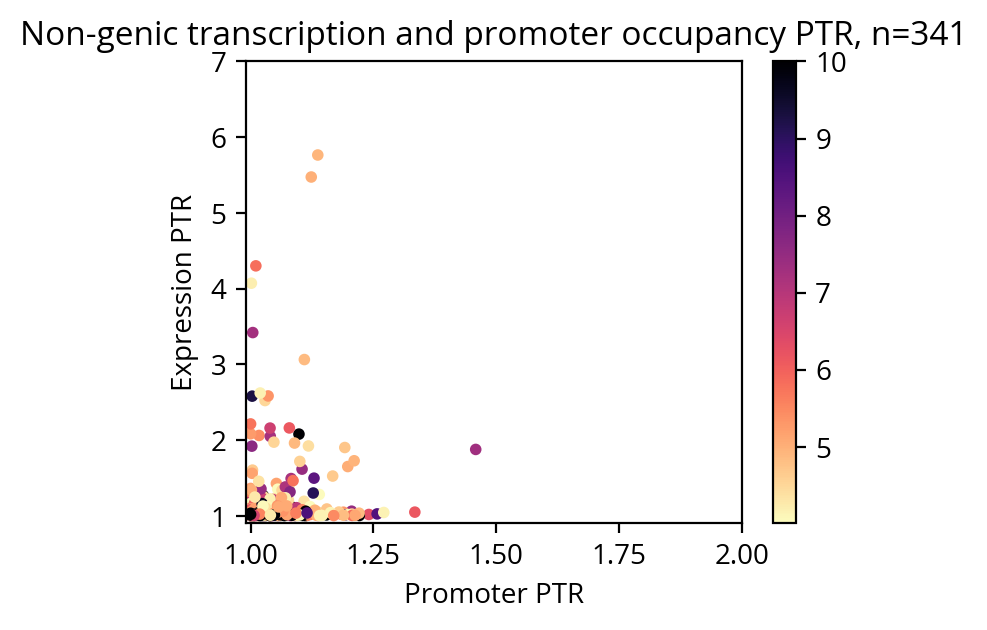

In [267]:
joined_expression_promoter_occupancy_ptrs = expression_processor.all_transcripts_ptrs.join(
    chromatin_metrics_processor.deconvolved_chromatin_ptrs['promoter_occupancy'])
joined_expression_promoter_occupancy_ptrs = joined_expression_promoter_occupancy_ptrs[
    joined_expression_promoter_occupancy_ptrs.transcript_class == 'nongenic']
plot_data = joined_expression_promoter_occupancy_ptrs.copy()


high_quantile_expression = expression_processor.expression_data[
    config1.t_indices()].quantile(axis=1, 
    q=0.9)
high_quantile_expression = pd.DataFrame(
    high_quantile_expression)

plot_data = plot_data.join(high_quantile_expression)
plot_data.columns = ['expression_ptr', 'transcript_class', 
                     'chromatin_ptr', 'percentile_90']

plot_data = plot_data[plot_data.percentile_90 > 4]

plt.figure(figsize=(4, 3))
plt.scatter(plot_data.chromatin_ptr, 
    plot_data.expression_ptr, c=plot_data.percentile_90, s=10, vmax=10,
           cmap='magma_r')
plt.colorbar()
plt.xlim(0.99, 2)
plt.ylim(0.9, 7)
plt.xlabel("Promoter PTR")
plt.ylabel("Expression PTR")
plt.title(f"Non-genic transcription and promoter occupancy PTR, n={len(plot_data)}")

In [269]:
plot_data[plot_data.chromatin_ptr > 1.2]

,expression_ptr,transcript_class,chromatin_ptr,percentile_90
transcript_name,,,,
nogene_chr1_87471_87871,1.018459,nongenic,1.240742,6.314737
nogene_chr2_490837_491313,1.061840,nongenic,1.205657,7.490633
nogene_chr4_512535_512923,1.023483,nongenic,1.206073,4.521943
nogene_chr4_322959_323520,1.004458,nongenic,1.221340,10.538326
nogene_chr5_434920_435627,1.005683,nongenic,1.209950,4.095033
nogene_chr7_254536_254988,1.025993,nongenic,1.257635,8.490412
nogene_chr7_726891_727308,1.035627,nongenic,1.220884,4.850887
nogene_chr12_113916_114225,1.005984,nongenic,1.206697,5.831819
nogene_chr12_794139_795128,1.049461,nongenic,1.334439,6.156627


nogene_chr7_1000966_1001335
nogene_chr7_939373_939614
nogene_chr7_1001370_1002463
nogene_chr4_133984_134792
nogene_chr1_140088_140189
nogene_chr15_832340_832590
nogene_chr8_381546_381836
nogene_chr1_141116_141577
nogene_chr1_139325_139778
nogene_chr5_441999_442469
nogene_chr16_821687_822100
nogene_chr5_260534_261001
nogene_chr2_255089_255402
nogene_chr2_429462_429612


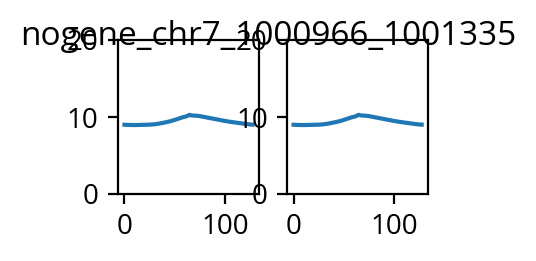

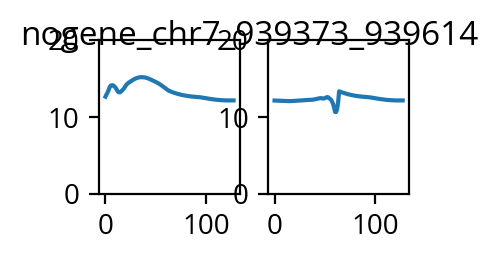

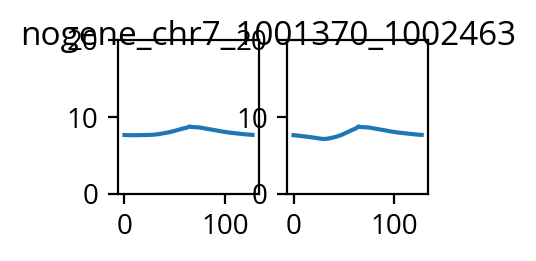

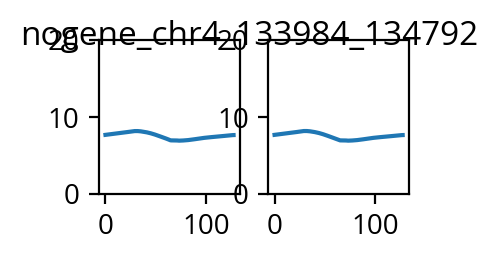

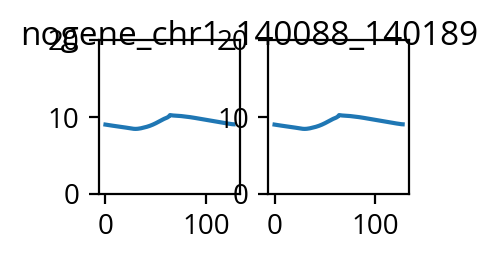

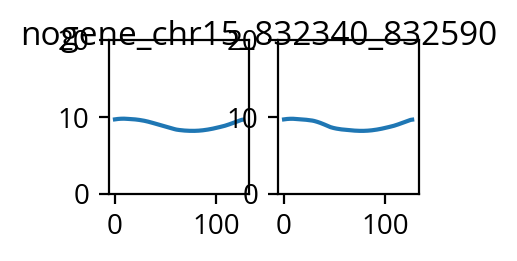

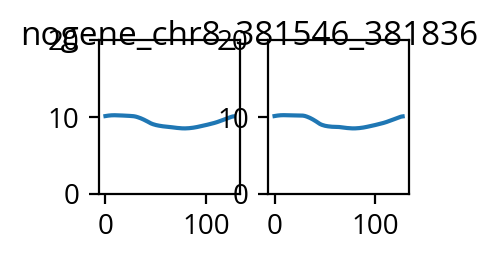

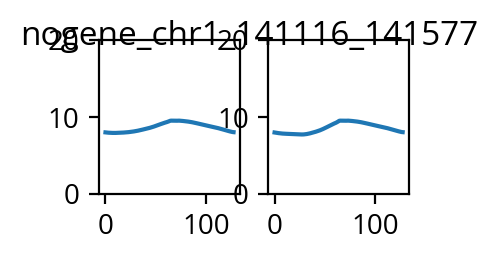

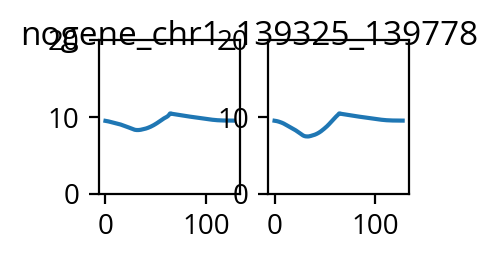

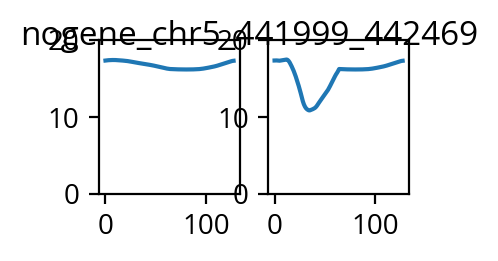

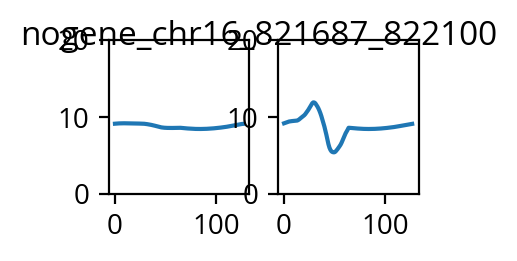

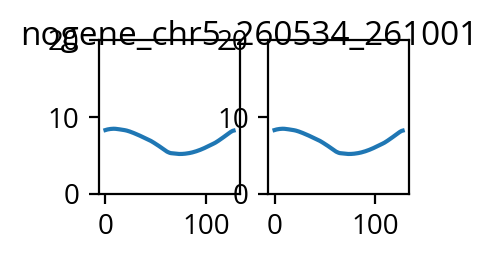

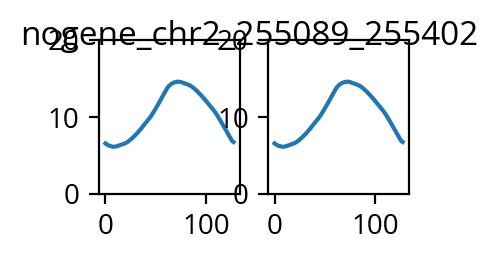

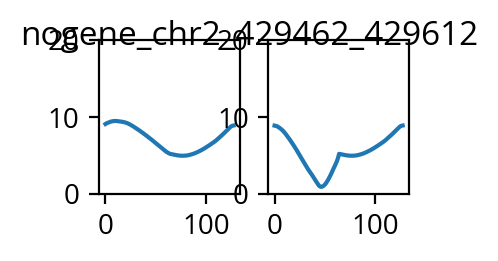

In [210]:
for transcript_name, row in selected_data.iterrows():
    plt.figure(figsize=(2, 1))
    plt.subplot(1, 2, 1)
    indices = config1.t_indices()
    plt.plot(expression_processor.expression_data.loc[transcript_name]\
                 [indices].values)
    plt.ylim(0, 20)
    plt.subplot(1, 2, 2)
    indices = config1.b_indices()
    plt.plot(expression_processor.expression_data.loc[transcript_name]\
                 [indices].values)
    plt.ylim(0, 20)
    plt.suptitle(transcript_name)
    print(transcript_name)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 16
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr16.h5, crick_rna_seq_pileup_rep1_chr16.h5
Shape: (16, 948066) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr16.h5, crick_rna_seq_pileup_rep2_chr16.h5
Shape: (14, 948066) (timepoints x positions)


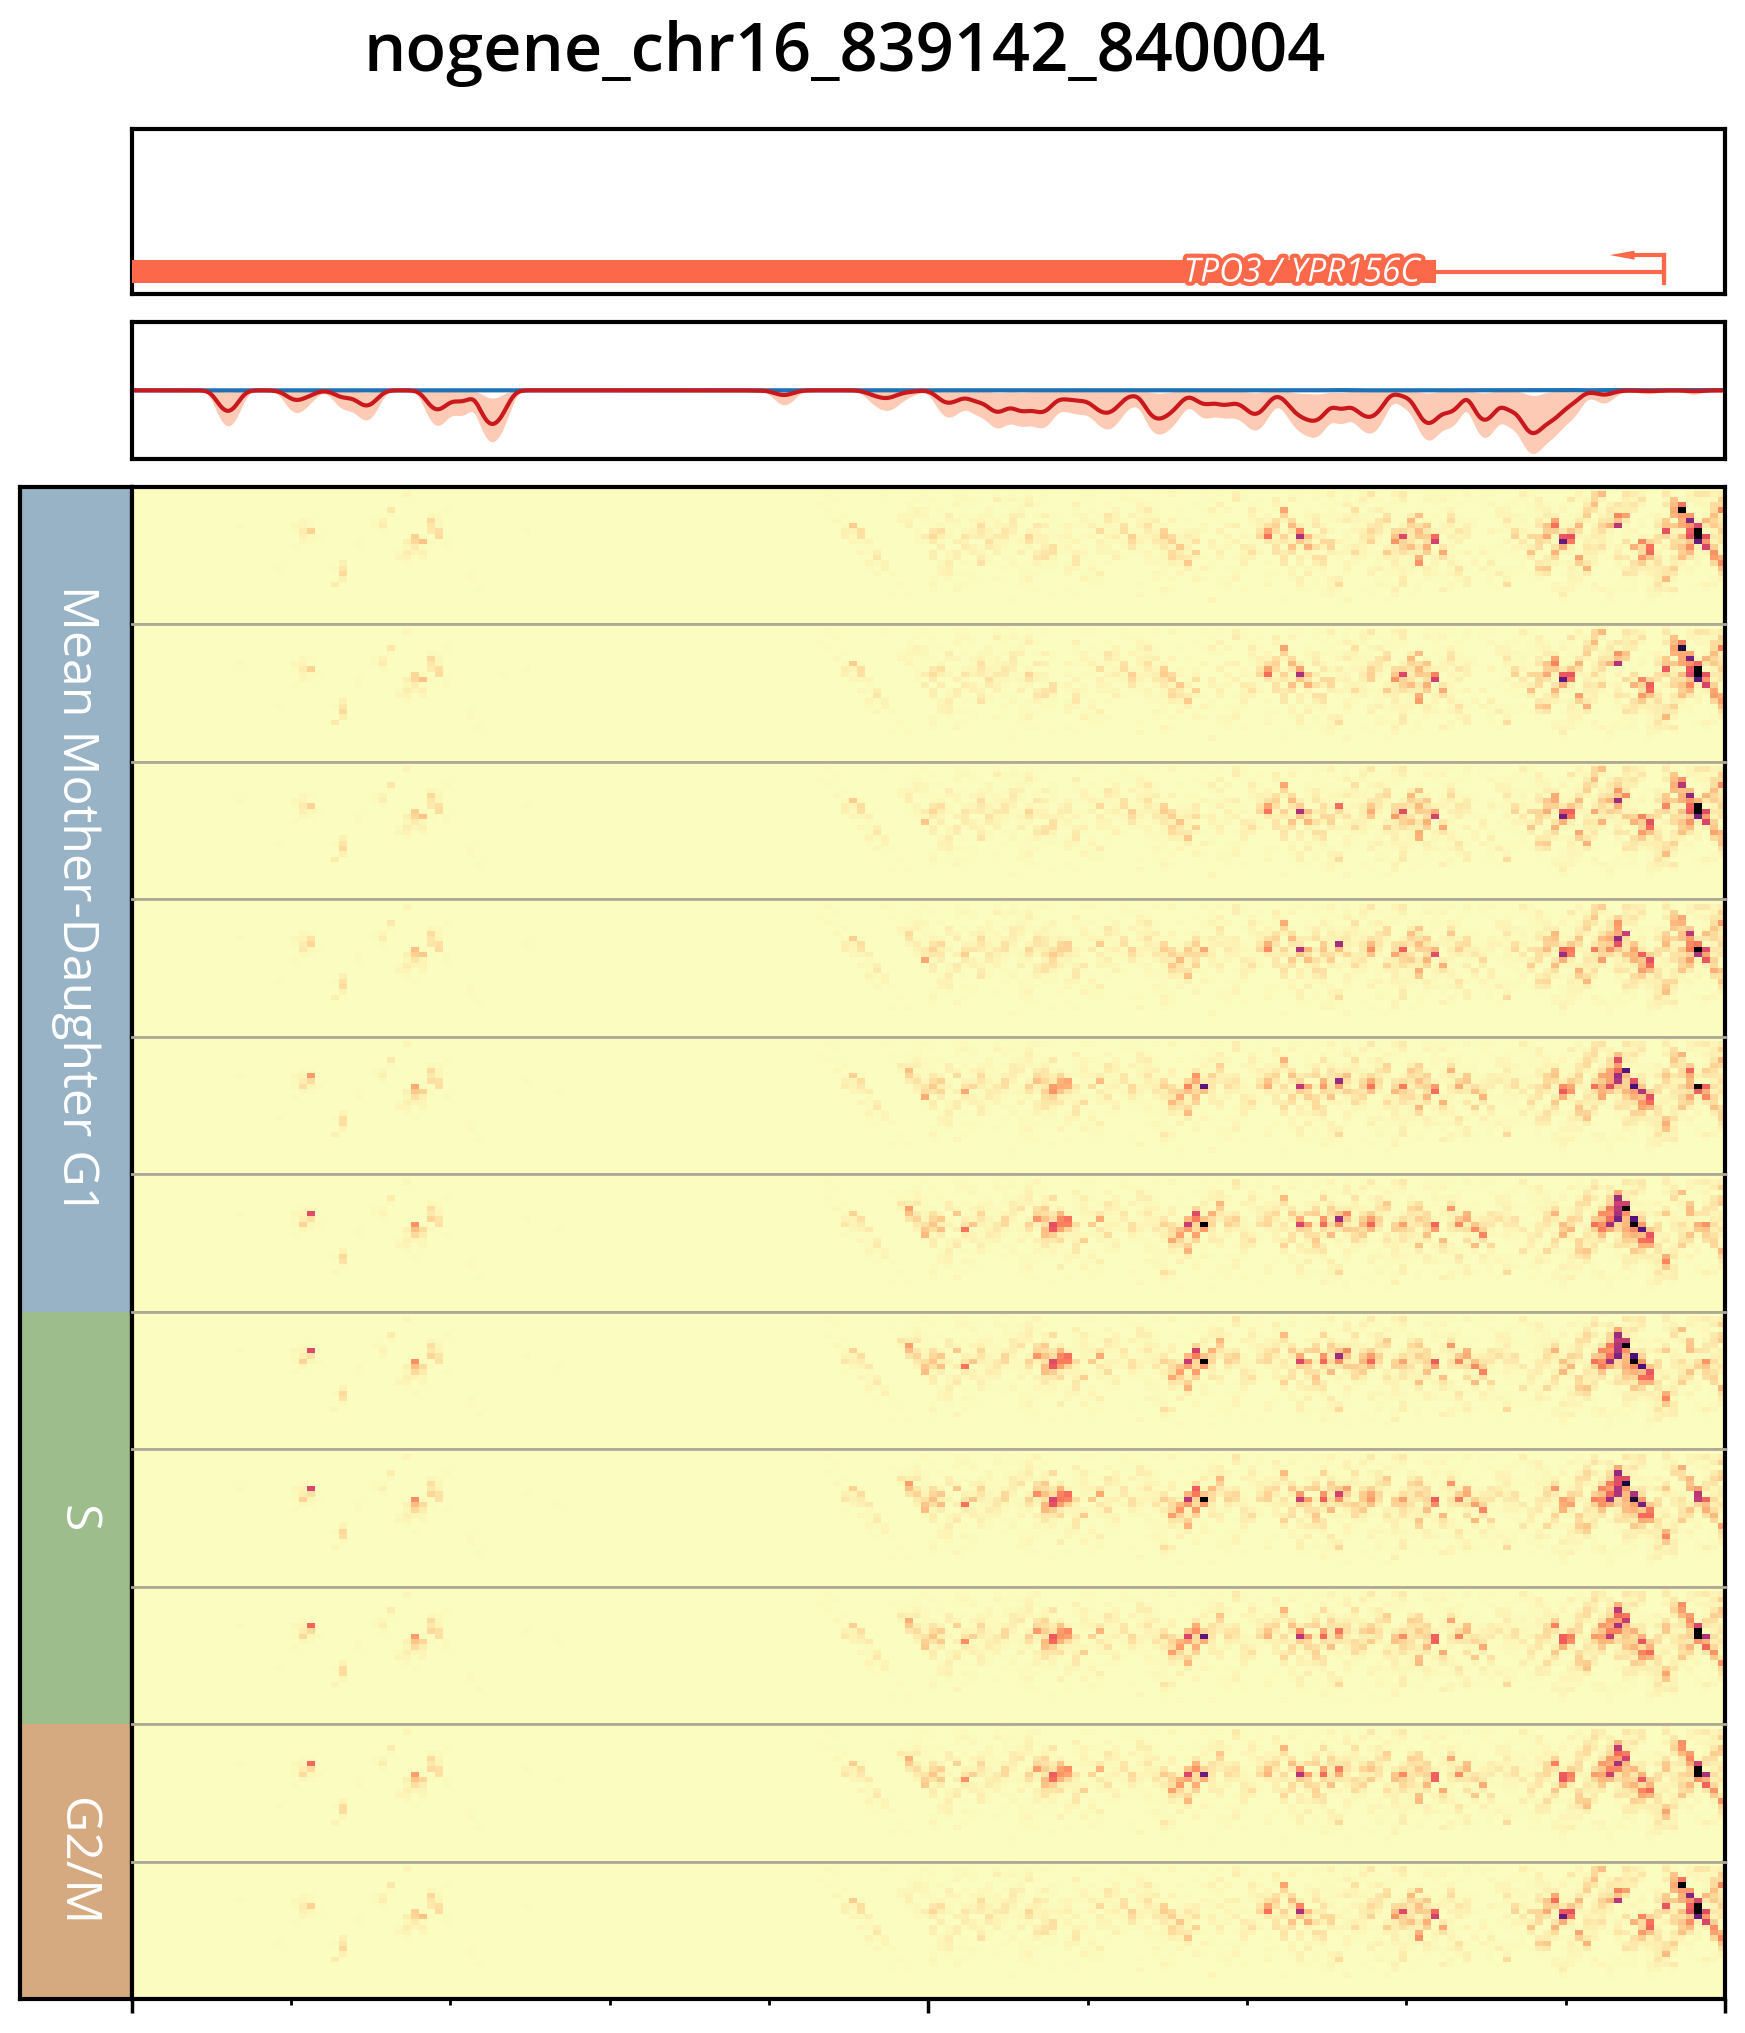

In [270]:
transcript_name = 'nogene_chr16_839142_840004'
transcript_split = transcript_name.split('_')
chrom = int(transcript_split[1].replace('chr', ''))
center = (int(transcript_split[2]))

span = center-1000, center+1000
loaded_data = genome_deconv_analysis.load_mnase_span(chrom, span)
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=transcript_name)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 1
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr1.h5, crick_rna_seq_pileup_rep1_chr1.h5
Shape: (16, 230218) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr1.h5, crick_rna_seq_pileup_rep2_chr1.h5
Shape: (14, 230218) (timepoints x positions)
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for c

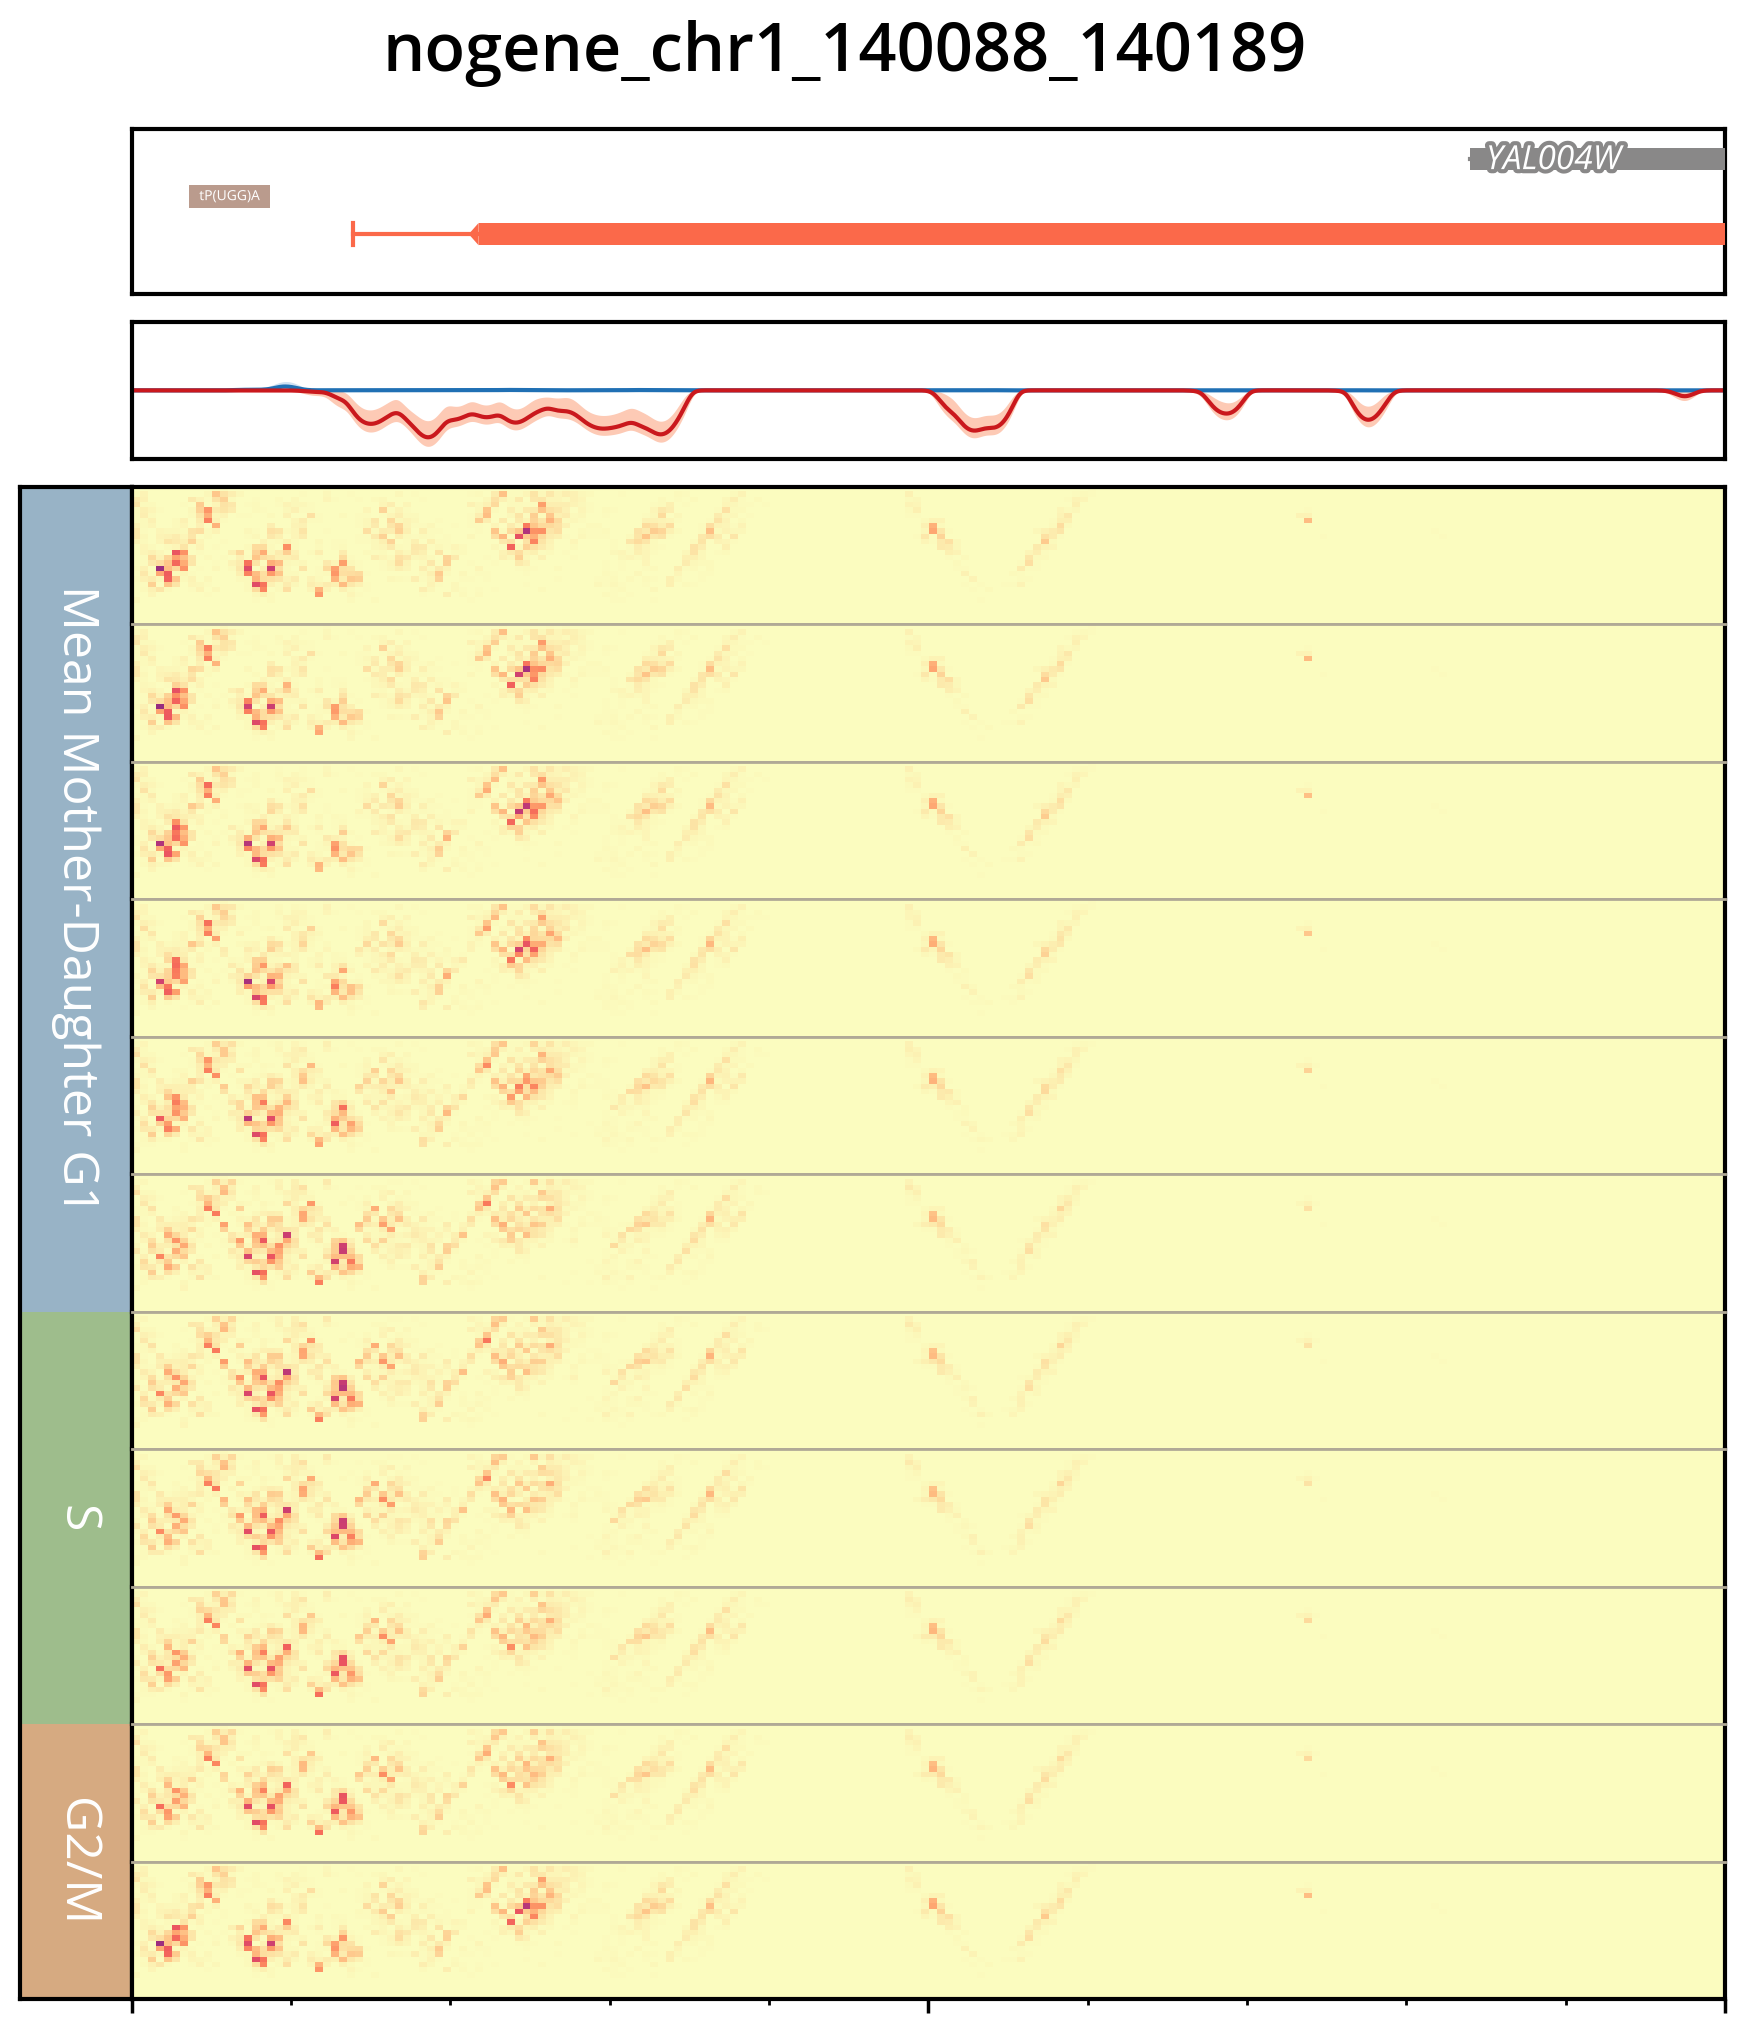

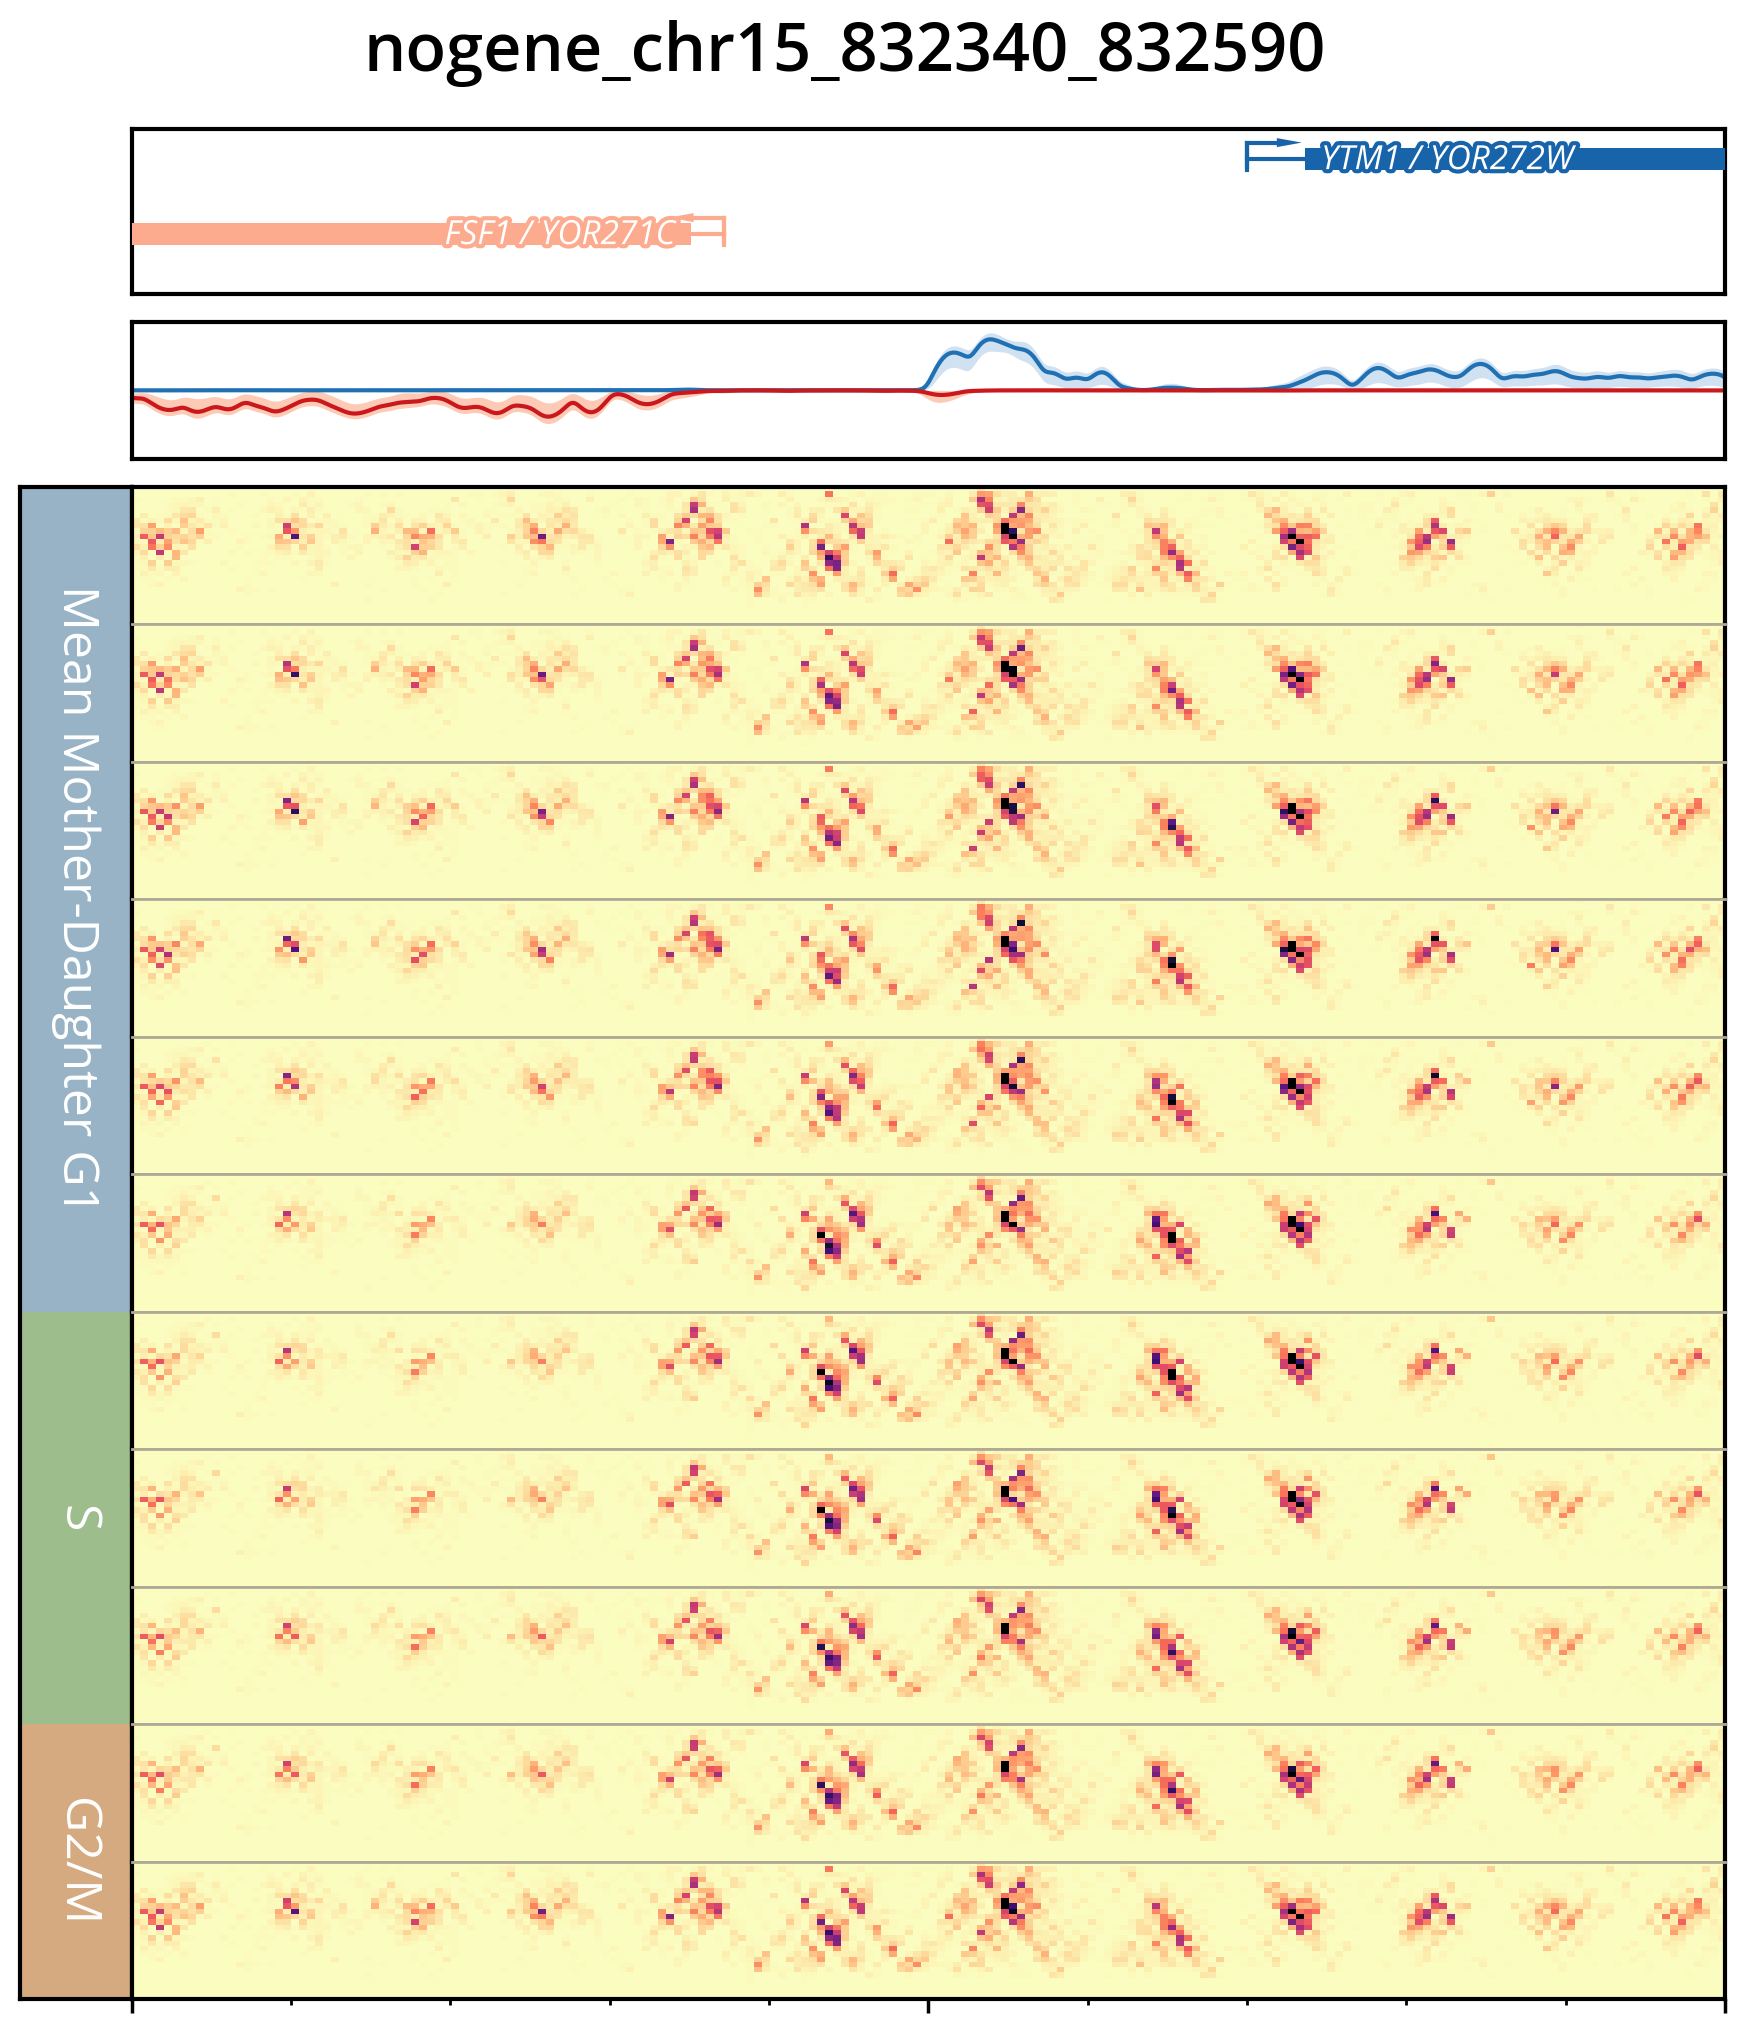

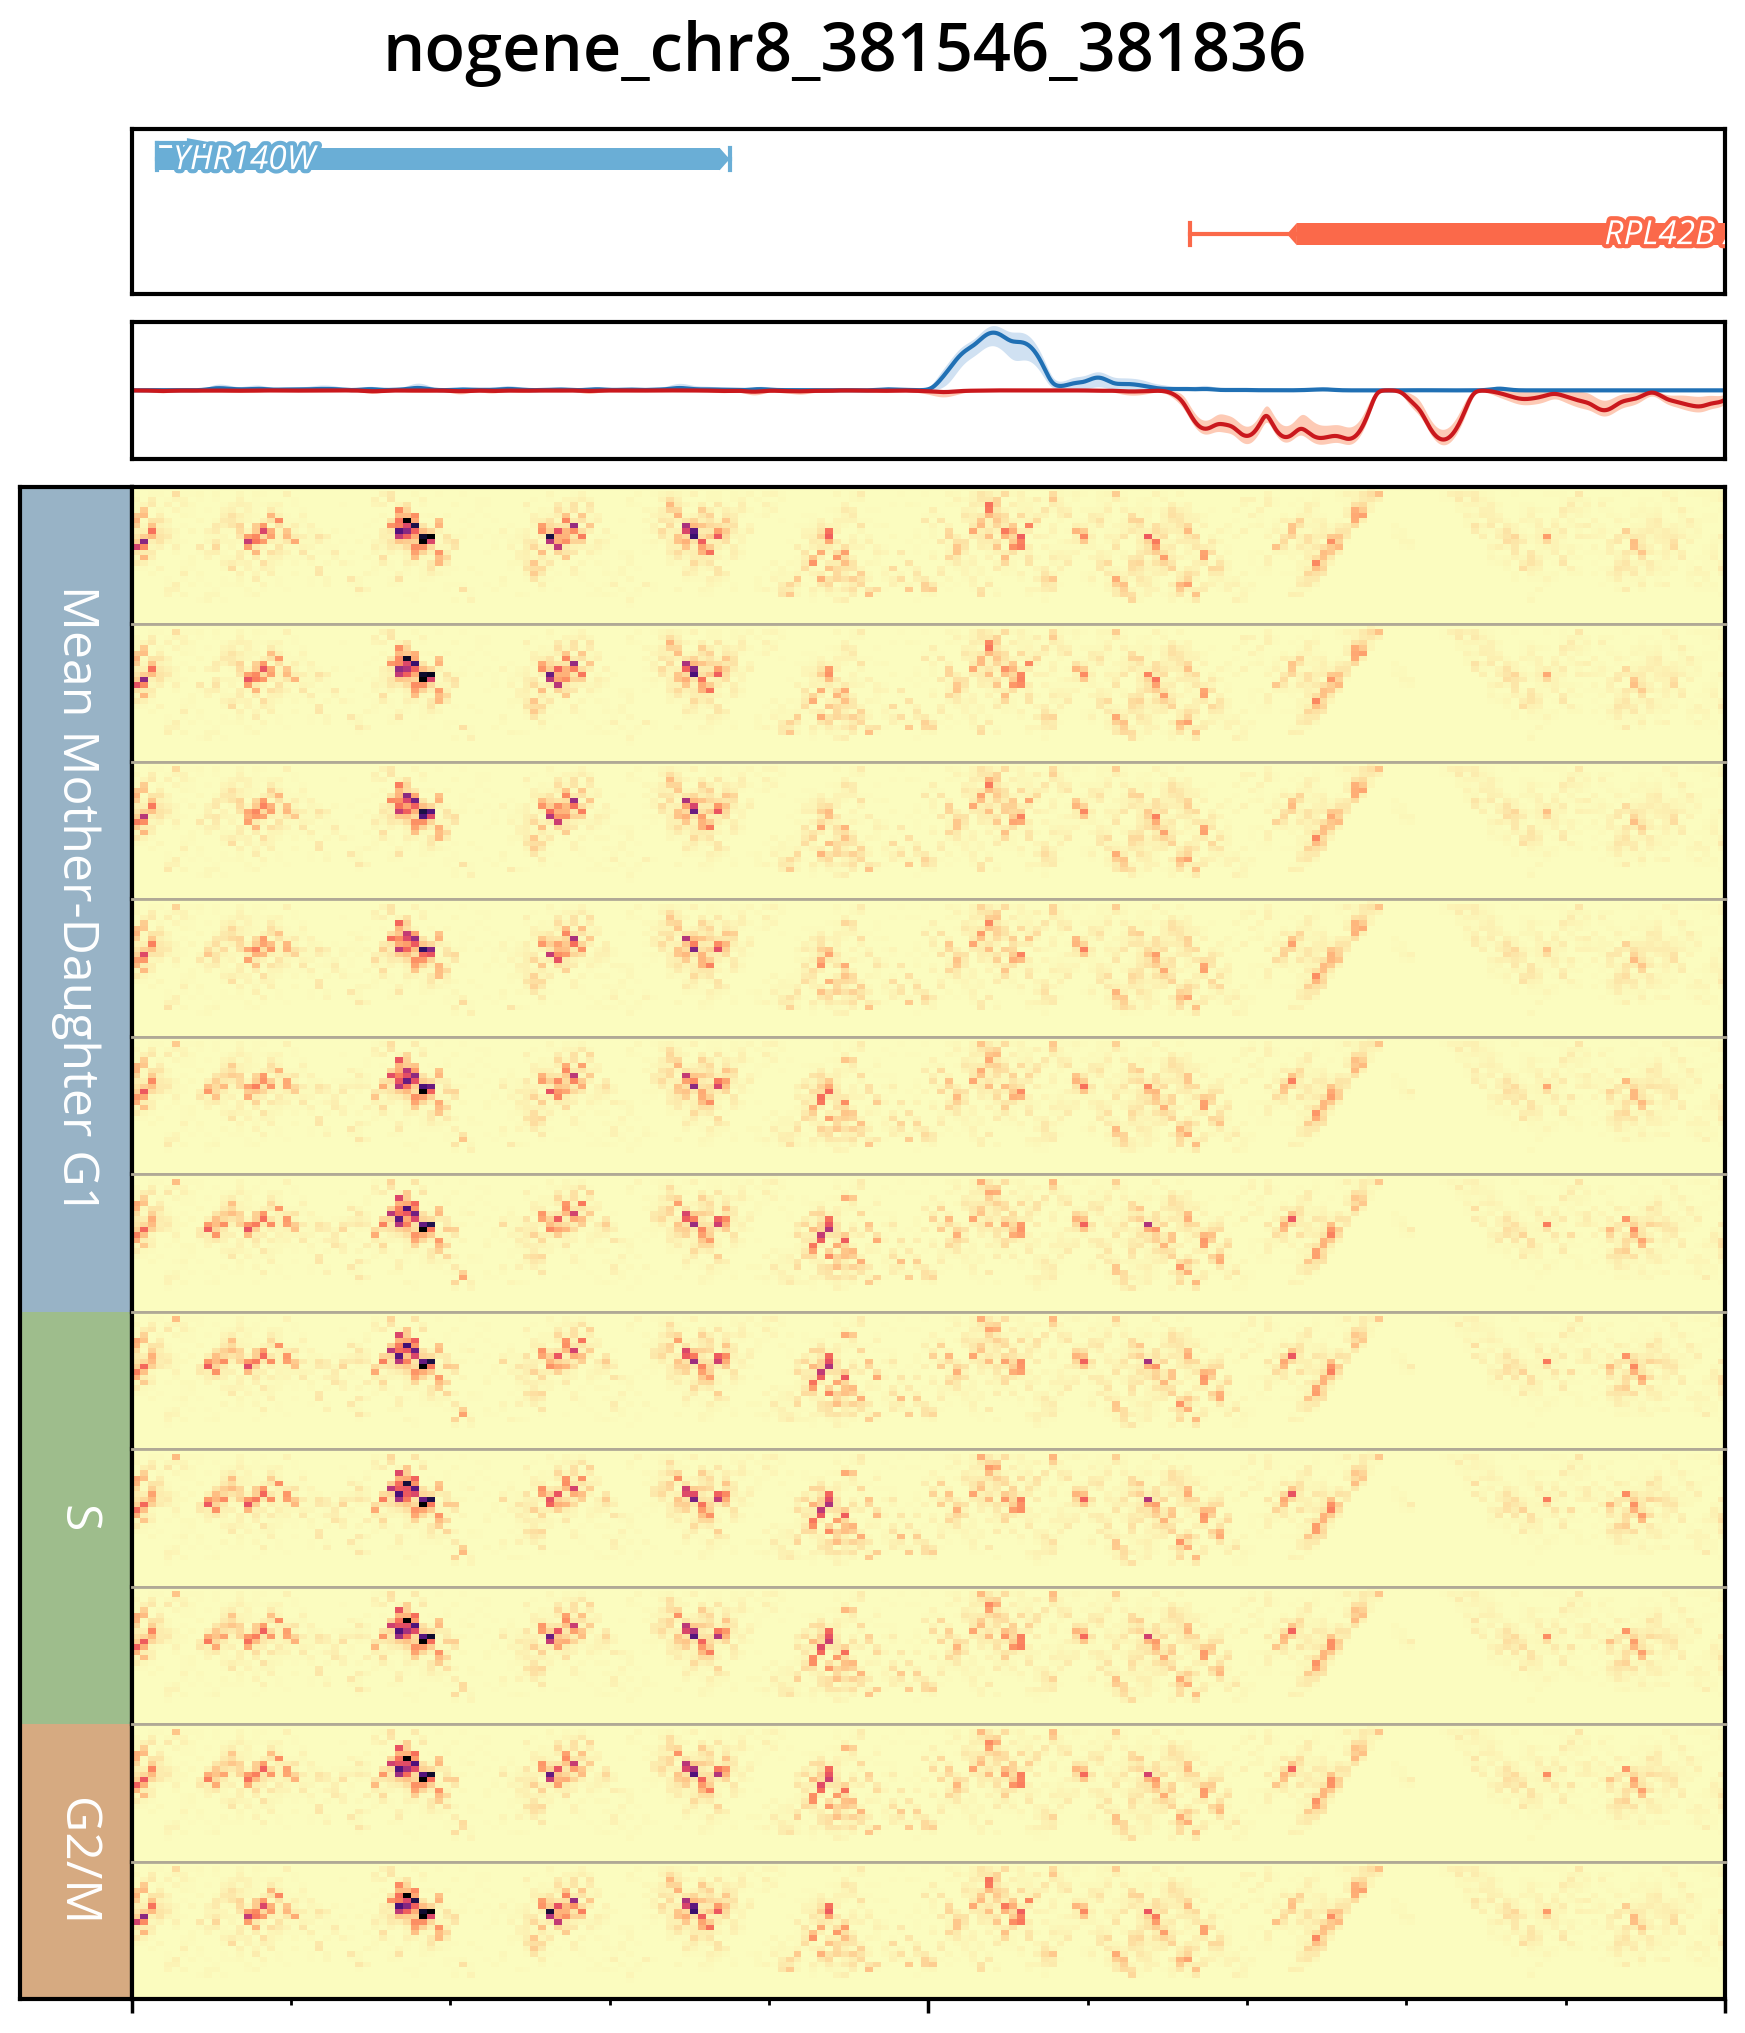

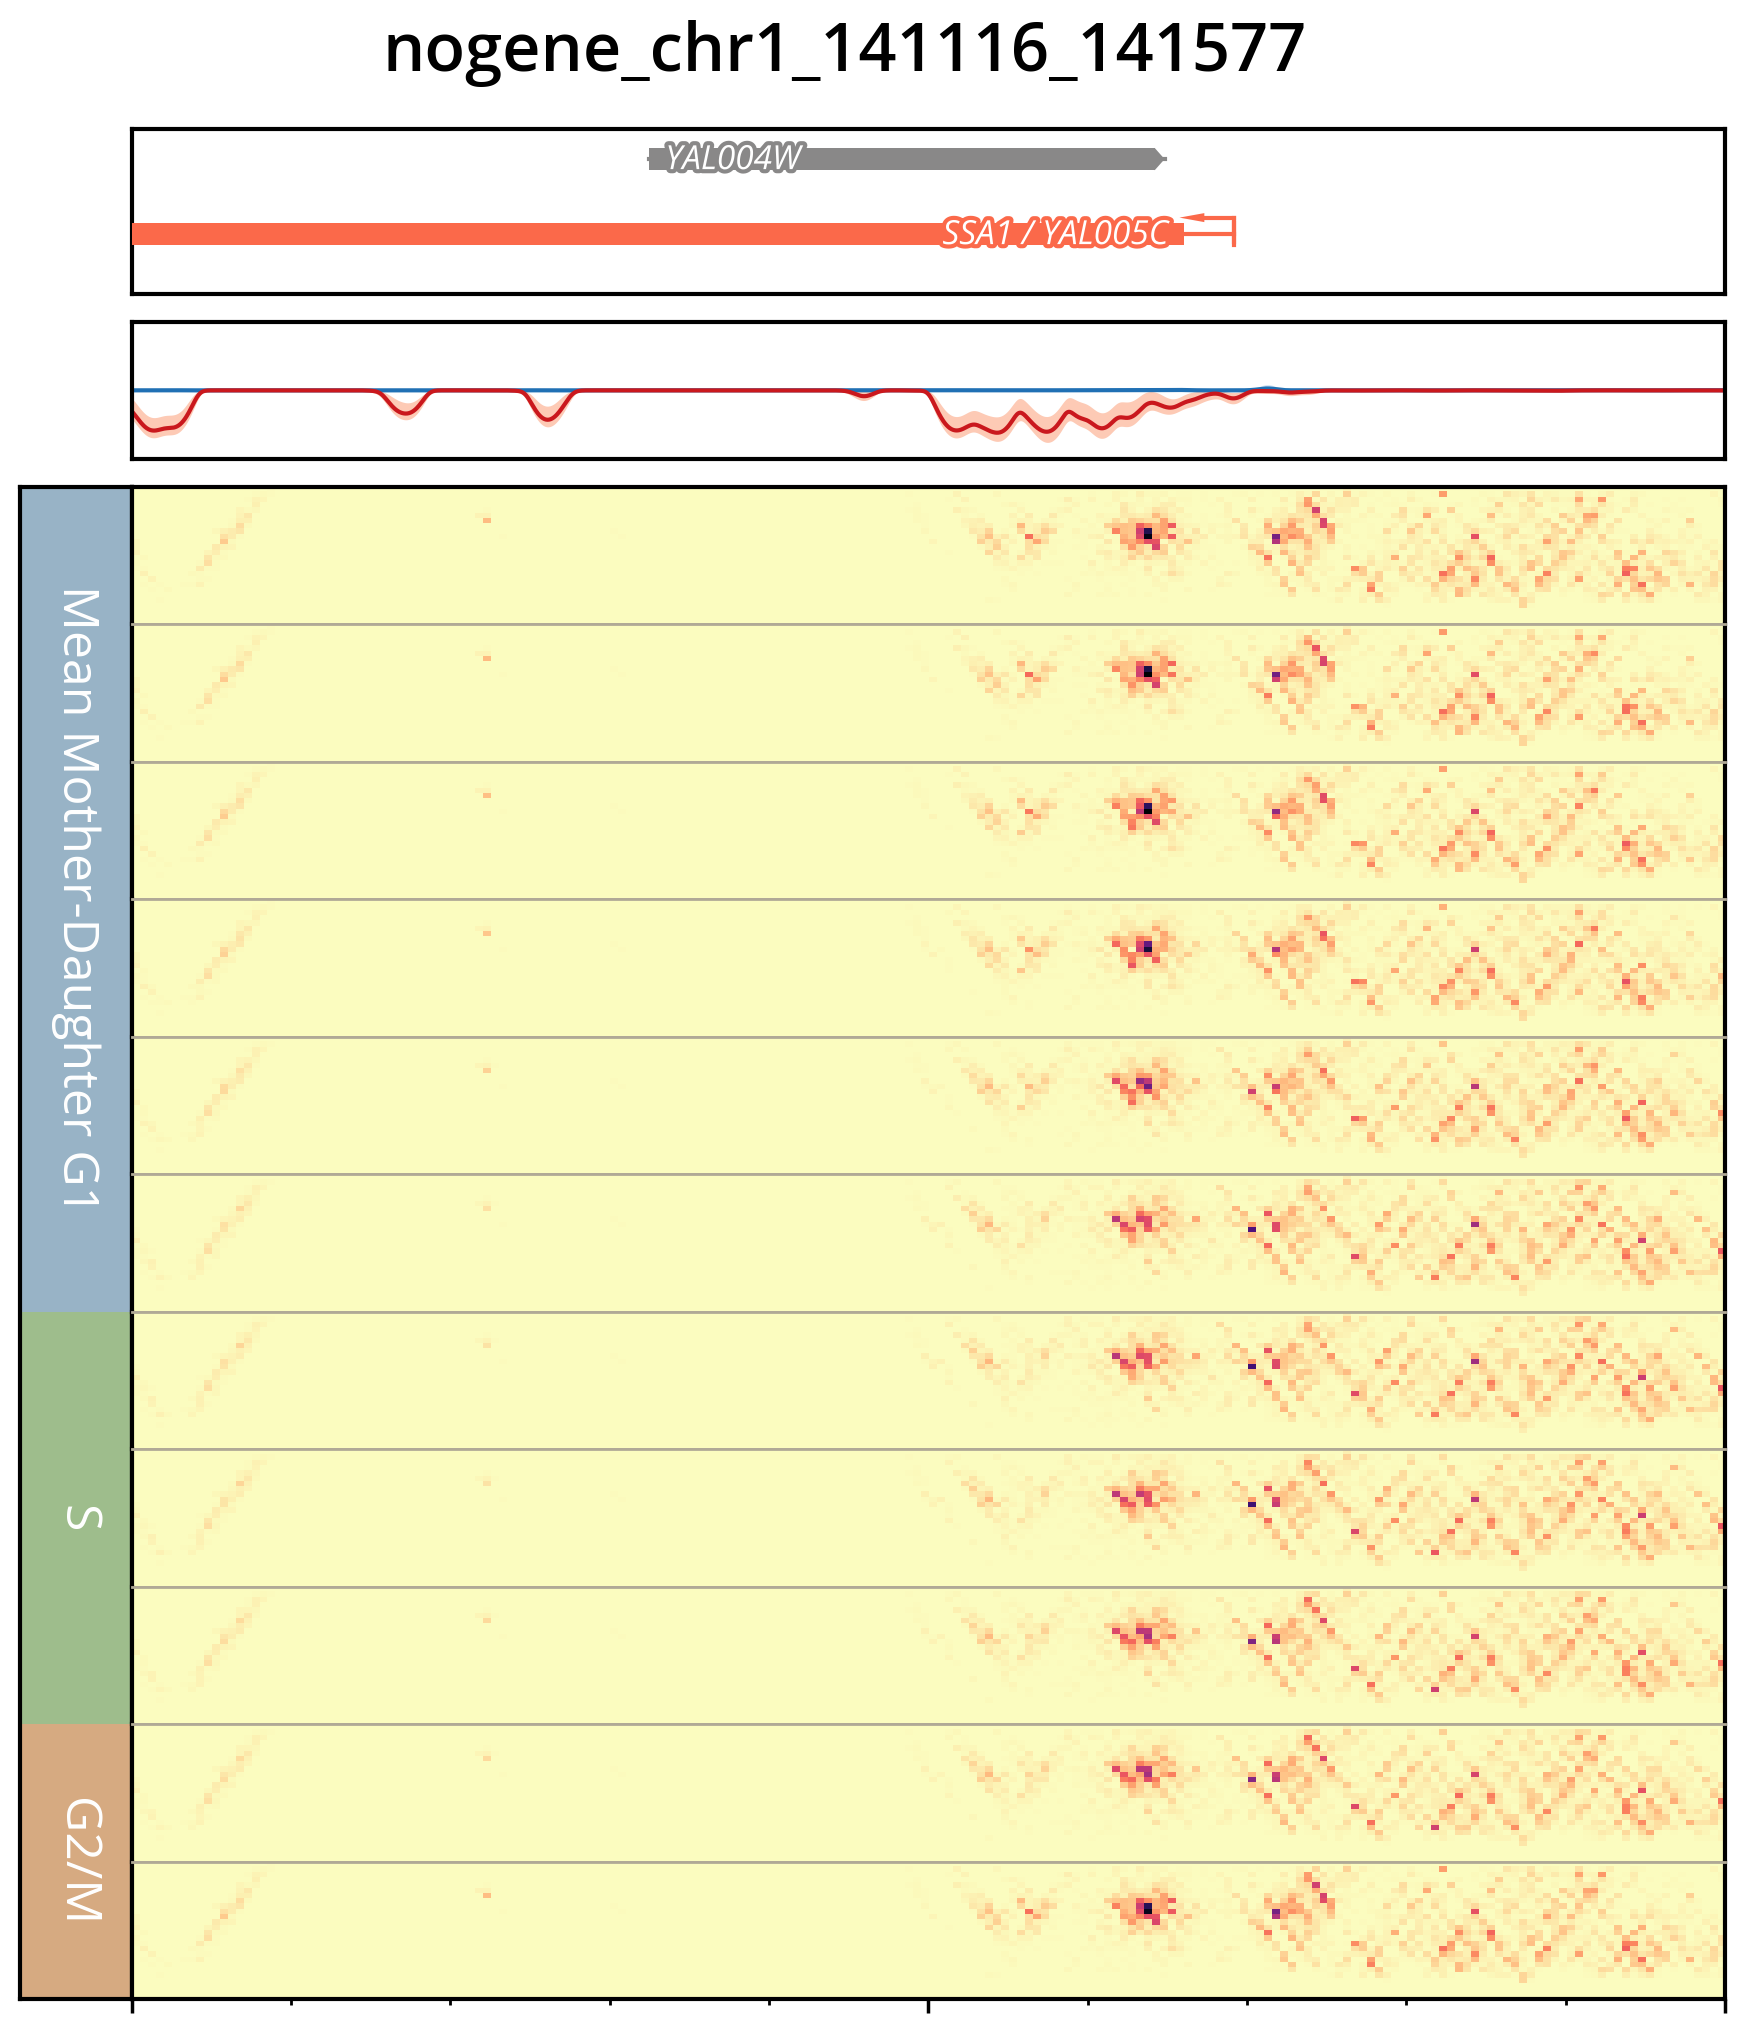

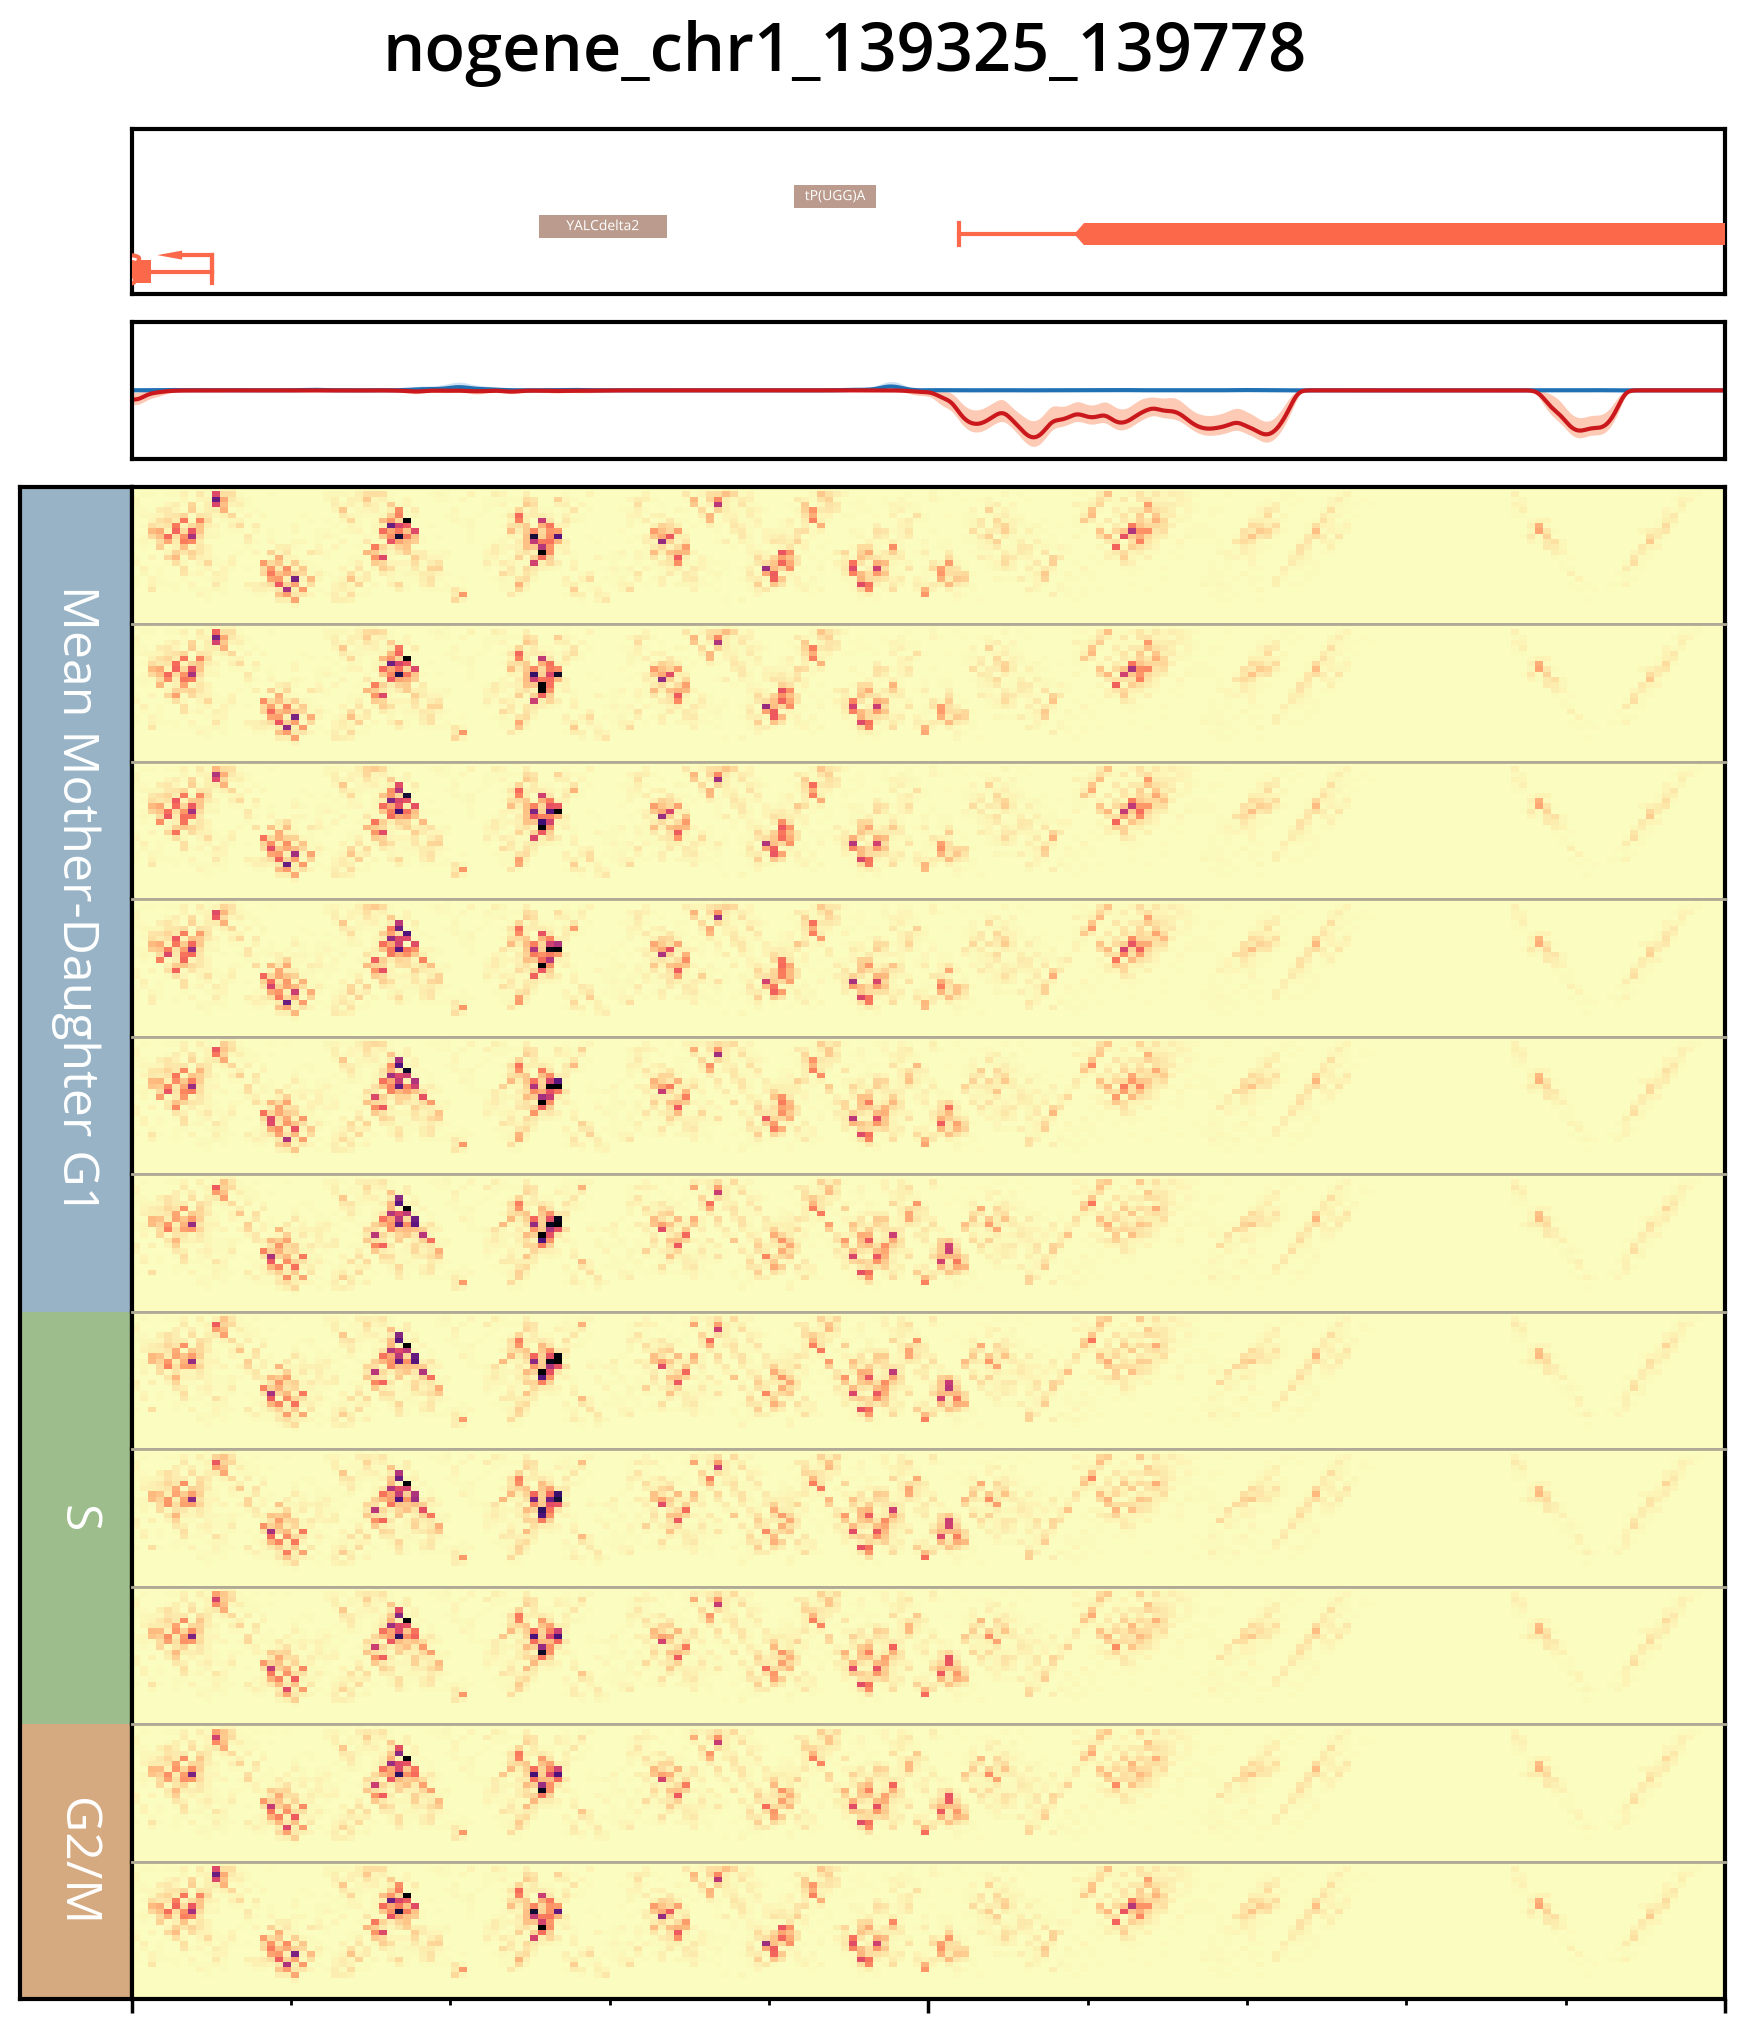

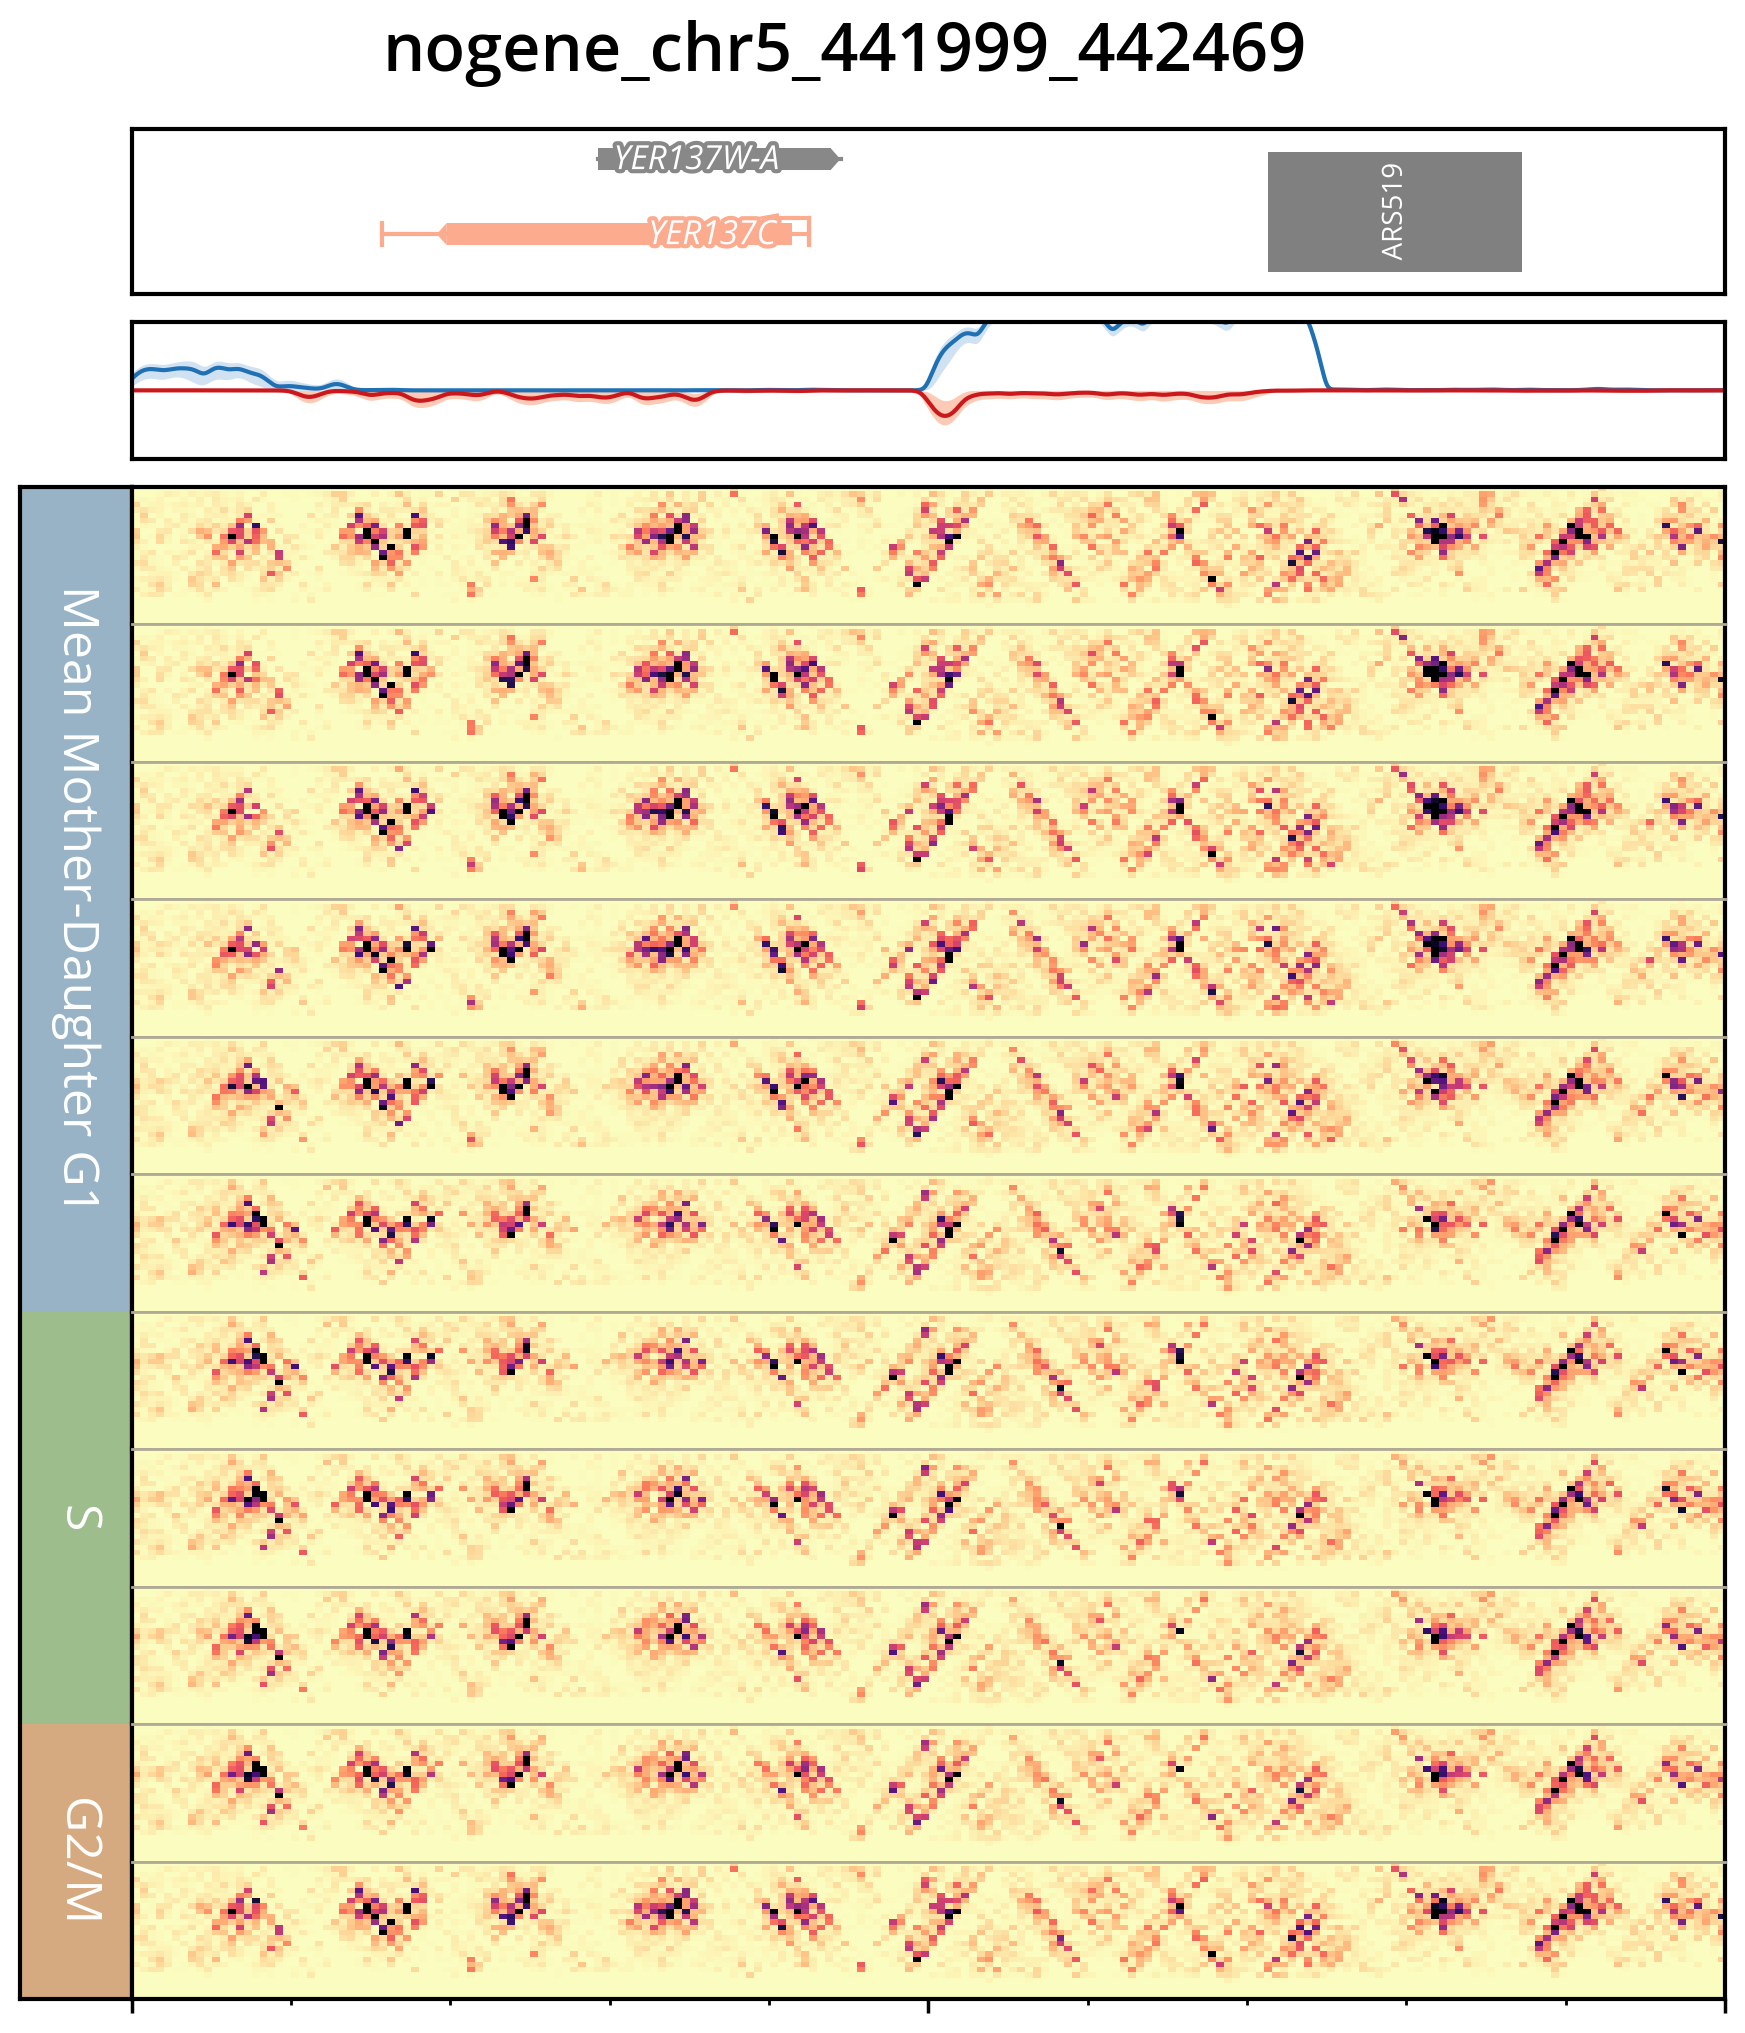

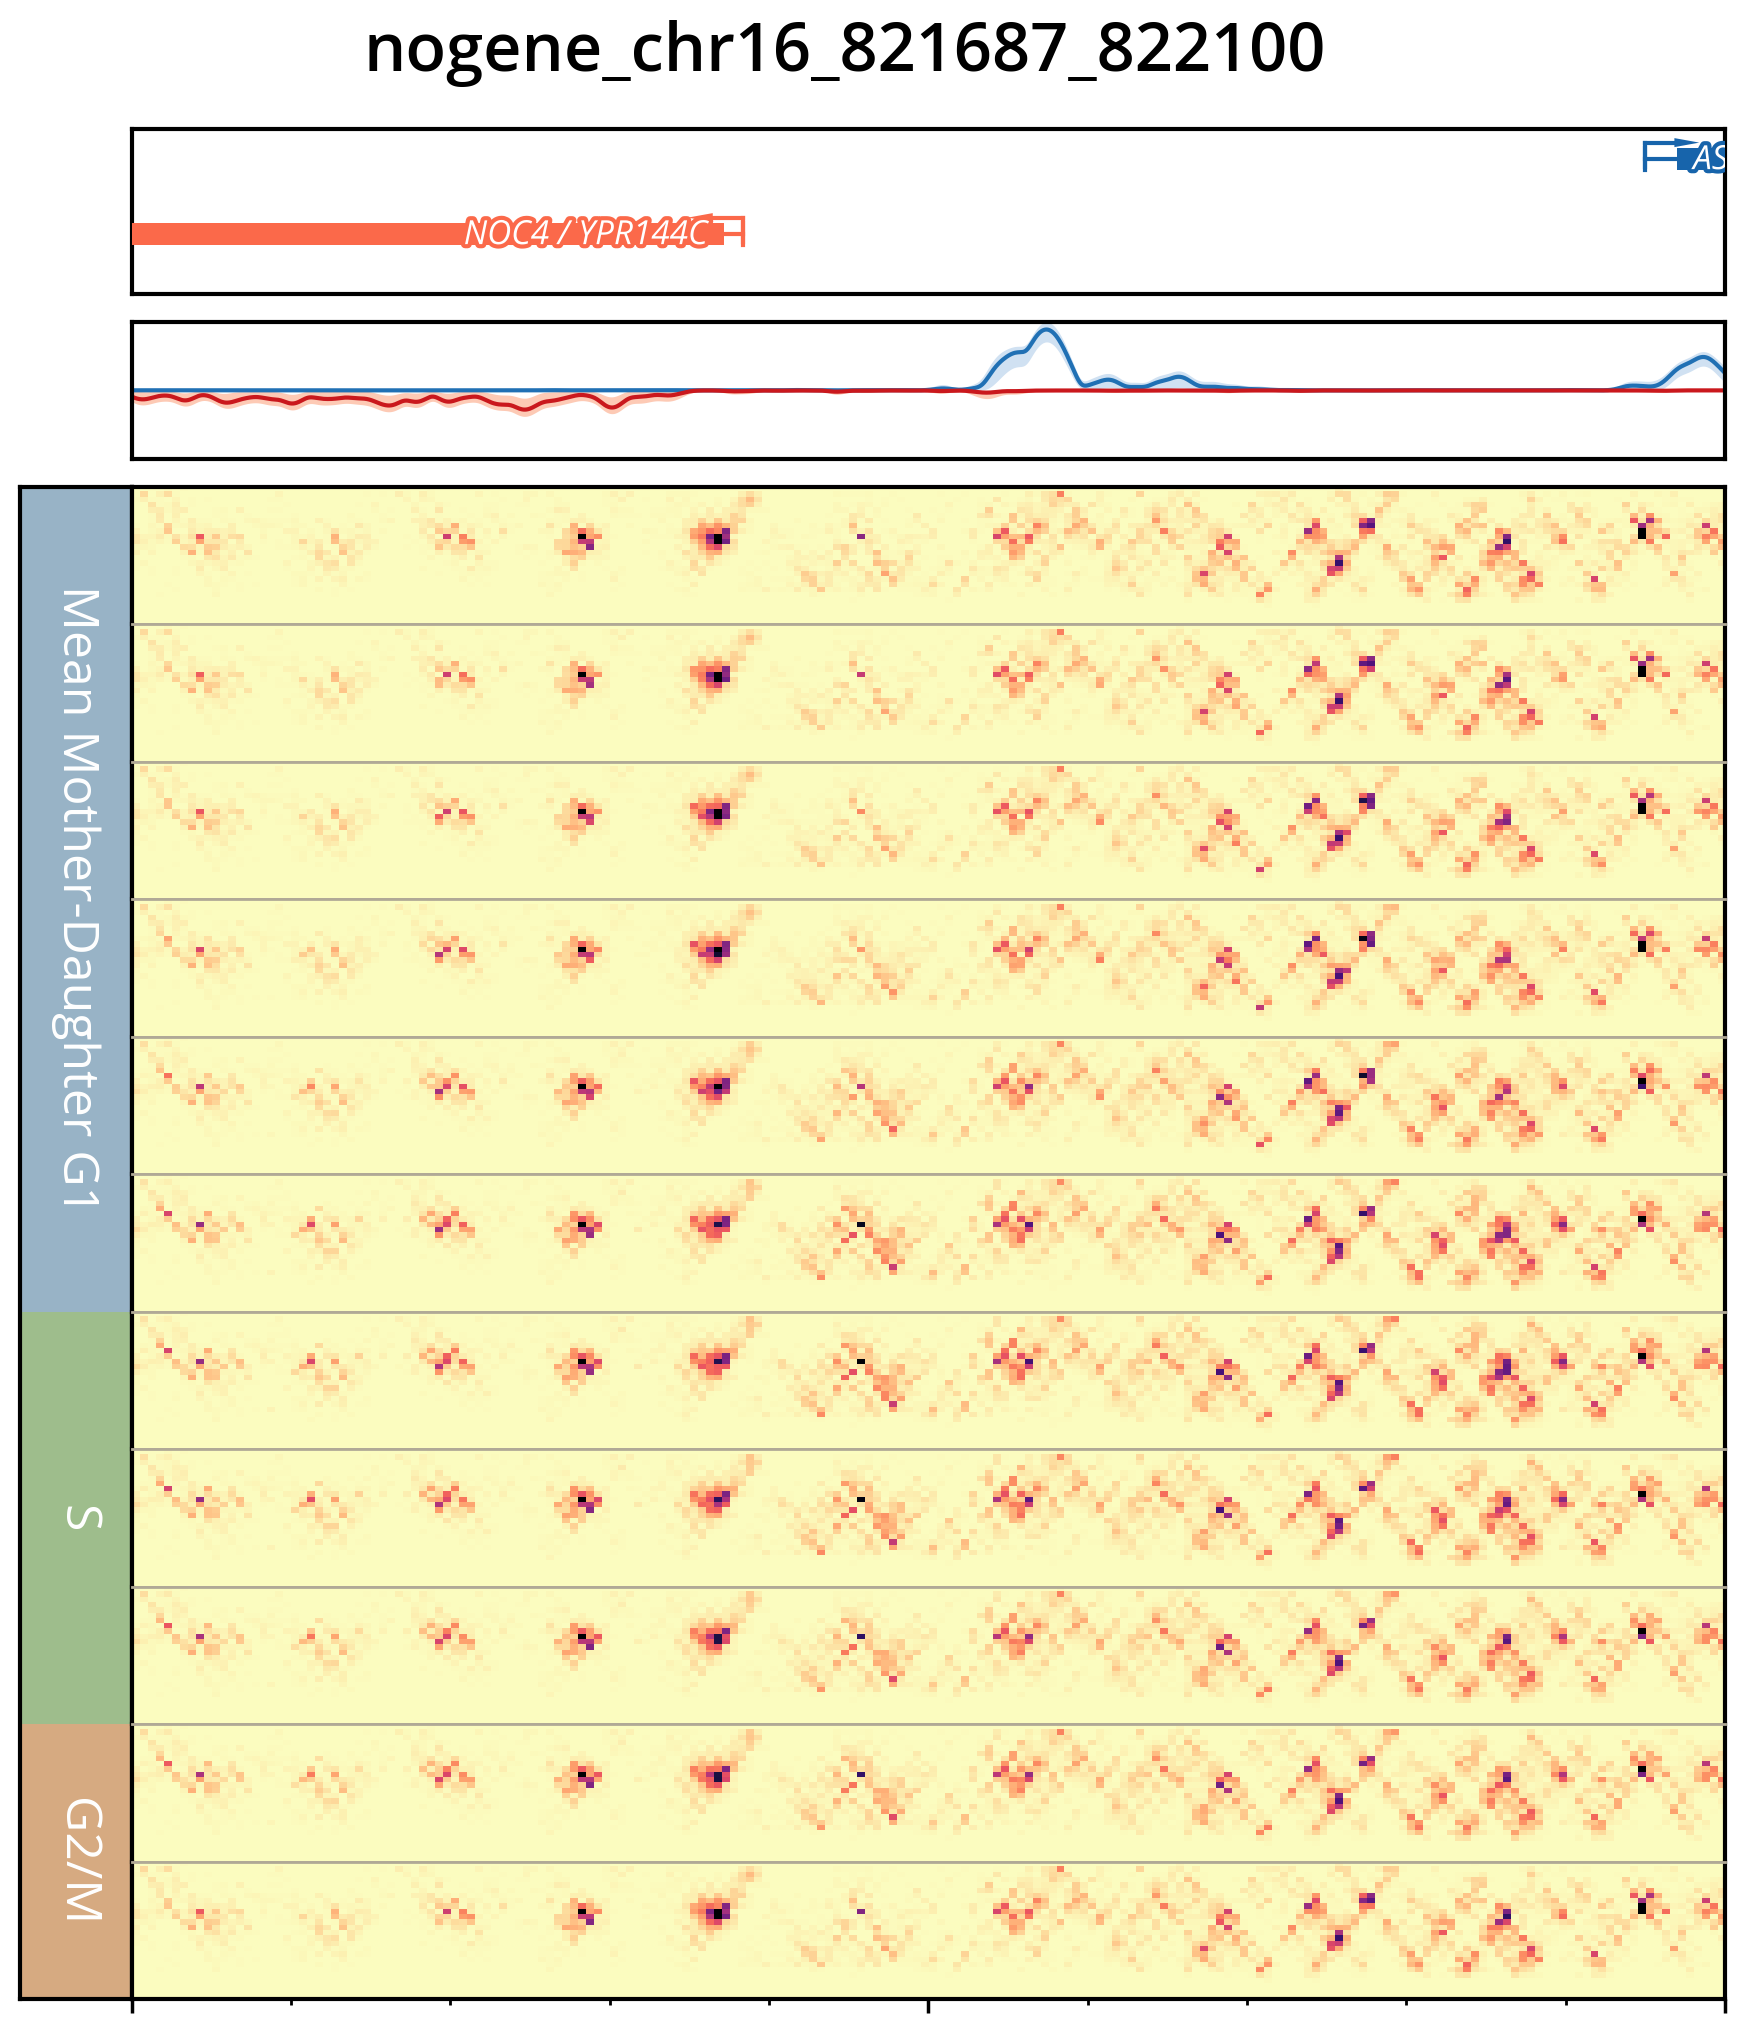

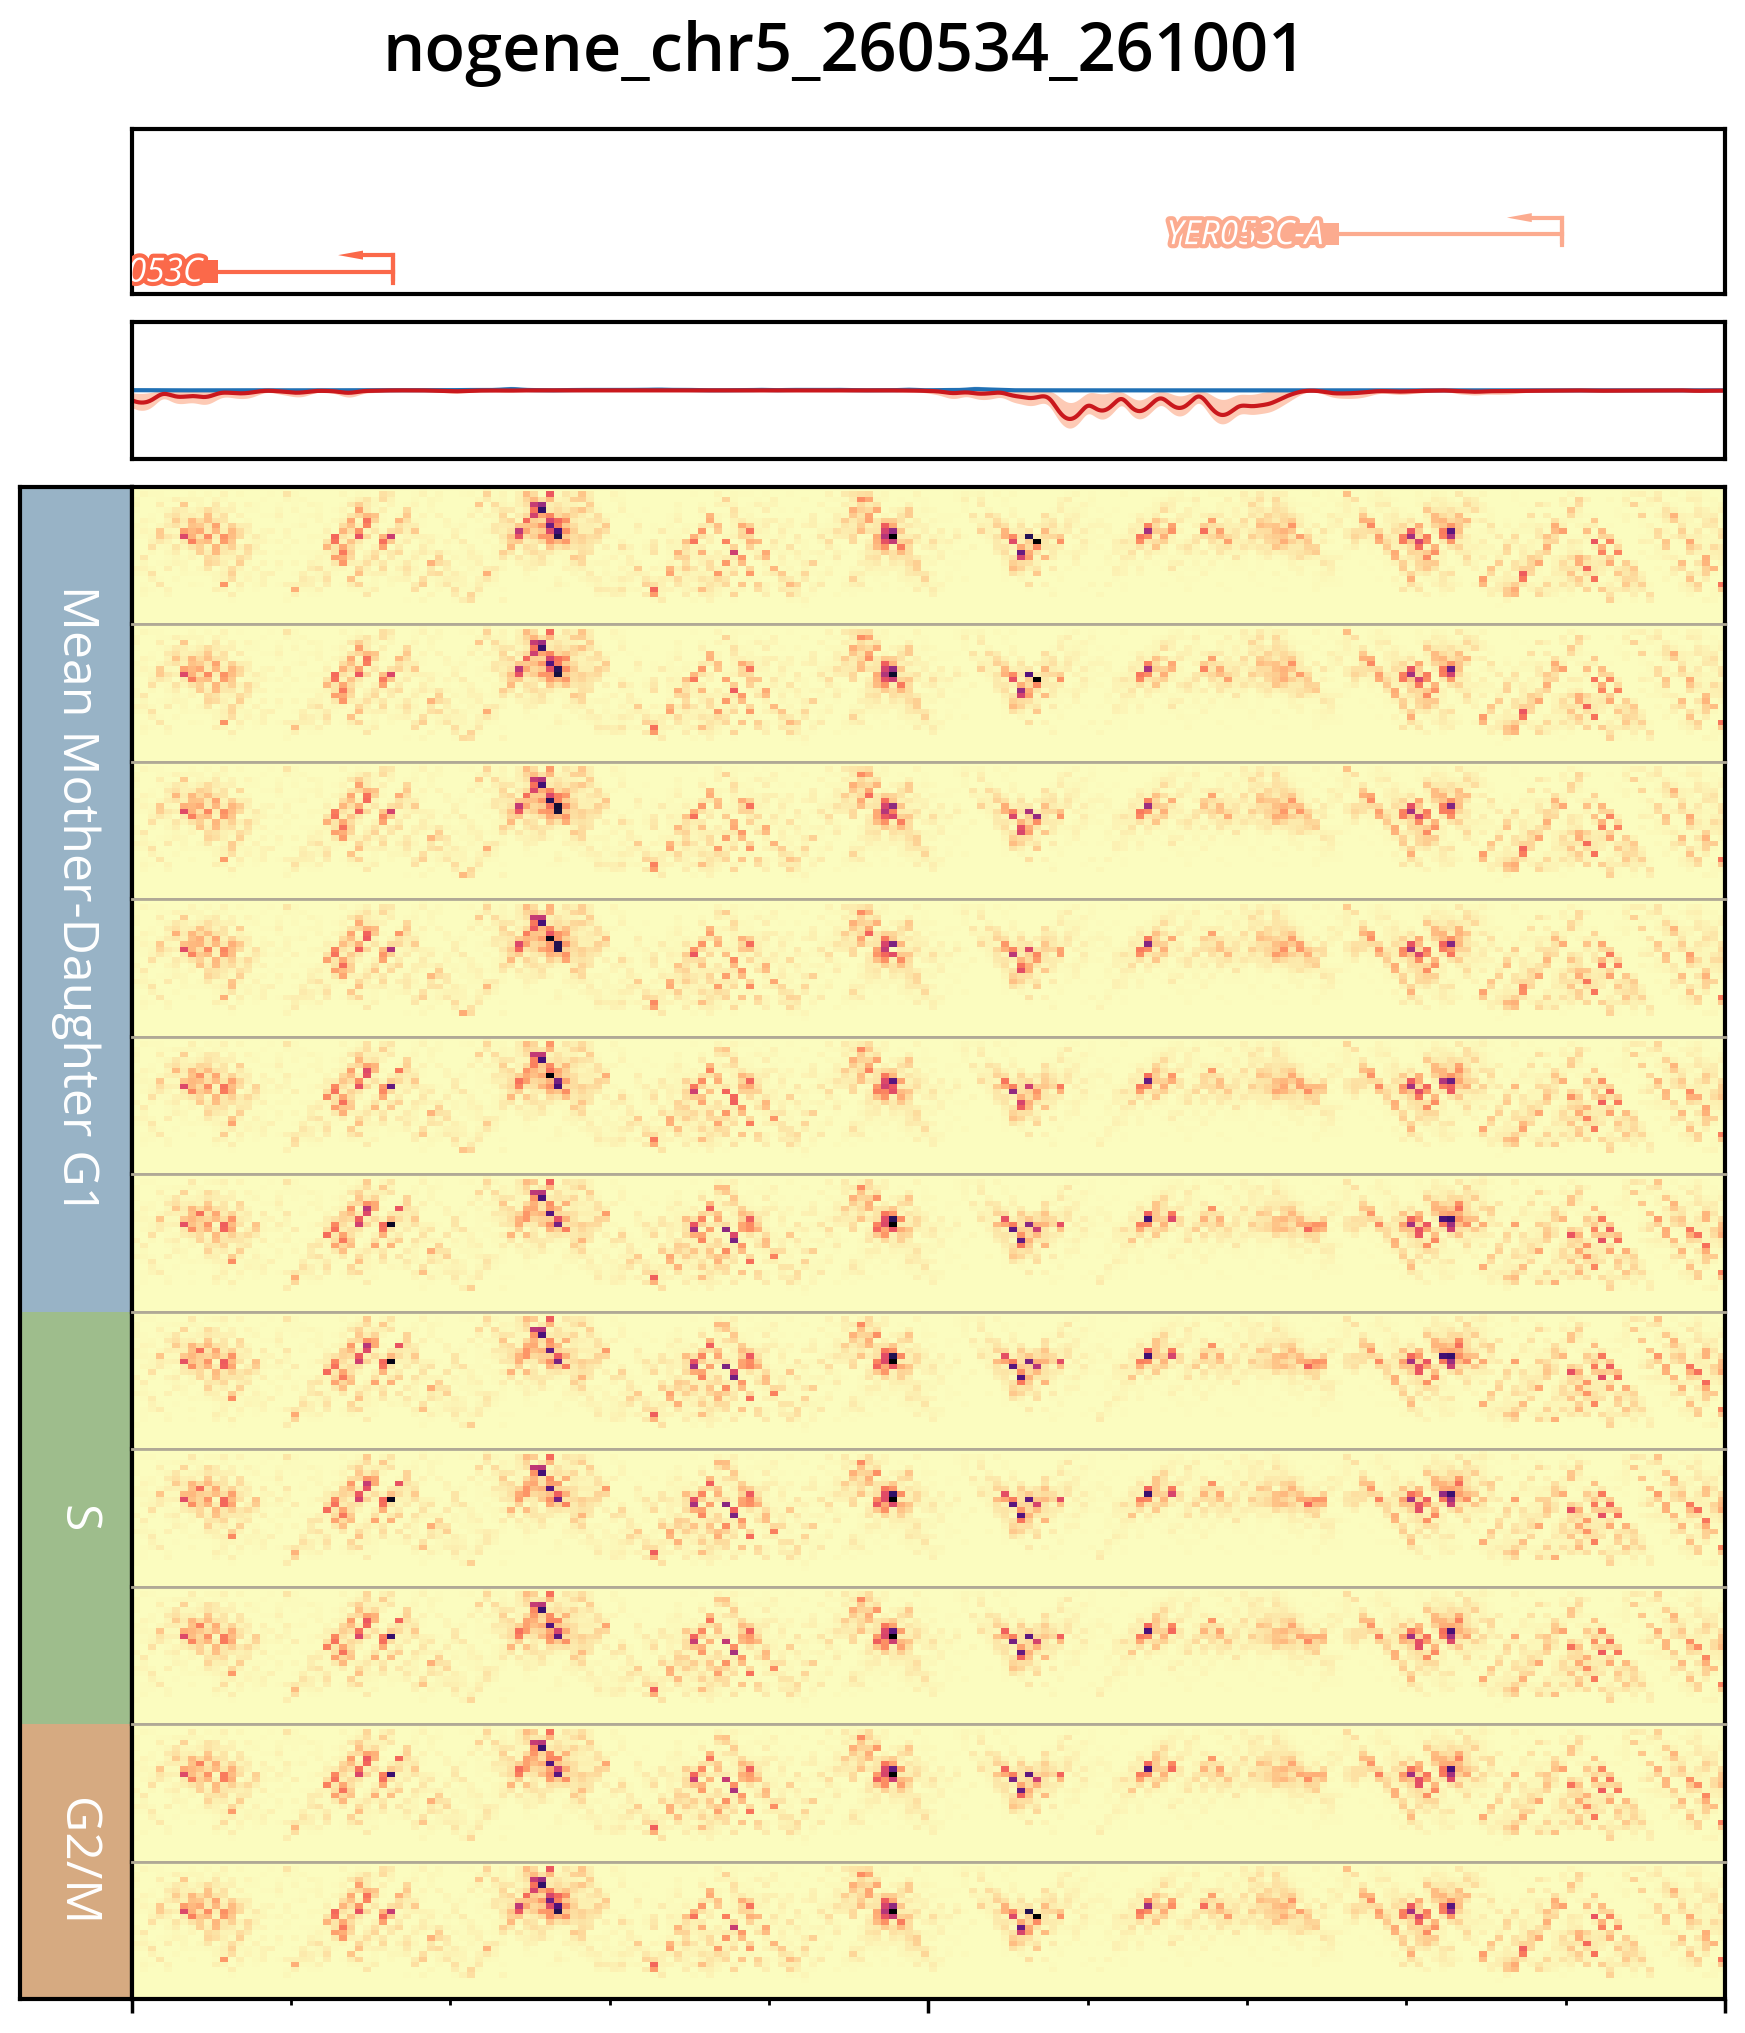

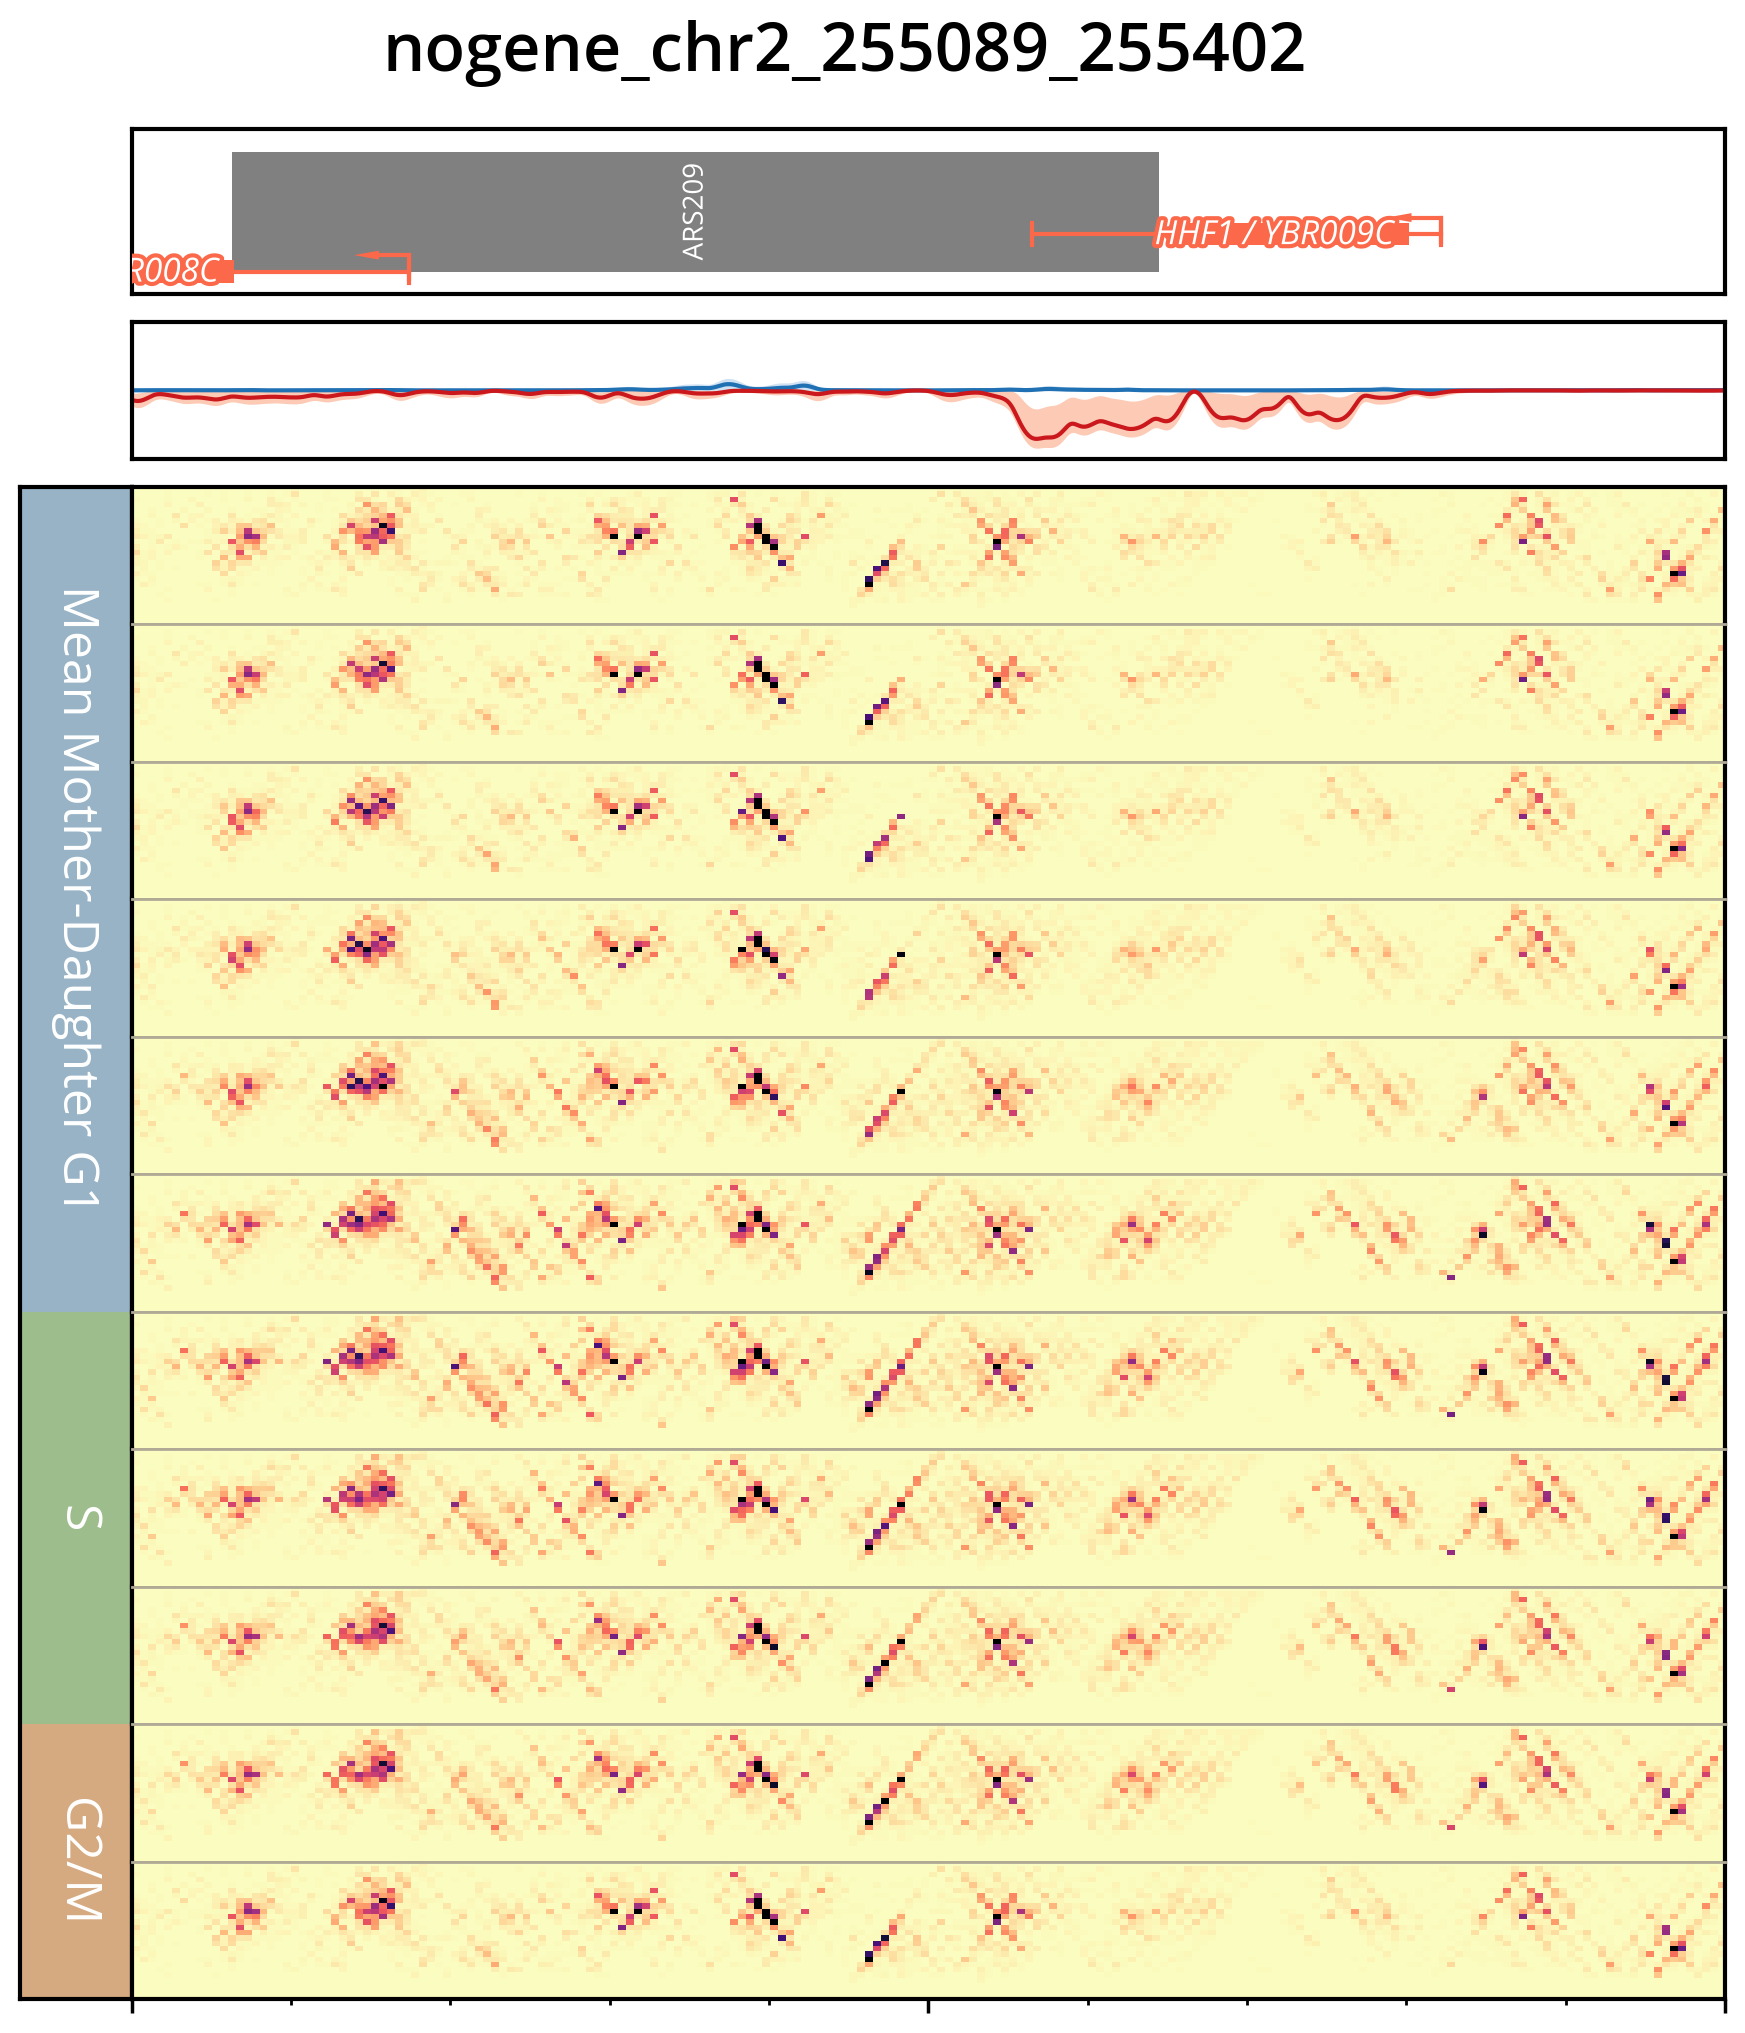

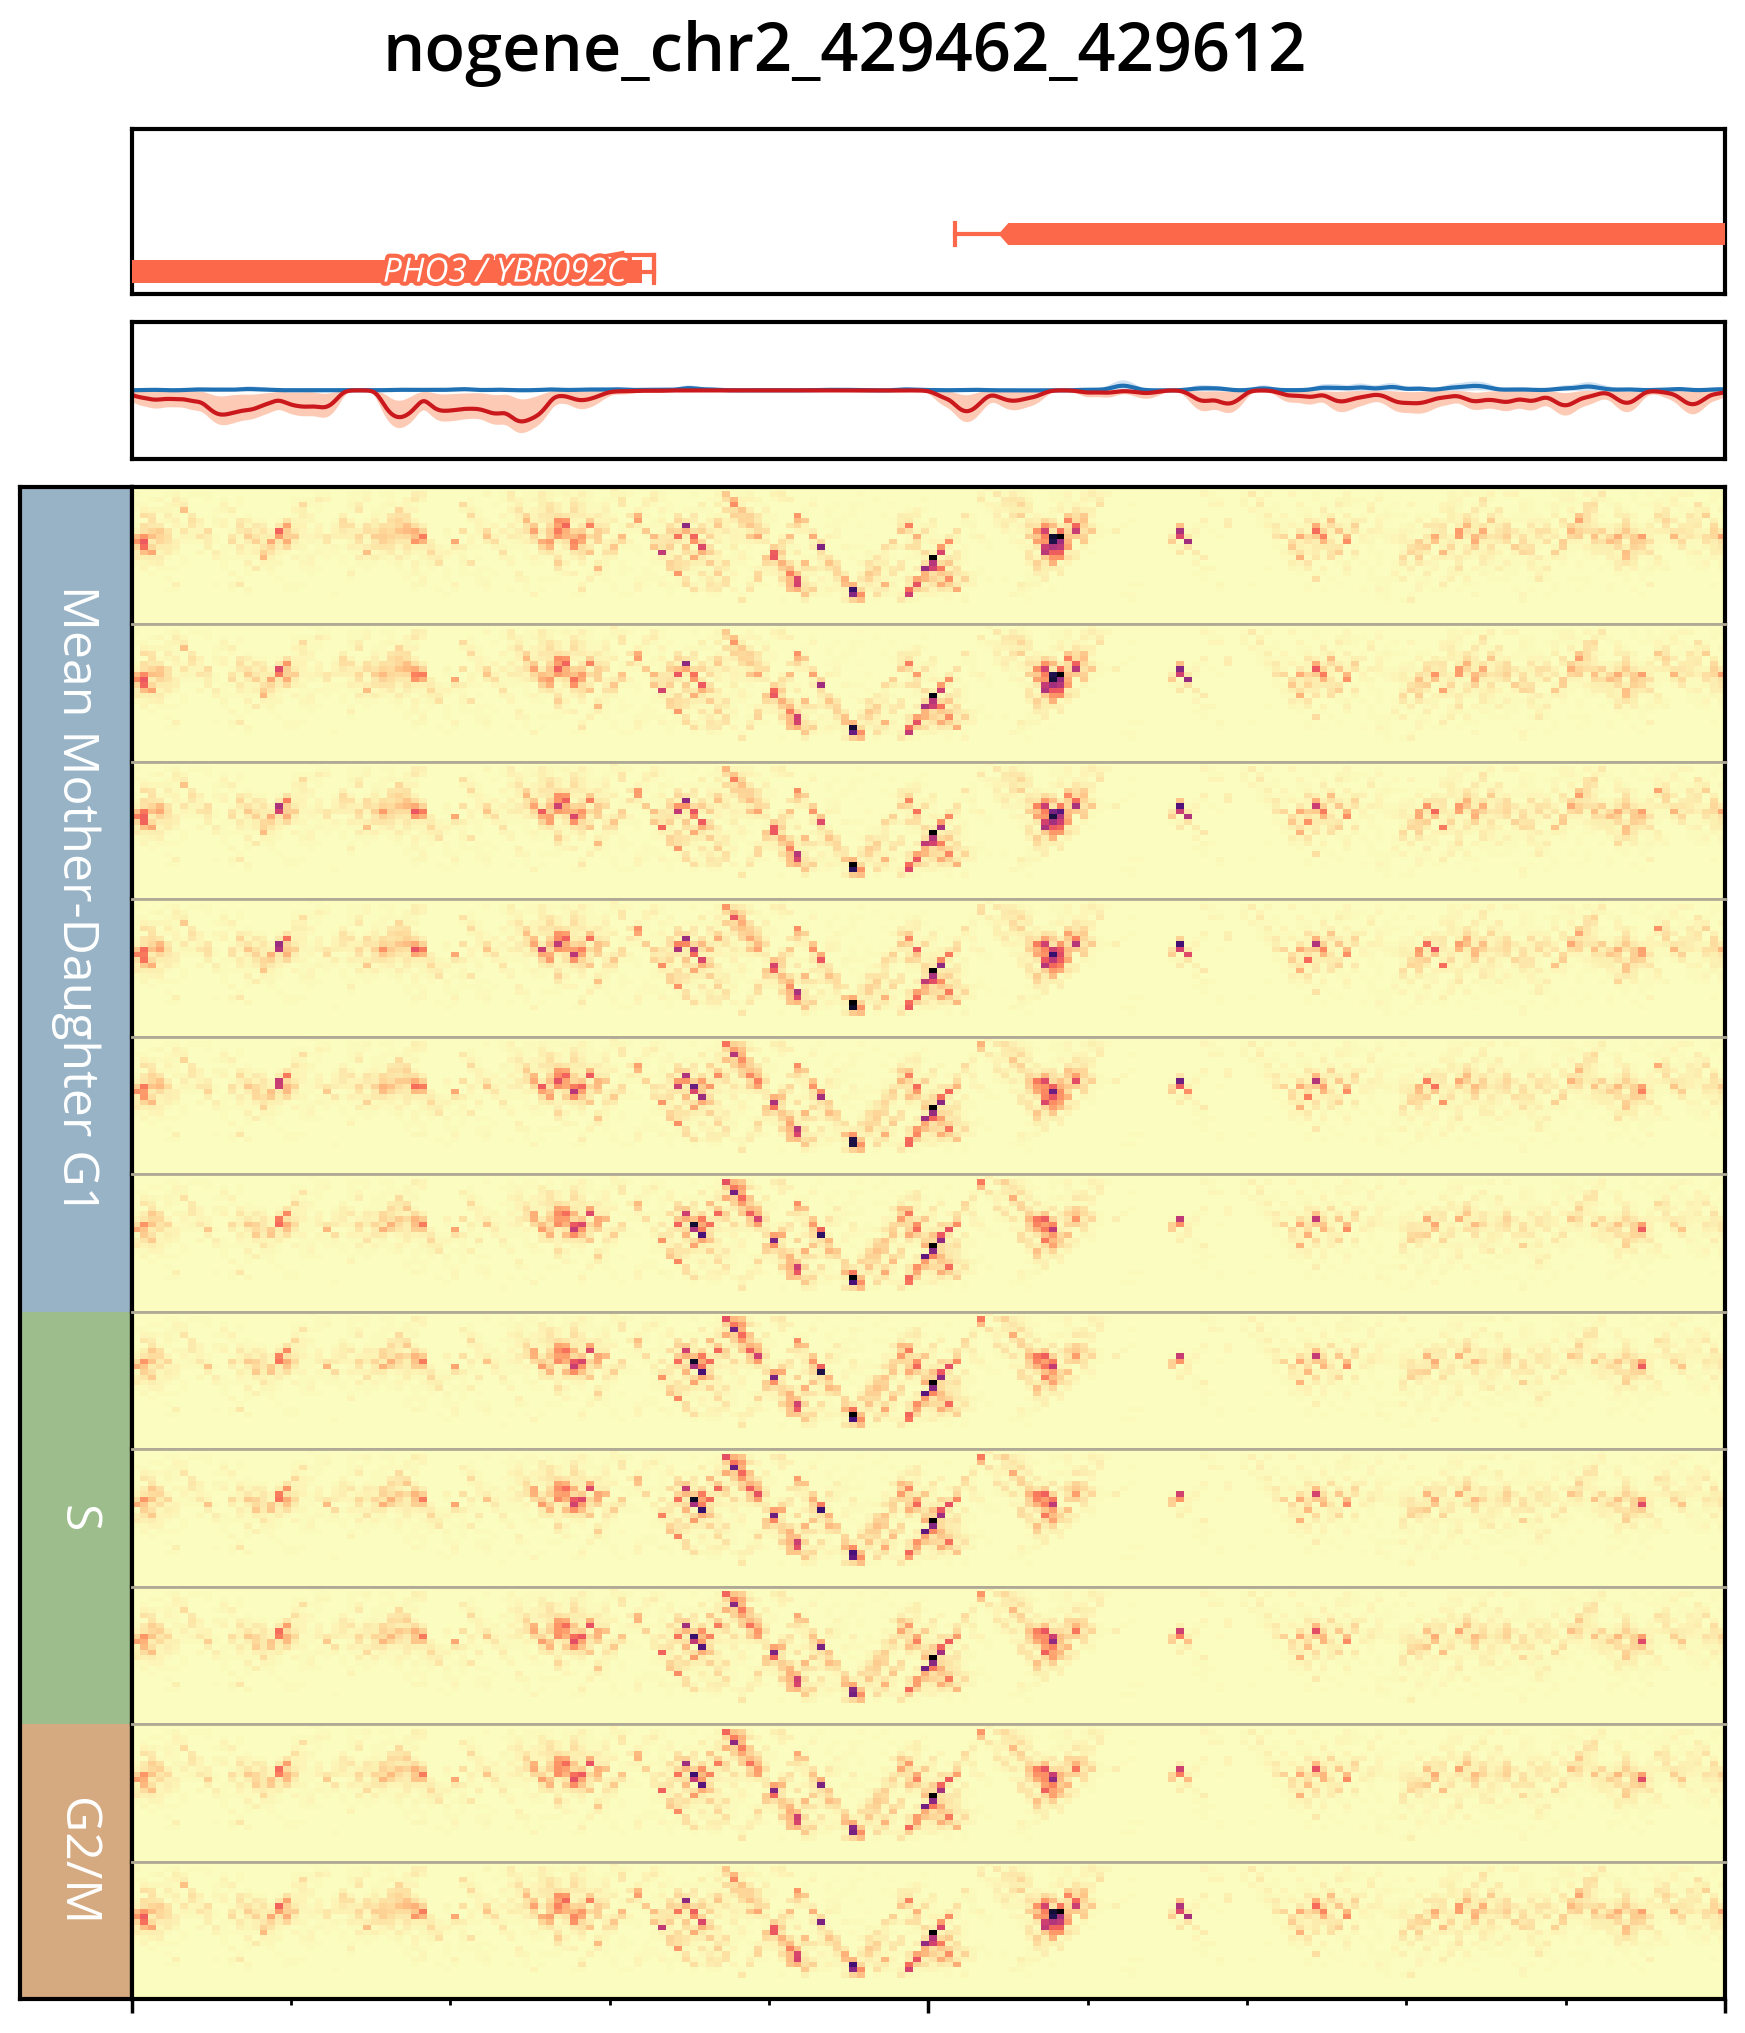

In [211]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_deconv_analysis = GenomeDeconvolutionAnalysis(
    'output/draft4_run/')

for transcript_name, row in selected_data.iterrows():
    transcript_split = transcript_name.split('_')
    chrom = int(transcript_split[1].replace('chr', ''))
    center = (int(transcript_split[2]))

    span = center-1000, center+1000
    loaded_data = genome_deconv_analysis.load_mnase_span(chrom, span)
    genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=transcript_name)


Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 16
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr16.h5, crick_rna_seq_pileup_rep1_chr16.h5
Shape: (16, 948066) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr16.h5, crick_rna_seq_pileup_rep2_chr16.h5
Shape: (14, 948066) (timepoints x positions)
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager 

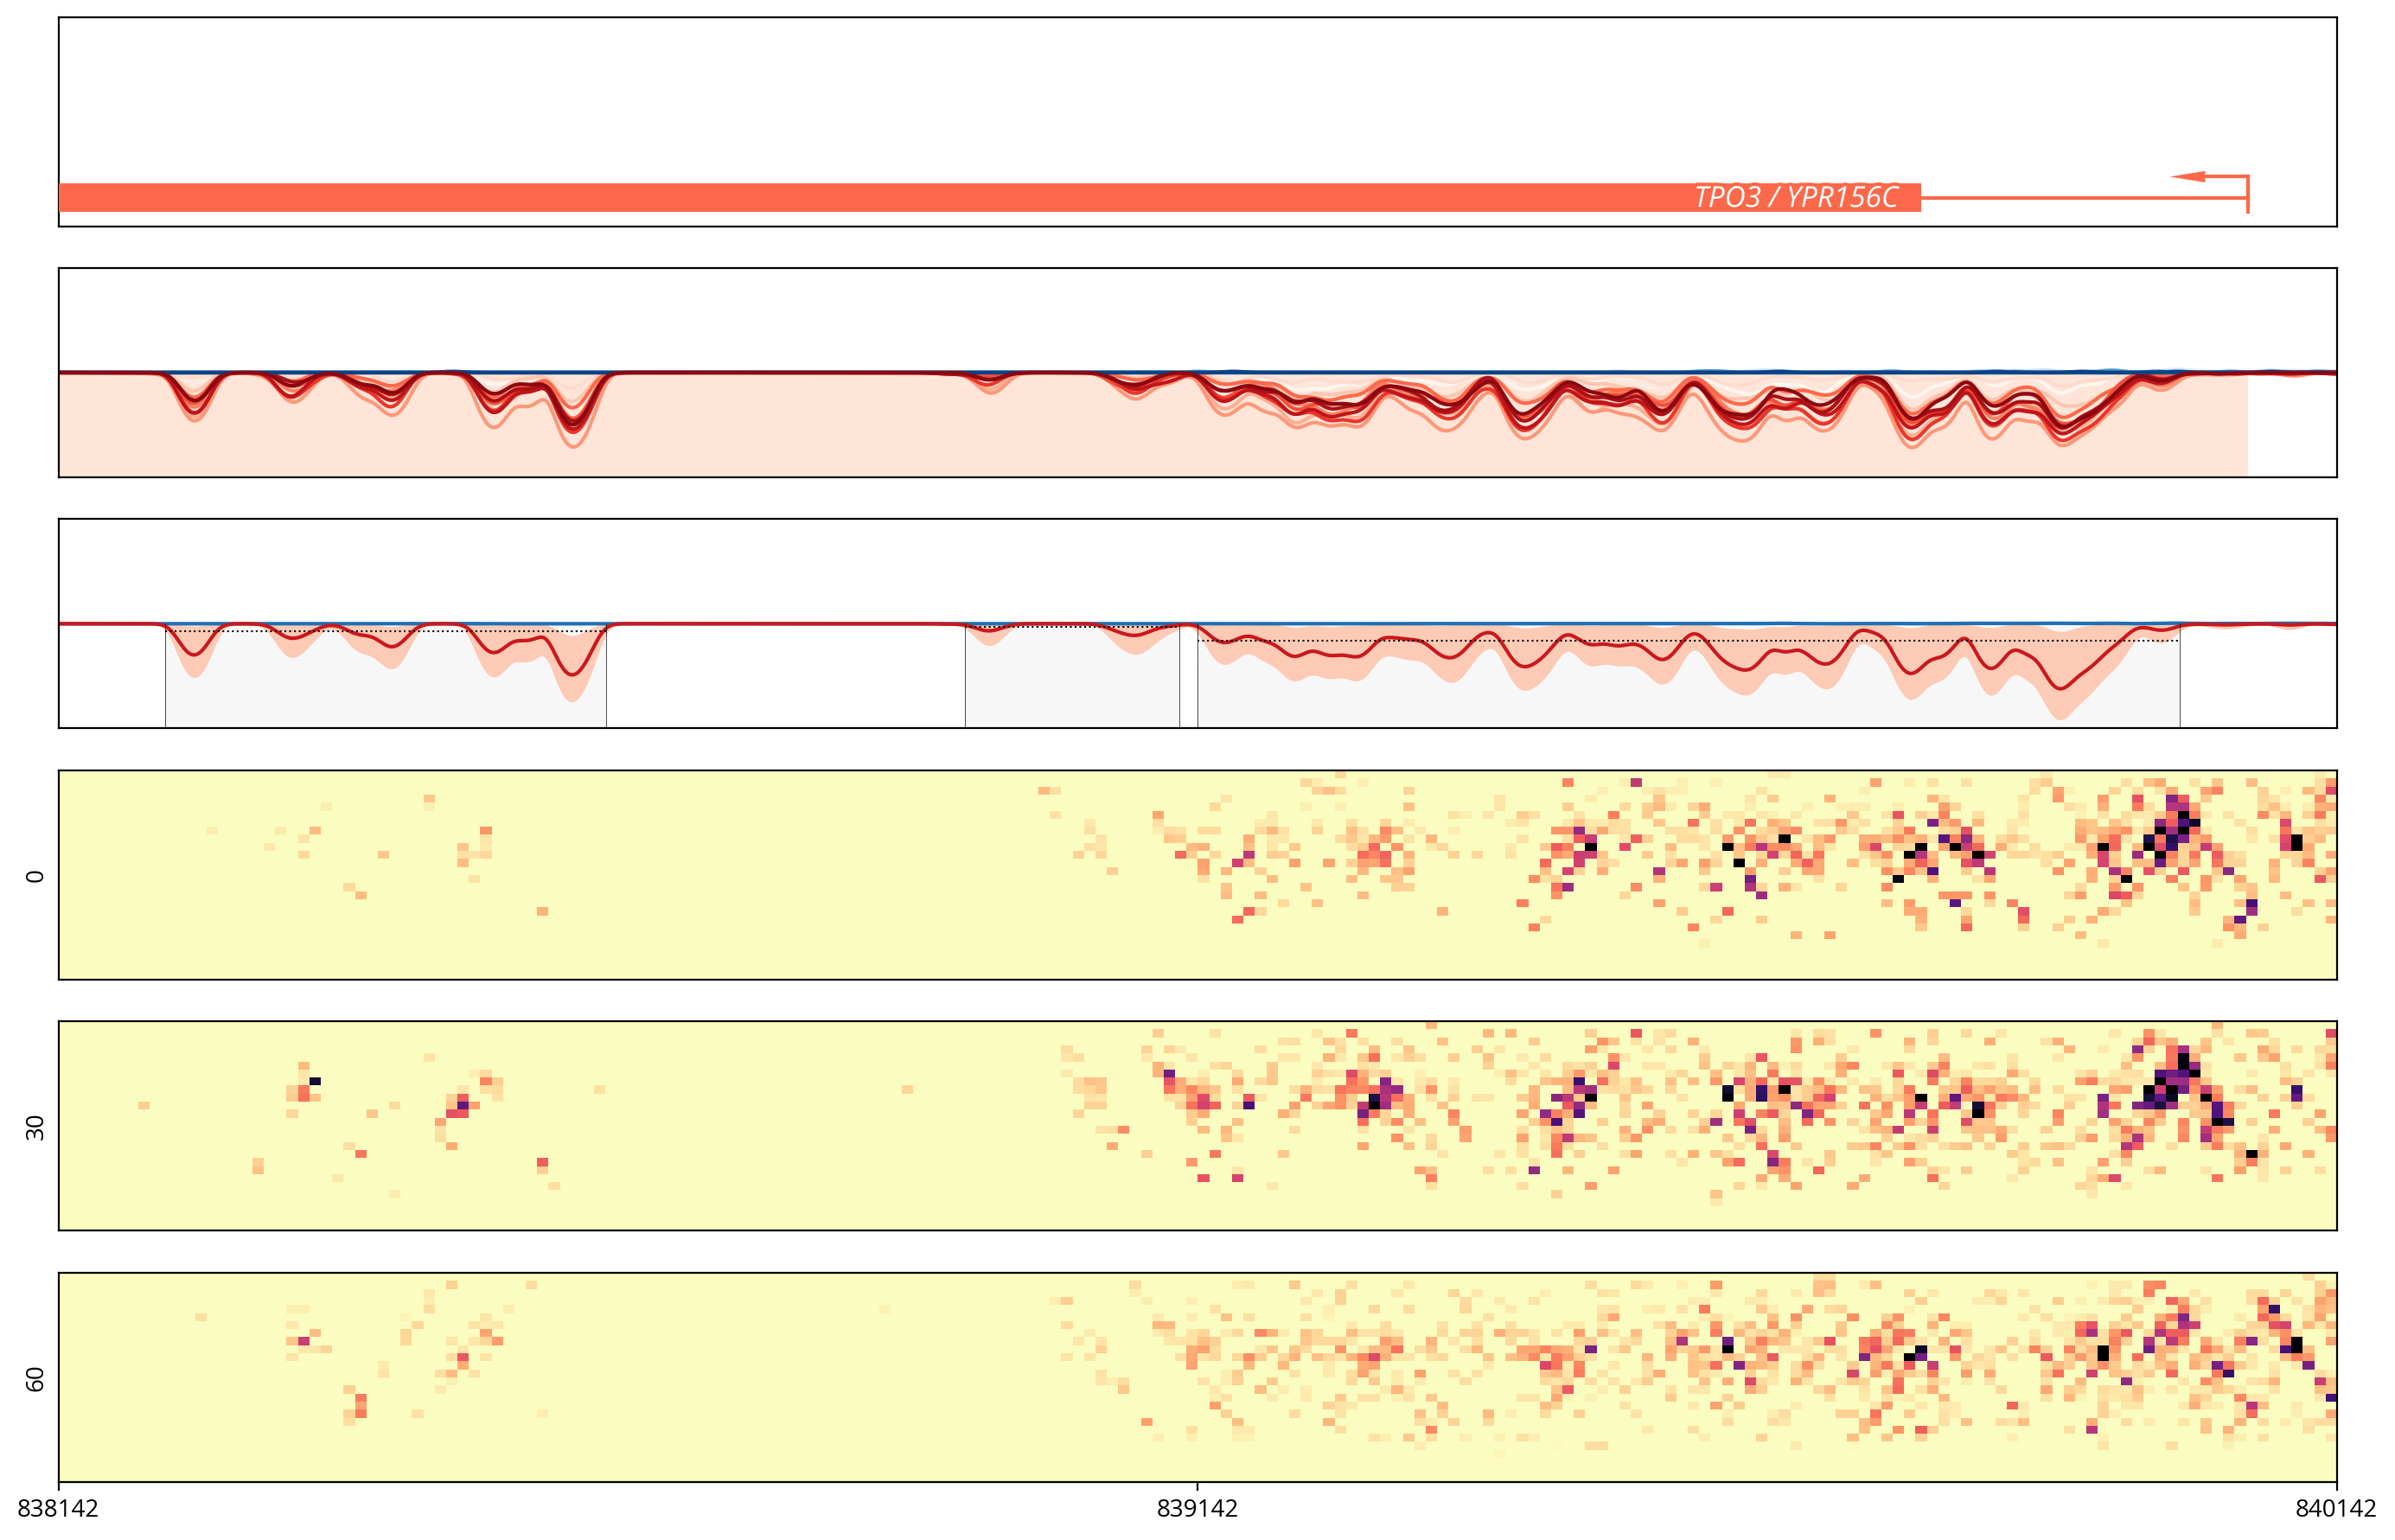

In [271]:
from src.transcript_boundary_caller import TranscriptBoundaryCaller
from src.timer import Timer
from src.transcript_boundary_visualizer import plot_tx_transcript_context

#genes[genes['gene'] == 'CLB5']
# center = 773875
# chrom, span = 16, (center-500, center+6000)

caller = TranscriptBoundaryCaller(output_directory='output/draft4_run/')
caller.set_chrom_span(chrom, span)
caller.call_boundaries_both_strands()

plot_tx_transcript_context(outdir, chrom, span, orf_plotter, rna_plotter, 
                           combined_model, caller)


In [222]:
tx_set = expression_processor.all_transcripts_set
filtered_for_region = tx_set[(tx_set.transcript_class == 'nongenic') & (tx_set.chr == chrom) &
       (tx_set.start > span[0]) &
       (tx_set.stop < span[1])]
filtered_for_region

,transcript_class,chr,strand,start,stop,length,promoter_start,promoter_end,gene_body_start,gene_body_end
nogene_chr16_773630_773779,nongenic,16,+,773630,773779,149,773330,773630,773630,774130
nogene_chr16_776111_776349,nongenic,16,+,776111,776349,238,775811,776111,776111,776611
nogene_chr16_775960_776826,nongenic,16,-,775960,776826,866,777126,776826,776826,776326


In [227]:
expression_processor.all_transcripts_ptrs.loc[filtered_for_region.index]

,ptr,transcript_class
nogene_chr16_773630_773779,1.646173,nongenic
nogene_chr16_776111_776349,1.499436,nongenic
nogene_chr16_775960_776826,1.003518,nongenic


In [230]:
high_quantile_expression.loc[filtered_for_region.index]

,0.9
nogene_chr16_773630_773779,2.976835
nogene_chr16_776111_776349,1.967949
nogene_chr16_775960_776826,1.387039


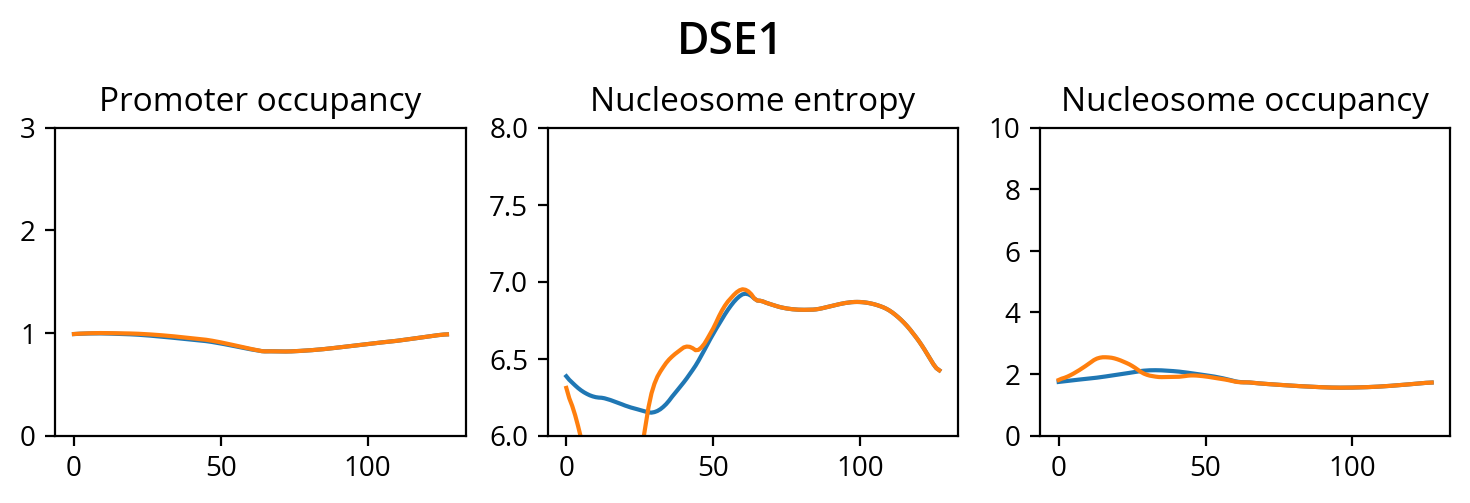

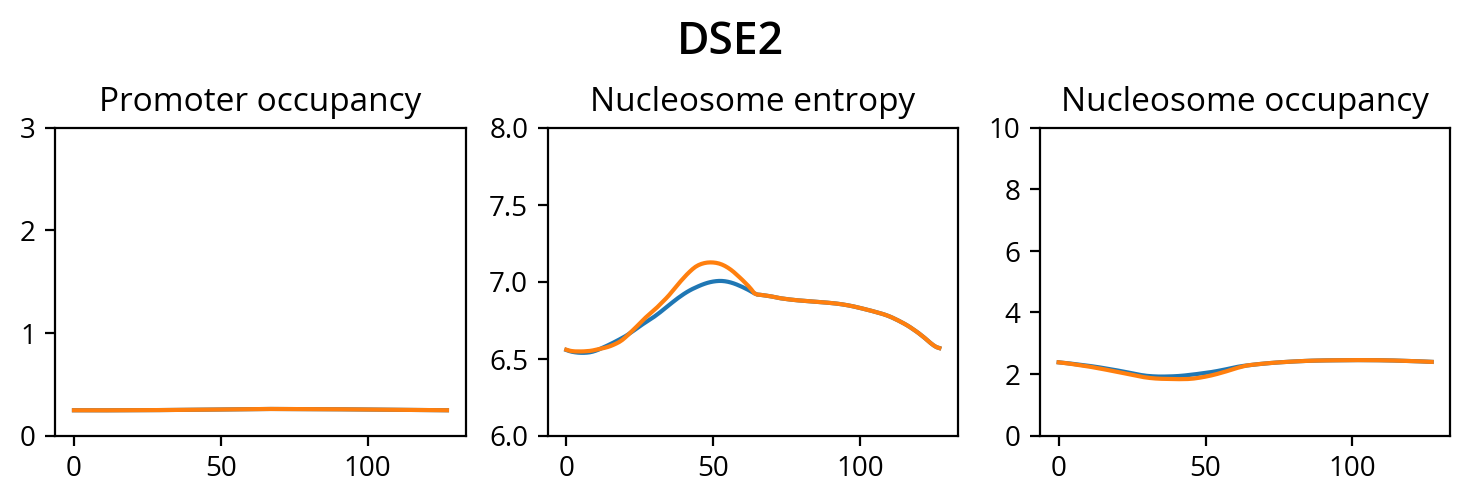

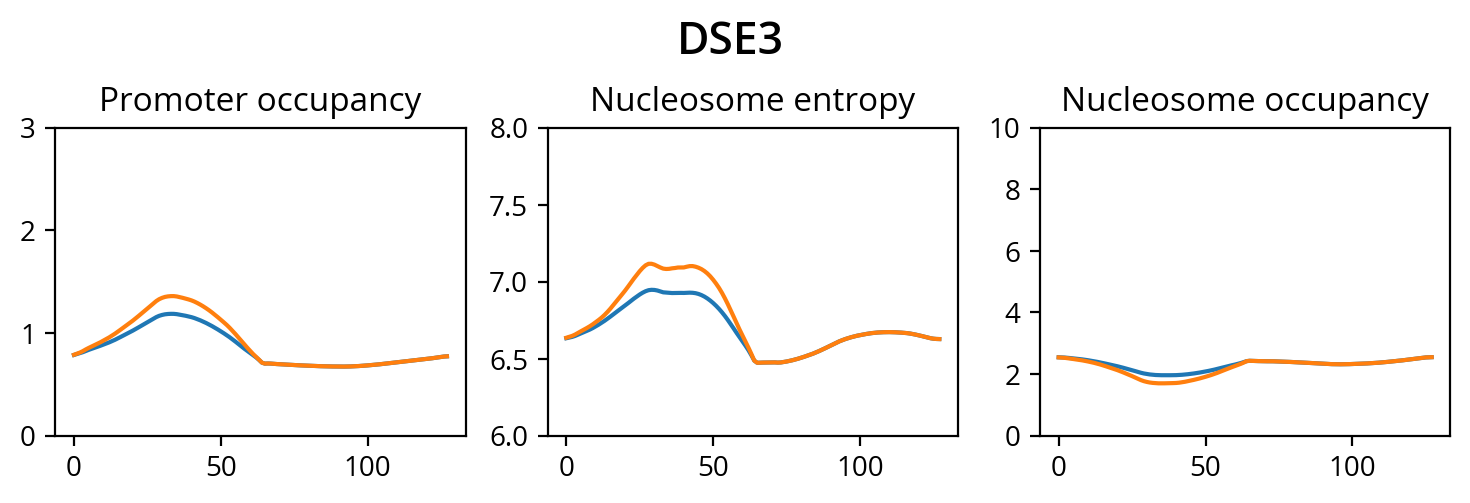

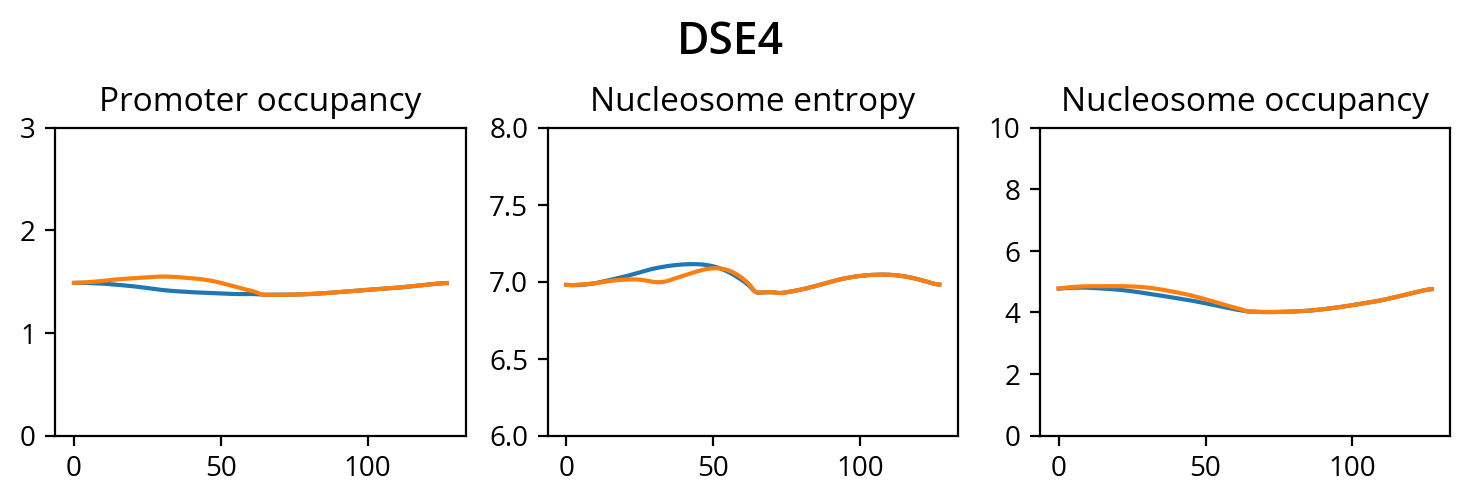

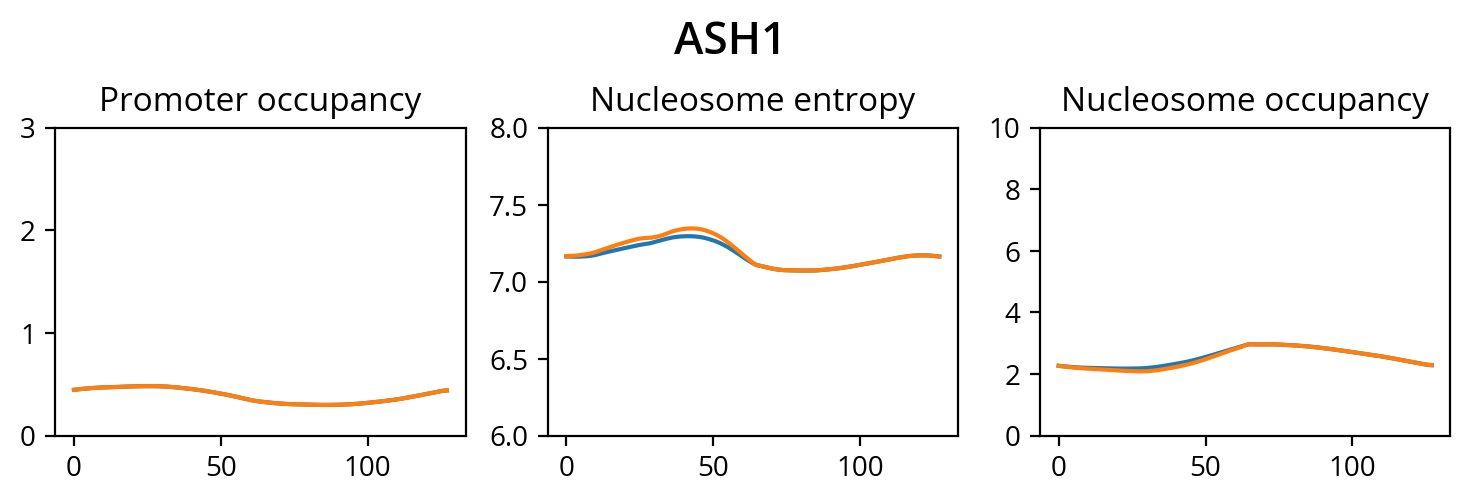

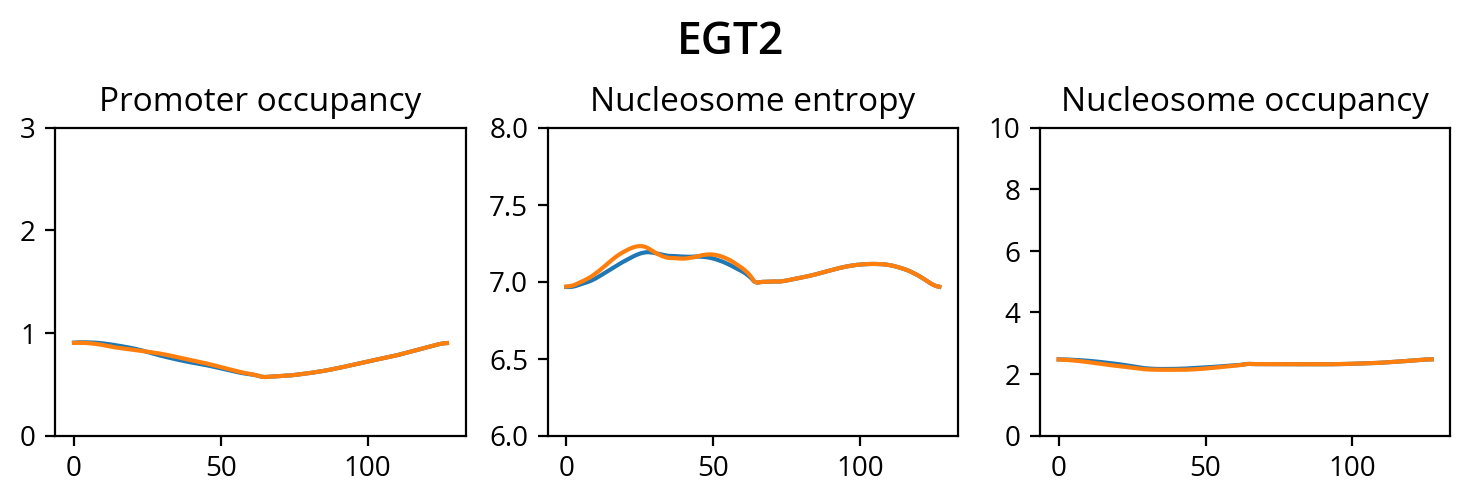

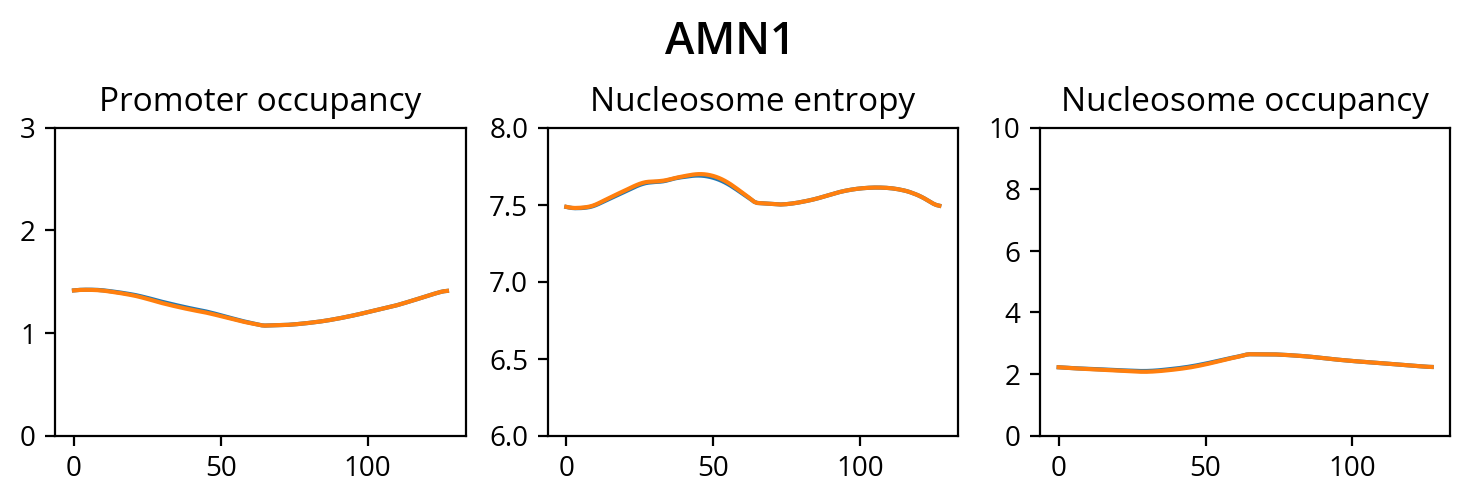

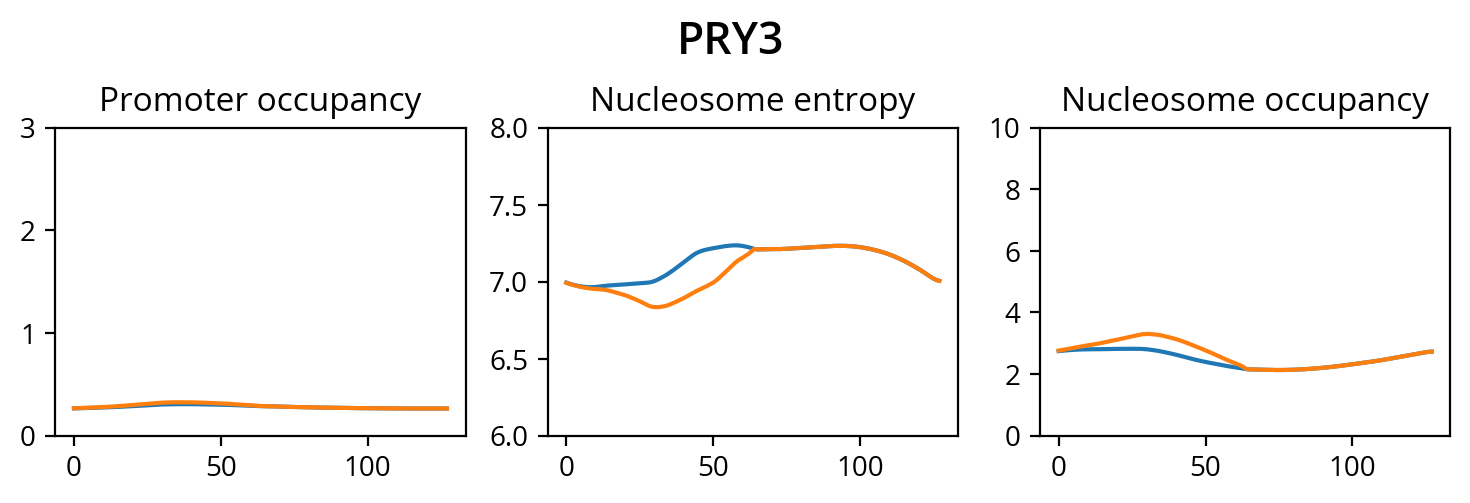

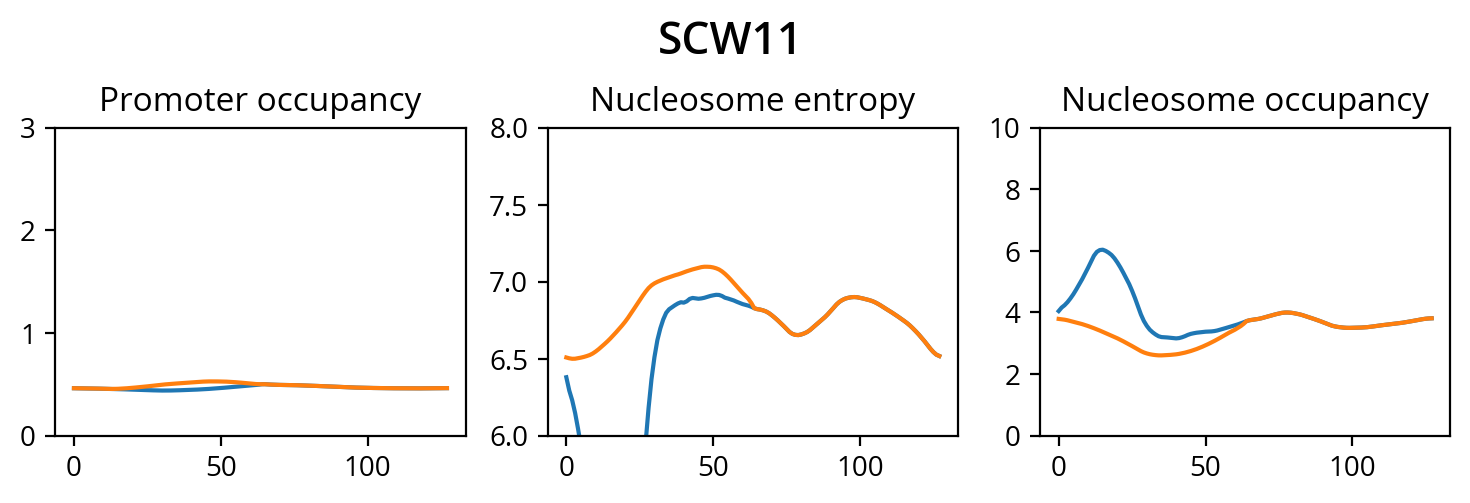

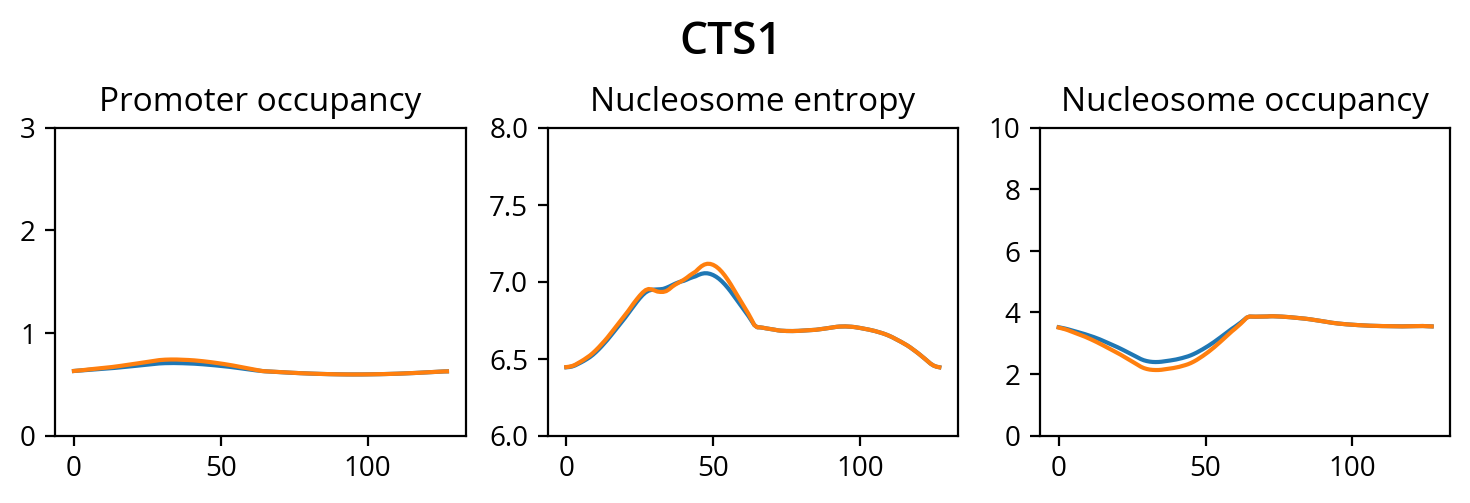

In [304]:
# Quick divegence to examine the daughter-specific chroamtin
from src.sgd import get_orfname

gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4', 'ASH1', 'EGT2', 'AMN1', 
              'PRY3', 'SCW11', 'CTS1']

for gene_name in gene_names:
    orf_name = get_orfname(gene_name)
    b_indices = config1.b_indices()
    t_indices = config1.t_indices()

    plt.figure(figsize=(9, 2))
    
    def plot_chromatin_key(chromatin_key):
        chromatin_values = chromatin_metrics_processor.deconvolved_chromatin_metrics[chromatin_key].loc[orf_name]
        plt.plot(chromatin_values[t_indices].values)
        plt.plot(chromatin_values[b_indices].values)
        
    plt.subplot(1, 3, 1)
    plot_chromatin_key('promoter_occupancy')
    plt.ylim(0, 3)
    plt.title('Promoter occupancy')
    
    plt.subplot(1, 3, 2)
    plot_chromatin_key('nucleosome_entropy')
    plt.ylim(6, 8)
    plt.title('Nucleosome entropy')
    
    plt.subplot(1, 3, 3)
    plot_chromatin_key('nucleosome_occupancy')
    plt.ylim(0, 10)
    plt.title('Nucleosome occupancy')

    plt.suptitle(gene_name, y=1.15, fontweight='demi', fontsize=16)
    

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 14
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr14.h5, crick_rna_seq_pileup_rep1_chr14.h5
Shape: (16, 784333) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr14.h5, crick_rna_seq_pileup_rep2_chr14.h5
Shape: (14, 784333) (timepoints x positions)


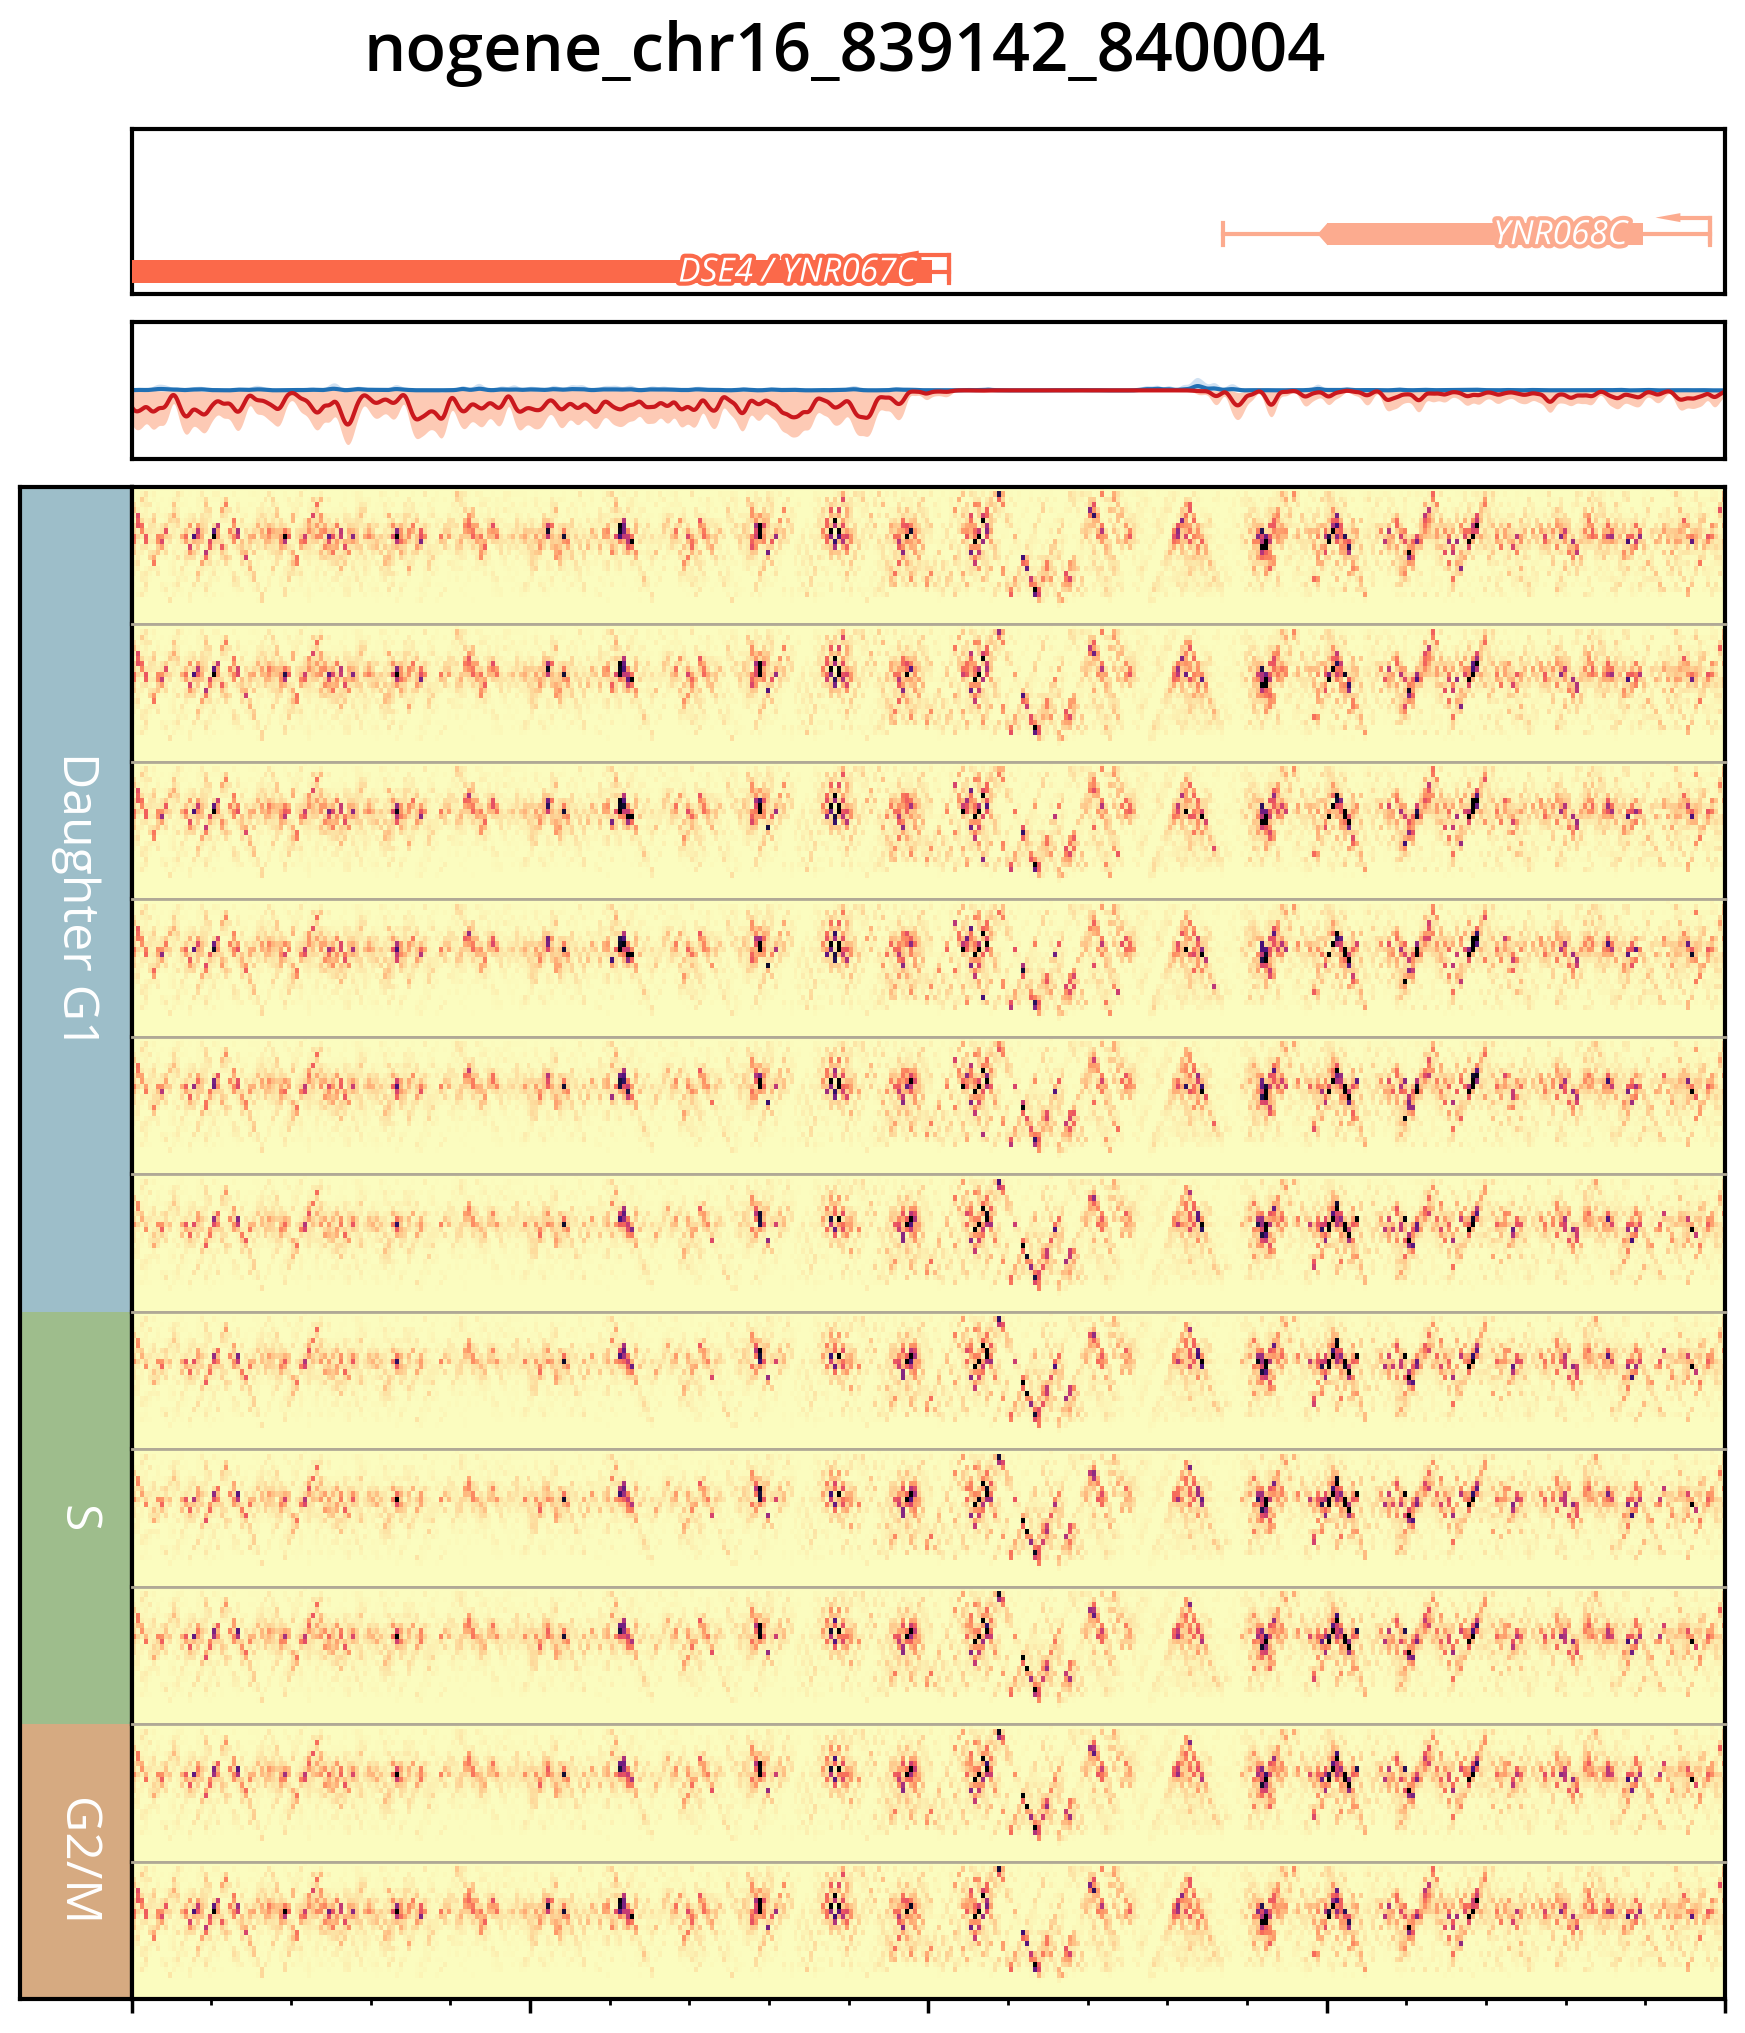

In [325]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

gene = genes[genes['gene'] == 'DSE4'].iloc[0]
chrom = gene.chr
center = gene.stop

span = center-2000, center+2000
loaded_data = genome_deconv_analysis.load_mnase_span(chrom, span)
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=transcript_name,
                                   branch_type='daughter')


Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 14
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr14.h5, crick_rna_seq_pileup_rep1_chr14.h5
Shape: (16, 784333) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr14.h5, crick_rna_seq_pileup_rep2_chr14.h5
Shape: (14, 784333) (timepoints x positions)


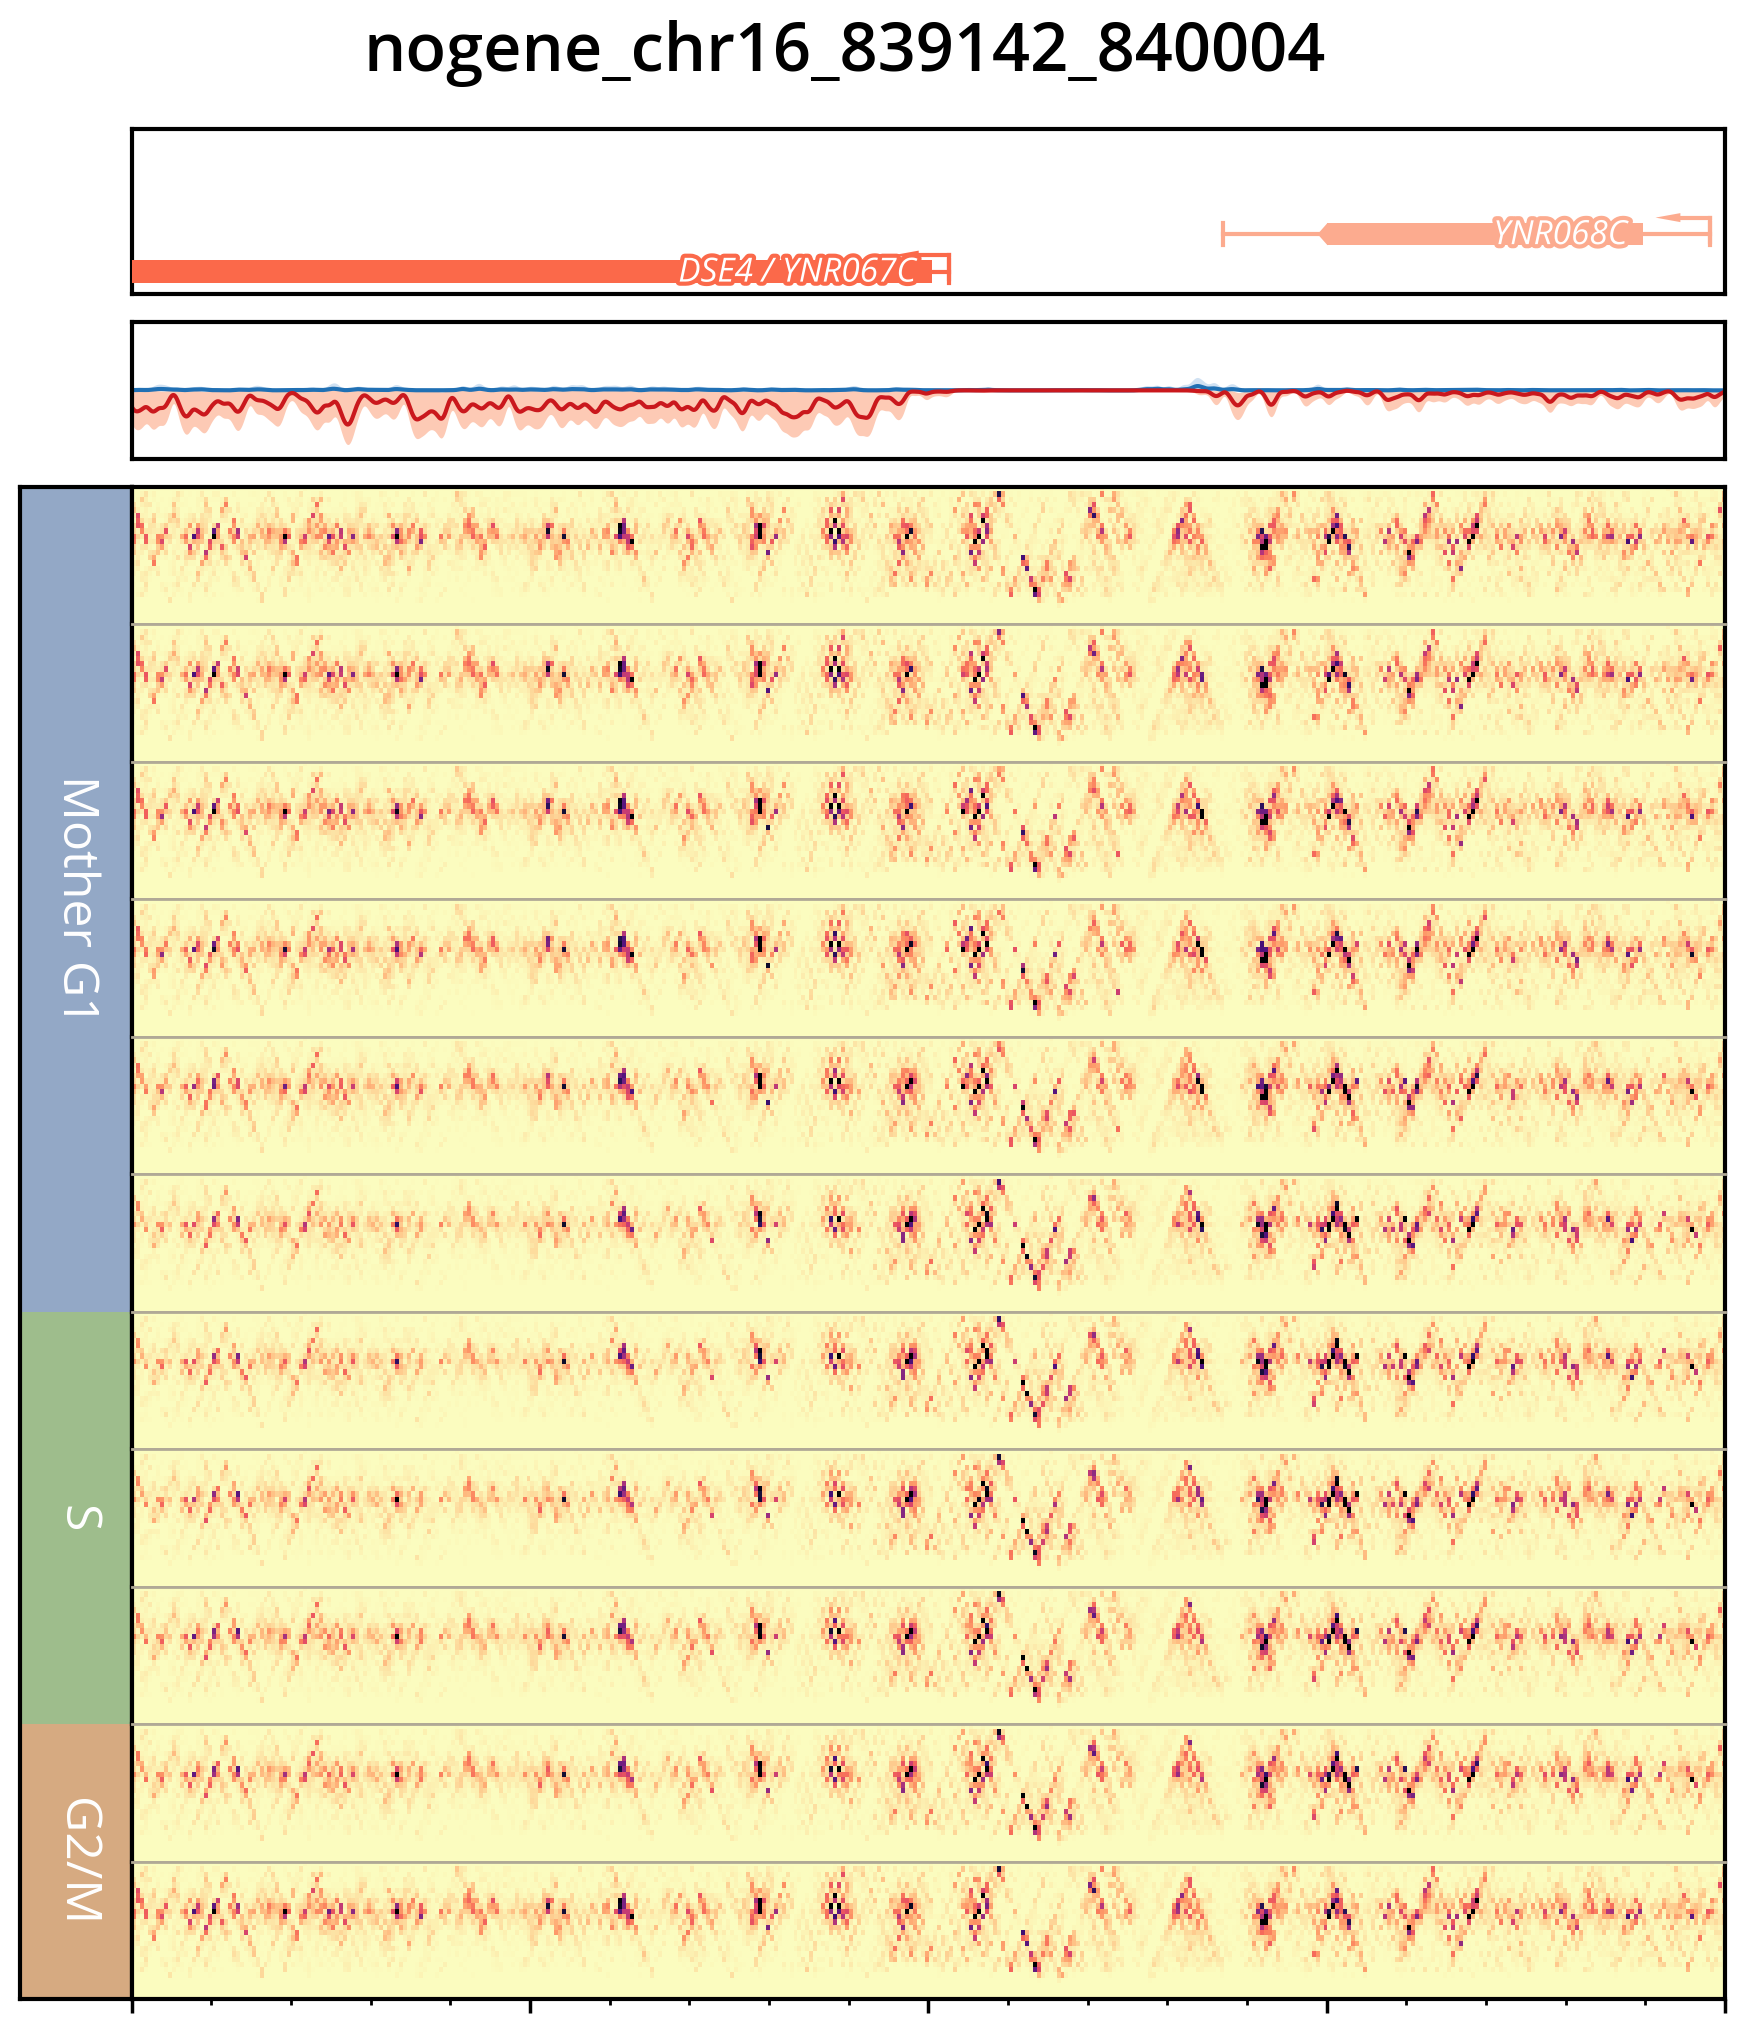

In [326]:
genome_deconv_analysis.plot_loaded_data(figsize=(11, 11), title=transcript_name,
                                   branch_type='mother')

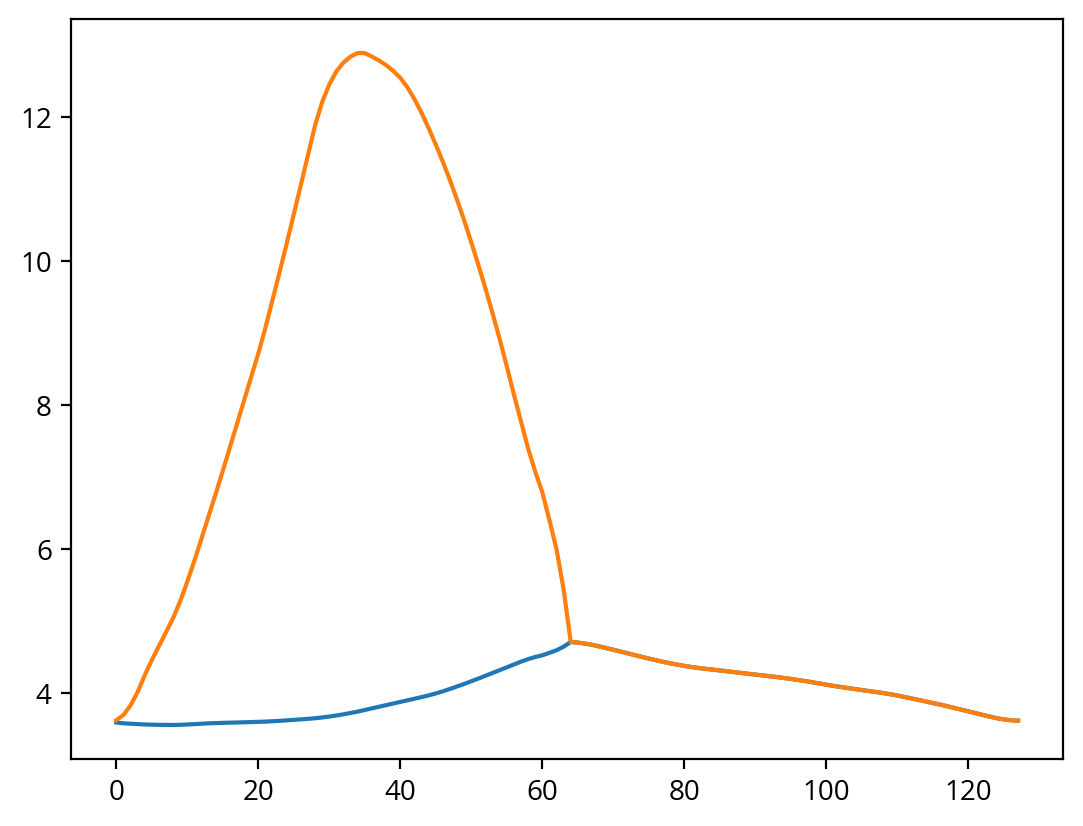

In [324]:
plt.plot(expression_processor.expression_data.loc[gene.name][config1.t_indices()].values)
plt.plot(expression_processor.expression_data.loc[gene.name][config2.b_indices()].values)
